# 하이퍼파라미터 튜닝

기본 8종을 완료한 뒤 선택적으로 수행합니다. 이 노트북은 한 모델·입력 조건만 탐색하며 기본 후보 포함 10후보, seed 42를 사용합니다. 모든 코드가 셀에 포함되어 있습니다.

로컬·Colab 환경과 데이터 설정을 먼저 확인하세요. 이번 캠페인의 동일 기본 실행은 BASELINE_RUN으로 등록할 수 있습니다. 없으면 기본 후보부터 새로 학습합니다. RUN_HPO=True가 기본이므로 탐색 셀 실행 시 학습을 시작합니다. 같은 study를 다시 실행하면 남은 예산만 수행하고 중단된 RUNNING 후보를 복원합니다. 선택한 모델은 재학습 없이 마지막 Test 셀에서 평가할 수 있습니다.

강제 종료 뒤 잠금 파일이 남으면 다른 프로세스가 종료되었는지 확인하세요. 같은 study를 두 환경에서 동시에 실행하지 않습니다.

W&B online 기록은 기본 활성화입니다. 인증은 런타임에서 처리하며 API key를 노트북에 적지 마세요. 연결이 없으면 WANDB_MODE=offline, 비활성화하려면 WANDB_ENABLED=False를 명시합니다. 로컬 결과는 항상 먼저 저장합니다.


## 실행 전 확인: 환경 · 저장 · 결과 화면

이 노트북의 코드는 외부 프로젝트 `.py` 파일 없이 실행합니다. 학습에는 CSV 두 개와 해당 커널의 라이브러리가 필요합니다. 비교·분석 노트북에는 비교할 실험의 저장 결과가 필요합니다.

| 실행 방식 | 첫 환경 셀 설정 | 데이터와 결과 |
|---|---|---|
| 로컬 | `DATA_MODE='folder'` | CSV 폴더 자동 검색 또는 `DATA_ROOT` 지정. 현재 프로젝트 안에서는 `results/`, 프로젝트를 찾지 못하면 현재 작업 폴더의 `results/`에 저장 |
| Colab + Drive | `DATA_MODE='drive'` | Drive 연결 승인. 기본 `MyDrive/KAMP_experiments/dataset`에서 CSV를 읽고 같은 폴더의 `results`에 보관. 학습은 작업 디스크에서 수행 후 epoch마다 백업 |
| Colab + 직접 업로드 | `DATA_MODE='upload'` | 실행 중 CSV 업로드 창 표시. 결과는 런타임 임시 디스크에 있으므로 끝의 ZIP 셀에서 다운로드 |

- 경로 변경은 `DATA_ROOT`, `OUTPUT_ROOT`에 런타임에서 지정합니다. 공유할 노트북에는 개인 절대 경로나 인증 키를 남기지 마세요.
- `RUN_ENV='auto'`는 커널을 기준으로 감지합니다. Colab 화면에서 로컬 런타임에 연결했다면 `folder`를 사용합니다.
- `INSTALL_MISSING=False`는 누락 패키지를 안내하고 중단합니다. 설치를 원하면 `True`로 바꾸고, 설치 후 커널을 다시 시작합니다. 패키지 버전 전체를 자동으로 맞추는 기능은 아닙니다.
- GPU 기종 제한은 없습니다. CPU 학습은 `DEVICE_REQUEST='cpu'` 또는 `ALLOW_CPU_TRAINING=True`로 명시합니다.
- W&B는 기본 online입니다. `.env` 또는 환경 변수로 인증하며, 인터넷 없이 기록하려면 `WANDB_MODE='offline'`을 선택합니다. 로컬 파일 저장과 W&B 업로드는 별개입니다.
- 학습/평가는 기본 실행됩니다. 데이터 준비만 확인하려면 `RUN_TRAINING=False`, `RUN_TEST=False`로 설정하고, HPO 노트북은 탐색 셀의 `RUN_HPO=False`도 설정합니다.
- `FREEZE_SELECTION`은 Valid로 선택한 모델·임계값의 기록이며 모델의 학습 파라미터를 동결하는 옵션이 아닙니다.
- `SHOW_INLINE_RESULTS=True`, `PLOT_EVERY=10`: epoch 표와 주기적 곡선을 표시합니다. 마지막 결과 셀은 저장된 표·그래프를 다시 읽습니다. 실행 후 **노트북을 저장**해야 화면 출력이 ipynb에도 남습니다.
- 완료 결과만 다시 보려면 학습/Test를 끄고 결과 표시 셀의 `RESULT_RUN`을 지정합니다. 비교 분석의 `INCLUDE_TEST`는 별도 옵션입니다.

실제 Colab 런타임·Drive 연결 및 W&B 온라인 업로드는 이 파일의 로컬 검증 범위에 포함되지 않습니다. 지원 코드 구현과 해당 환경의 실측 검증을 구분합니다.


## 실행 환경·데이터 위치·기록 옵션

로컬/Colab 감지, 장치 선택 요청, 데이터와 결과 위치, W&B 및 화면 표시 옵션을 정의합니다. 이 셀 자체는 학습하지 않으며 데이터 업로드·Drive 연결은 바로 다음 시작 셀에서 수행됩니다.

먼저 `DATA_MODE`와 필요 시 `DATA_ROOT`, `OUTPUT_ROOT`를 확인하세요. `folder`는 폴더에서 읽기, `upload`는 Colab 직접 업로드, `drive`는 Drive 연결입니다. 누락 패키지 설치는 `INSTALL_MISSING=True`일 때만 요청되며 설치 후 커널 재시작이 필요합니다.

`RUN_TRAINING`·`RUN_TEST`는 학습 노트북의 실행 스위치입니다. `SHOW_INLINE_RESULTS`·`PLOT_EVERY`는 화면 표시를 조절하며 수치 기록 주기와는 다릅니다. 개인 경로·인증 키는 공유할 소스에 남기지 않습니다.


In [1]:
# 공통 환경/입출력 v1. 실행 시 프로젝트 모듈을 import하지 않습니다.
import os, sys, json, hashlib, platform, random, time, shutil, importlib.util
from pathlib import Path
from datetime import datetime, timezone
from importlib import metadata

# 1) 실행 환경과 입출력 — 먼저 이 부분을 확인하세요.
RUN_ENV = 'auto'         # auto / local / colab. Colab 화면의 로컬 런타임은 local.
DEVICE_REQUEST = 'auto'  # auto / cpu / cuda / cuda:1. GPU 모델명 제한 없음.
DATA_MODE = 'folder'     # folder / upload / drive
DATA_ROOT = None         # 미지정 시 현재 위치와 상위의 dataset만 검색
OUTPUT_ROOT = None       # 로컬 기본: 프로젝트 안의 ipynb_experiments_unified/results
DRIVE_FOLDER = 'KAMP_experiments'
# 2) 실행 허용과 패키지 — 설치 후에는 커널을 다시 시작합니다.
ALLOW_CPU_TRAINING = False  # DEVICE_REQUEST='cpu'이면 명시적 CPU 선택으로 처리
INSTALL_MISSING = False     # 필요한 라이브러리만 현재 커널에 설치. 핵심 패키지 강제 교체 없음.
RUN_SMOKE = True  # 학습 노트북에서만 별도 2 epoch 점검. 재개 시 자동 생략
RUN_TRAINING = True  # 기본: 전체 셀 실행 시 학습 수행
RUN_TEST = True      # 기본: 학습 및 Valid 선택 후 Test 평가
RESUME_RUN = None           # 이번 캠페인의 실행 폴더만 지정. 과거 실험 복원 금지.
SEED = 42
CAMP = 'unified_v1'
# 3) 온라인 기록 — 인증 키를 이 셀에 쓰지 않습니다.
WANDB_ENABLED = True
WANDB_MODE = 'online'
ENV_FILE = ''  # v3와 같은 .env 인증. 비어 있으면 현재 작업 폴더(Colab은 /content도) 검색
WANDB_PROJECT = 'kamp-unified'
WANDB_ENTITY = None  # 기본 계정 사용. 팀 지정은 실행 시에만 입력합니다.
WANDB_UPLOAD_CHECKPOINTS = True
WANDB_TABLE_MAX_ROWS = 5000  # 대시보드 표 표시 한도. 전체 CSV는 artifact에 보관
# 4) 노트북 화면 — 전체 수치는 표시 주기와 관계없이 저장합니다.
SHOW_INLINE_RESULTS = True
PLOT_EVERY = 10  # 곡선 갱신 간격. epoch별 수치는 매번 저장합니다.

def detect_environment(request='auto', env=None):
    if request not in ('auto','local','colab'):
        raise ValueError('RUN_ENV: auto / local / colab 중 선택하세요.')
    env = os.environ if env is None else env
    detected = 'colab' if ('COLAB_RELEASE_TAG' in env or 'COLAB_BACKEND_VERSION' in env) else 'local'
    return detected if request == 'auto' else request

RUN_ENV = detect_environment(RUN_ENV)
def check_packages(framework=None, tuning=False):
    names = {'numpy':'numpy', 'pandas':'pandas', 'sklearn':'scikit-learn',
             'matplotlib':'matplotlib', 'joblib':'joblib'}
    if framework: names[framework] = framework
    if WANDB_ENABLED: names['wandb']='wandb'
    if WANDB_ENABLED and WANDB_MODE=='online': names['dotenv']='python-dotenv'
    if tuning: names['optuna'] = 'optuna'
    missing = [p for m,p in names.items() if importlib.util.find_spec(m) is None]
    if missing and INSTALL_MISSING:
        import subprocess
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', *missing])
        raise RuntimeError('설치를 마쳤습니다. 커널을 재시작하고 처음부터 실행하세요.')
    if missing:
        raise RuntimeError('필요 패키지: '+', '.join(missing)+'. 선택한 커널에 설치하거나 INSTALL_MISSING=True로 설정하세요.')
    return {p:metadata.version(p) for p in names.values()}

def resolve_io(require_data=True):
    global DATA_ROOT, OUTPUT_ROOT
    if DATA_MODE not in ('folder','upload','drive'):
        raise ValueError('DATA_MODE를 folder / upload / drive 중 선택하세요.')
    if DATA_MODE in ('upload','drive') and RUN_ENV != 'colab':
        raise ValueError('로컬 런타임에서는 DATA_MODE=folder와 데이터 경로를 사용하세요.')
    if DATA_MODE == 'drive':
        from google.colab import drive
        drive.mount('/content/drive')
        base = Path('/content/drive/MyDrive') / DRIVE_FOLDER
        DATA_ROOT = DATA_ROOT or Path('/content')
        OUTPUT_ROOT = OUTPUT_ROOT or base/'results'
    elif DATA_MODE == 'upload':
        from google.colab import files
        dest = Path.cwd()/'uploaded_data'
        dest.mkdir(exist_ok=True)
        if require_data and not all((dest/f).is_file() for f in FILES):
            print('CSV 두 개를 선택하세요: '+', '.join(FILES))
            uploaded = files.upload()
            for name,payload in uploaded.items():
                if Path(name).name in FILES:
                    (dest/Path(name).name).write_bytes(payload)
        DATA_ROOT = DATA_ROOT or dest
    if require_data and DATA_ROOT is None:
        candidates = [p/'dataset' for p in [Path.cwd(),*Path.cwd().parents]]
        if RUN_ENV == 'colab': candidates += [Path.cwd(),Path('/content')]
        found = list(dict.fromkeys(p.resolve() for p in candidates if all((p/f).is_file() for f in FILES)))
        if len(found) == 1: DATA_ROOT = found[0]
        else:
            entered = input('CSV 두 개가 있는 폴더를 DATA_ROOT로 입력하세요: ').strip()
            if not entered: raise ValueError('DATA_ROOT가 필요합니다. 파일을 준비한 뒤 다시 실행하세요.')
            DATA_ROOT = Path(entered)
    if DATA_ROOT is not None: DATA_ROOT = Path(DATA_ROOT)
    if require_data and not all((DATA_ROOT/f).is_file() for f in FILES):
        raise FileNotFoundError('지정한 데이터 폴더에 필요한 CSV 두 개가 없습니다.')
    if OUTPUT_ROOT is None:
        # 현재 노트북이 속한 프로젝트를 찾습니다. 폴더 이름이 바뀌어도 동작합니다.
        roots = [p for p in [Path.cwd(), *Path.cwd().parents]
                 if (p/'README.md').is_file()
                 and all((p/'notebooks'/name).is_dir()
                         for name in ('main', 'additional', 'reference', 'tuning'))]
        OUTPUT_ROOT = (roots[0] if roots else Path.cwd())/'results'
    OUTPUT_ROOT = Path(OUTPUT_ROOT)
    OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)
    print('환경:', RUN_ENV, '| 데이터 준비:', bool(DATA_ROOT), '| 결과 저장소:', DATA_MODE)
    if RUN_ENV == 'colab' and DATA_MODE != 'drive':
        print('결과는 런타임 임시 저장소에 있습니다. 종료 전에 결과 다운로드 셀을 실행하세요.')
    return DATA_ROOT, OUTPUT_ROOT

def save_json(path, value):
    def conv(x):
        if hasattr(x,'tolist'): return x.tolist()
        if isinstance(x,Path): raise TypeError('공유 metadata에 절대 경로를 넣지 마세요.')
        raise TypeError(type(x).__name__)
    path=Path(path); path.parent.mkdir(parents=True,exist_ok=True)
    temp=path.with_name(path.name+'.tmp')
    temp.write_text(json.dumps(value,ensure_ascii=False,indent=2,default=conv,allow_nan=False),encoding='utf-8')
    os.replace(temp,path)

def digest(value):
    return hashlib.sha256(json.dumps(value,sort_keys=True,default=str).encode()).hexdigest()

FILES = ['press_data_normal.csv','outlier_data.csv']

EXPECTED_HASHES = {
 'press_data_normal.csv':'f2d61cb3b3108f49a3305d2966b3a31f26942ac8af8ffc9eb531b432b945b0a7',
 'outlier_data.csv':'9fad8c238e63dba3257d8be32a32362548955c772171a95c0d2af61b0435ed2e'}

# 결과 ZIP: 실행 폴더의 파일을 보관합니다. 노트북 화면 출력은 ipynb 자체를 별도로 저장하세요.
def export_result_folders(folders, prefix='experiment_results'):
    import zipfile
    folders=[(name,Path(folder)) for name,folder in folders]
    if not folders or any(not folder.is_dir() for _,folder in folders):
        raise ValueError('먼저 완료 결과 폴더를 지정하세요.')
    archive=Path.cwd()/(prefix+'_'+datetime.now(timezone.utc).strftime('%Y%m%dT%H%M%S%fZ')+'.zip')
    with zipfile.ZipFile(archive,'w',compression=zipfile.ZIP_DEFLATED) as bundle:
        for name,folder in folders:
            for file in sorted(folder.rglob('*')):
                relative=file.relative_to(folder)
                if not file.is_file() or file.name=='.writer.lock' or file.name.endswith('.tmp'):
                    continue
                if any(part in ('.wandb_cache','__pycache__') for part in relative.parts):
                    continue
                bundle.write(file,arcname=(Path(name)/relative).as_posix())
    print('결과 ZIP 저장:',archive.name)
    if RUN_ENV=='colab':
        from google.colab import files
        files.download(str(archive))
    return archive

# 같은 설정으로 뒤의 준비 셀이 호출되면 사용자 입력을 다시 요청하지 않습니다.
_resolve_io_uncached = resolve_io
_IO_READY = None
def resolve_io(require_data=True):
    global _IO_READY
    signature=(RUN_ENV,DATA_MODE,DRIVE_FOLDER,str(DATA_ROOT),str(OUTPUT_ROOT))
    if _IO_READY is not None and _IO_READY['signature']==signature:
        if not require_data or (_IO_READY['require_data'] and all((Path(DATA_ROOT)/f).is_file() for f in FILES)):
            return DATA_ROOT,OUTPUT_ROOT
    result=_resolve_io_uncached(require_data=require_data)
    _IO_READY={'signature':(RUN_ENV,DATA_MODE,DRIVE_FOLDER,str(DATA_ROOT),str(OUTPUT_ROOT)),
               'require_data':require_data}
    return result


## 실험 이름·저장 위치·가중치 epoch 안내

새 실행은 모델·입력 특징·정규화·seed를 포함하는 폴더에 저장합니다. Train, Valid, Test 결과를 분리하고 W&B도 같은 실험 이름을 사용합니다. `selection/checkpoint_summary.csv`에서 저장된 가중치의 epoch와 선택 기준을 확인합니다. 기존 실행은 이동하지 않고 이전 경로를 읽습니다. Smoke test는 저장하거나 업로드하지 않습니다. 아래 함수는 저장과 표시만 담당하며 학습·평가 계산을 바꾸지 않습니다.


In [2]:
STORAGE_COMPATIBLE_CODE_HASHES = ['21a9ec39073687c07f219d4bc2572f5fb718379c0d4c2fa58da22e0156be10ec', 'c4ae1237617bf504881b9ab5575ced5a932c3d381b8b60da04ed79fd2cf07bdc', '2d66681011d1e9d7be31f5e56e801c578ee676a14986a22b9633b8af6a000a2a']
# 공통 저장 규칙 v2: 계산은 유지하고 실행 이름·파일 위치·선택 가중치를 명시합니다.
import re
import uuid
STORAGE_VERSION = 2
MAIN_EXPERIMENTS = {'01','02','04','06','08','18','19'}
ANALYSIS_NAMES = {'00':'data_audit','90':'compare_experiments','91':'audit_10s_labels',
                  '92':'compare_alarm_policies','93':'probability_calibration','94':'compare_ensembles'}

def experiment_description(config):
    spec=config.get('spec',{});ident=str(config['experiment_id']);base_id=ident.removeprefix('H')
    if base_id=='G00':
        return {'slug':'G00_guidebook_lstm_ae','label':'LSTM | Guide Reference | Abs Raw',
                'normalization':'raw-abs-minmax','model':'lstm','structure':'guide_reference','features':'raw'}
    if base_id in ANALYSIS_NAMES:
        return {'slug':base_id+'_'+ANALYSIS_NAMES[base_id],'label':ANALYSIS_NAMES[base_id],
                'normalization':'not_applicable','model':'analysis','structure':'analysis','features':'not_applicable'}
    model={'tcn':'ModernTCN','lstm':'LSTM','mlp':'MLP'}.get(spec.get('backbone'),spec.get('backbone','Unknown'))
    structure='sensor_encoder' if spec.get('family')=='sensor' else 'baseline'
    feature=spec.get('features','none')
    feature_slug={'none':'','all':'fft_p2p_rms','tailored':'tailored_features'}.get(feature,feature)
    inputs=('_'.join(x for x in ('raw' if spec.get('raw') else '',feature_slug) if x)) or 'unspecified'
    norm=('raw-'+('abs-' if spec.get('absolute') else '')+spec.get('raw_scaler','none') if spec.get('raw') else 'raw-none')
    if feature!='none':norm+='_features-'+spec.get('feature_scaler','none')
    if spec.get('fft_log'):norm+='_fft-log'
    channels=spec.get('channels',[0,1,2])
    sensor='_current_only' if channels==[2] else '_vibration_only' if channels==[0,1] else ''
    return {'slug':base_id+'_'+structure+'_'+model.lower()+'_'+inputs+sensor,
            'label':model+' | '+('Sensor Encoder' if structure=='sensor_encoder' else 'Baseline')+' | '+inputs.replace('_','+').upper()+sensor,
            'normalization':norm,'model':model,'structure':structure,'features':inputs}

def storage_info(run):
    p=Path(run)/'run_info.json'
    return json.loads(p.read_text(encoding='utf-8')) if p.is_file() else {}

def new_run_path(base,config,run_kind='fixed',trial=None):
    desc=experiment_description(config);ident=str(config['experiment_id']).removeprefix('H')
    kind=('tuning' if trial is not None or run_kind=='hpo_trials' else 'reference' if ident=='G00'
          else 'analysis' if ident in ANALYSIS_NAMES else 'main' if ident in MAIN_EXPERIMENTS else 'additional')
    stamp=datetime.now(timezone.utc).strftime('%Y%m%dT%H%M%S%fZ')+'_'+uuid.uuid4().hex[:6]
    parent=Path(base)/kind/desc['slug']
    if kind!='analysis':parent=parent/desc['normalization']/('seed_'+str(config['seed']))
    if kind=='tuning':parent=parent/('study_'+str(globals().get('STUDY_NAME','default')))/('trial_'+format(trial.number,'04d') if trial is not None else 'candidate')
    return parent/('run_'+stamp)

def initialize_run(run,config,trial=None):
    run=Path(run);desc=experiment_description(config)
    info={'storage_version':STORAGE_VERSION,'run_id':run.name,'experiment_id':config['experiment_id'],
          'campaign':config['campaign'],'seed':config['seed'],**desc,
          'kind':'hpo_candidate' if trial is not None else 'hpo_summary' if config.get('protocol')=='hpo_summary_v1' else
                 'analysis' if str(config['experiment_id']) in ANALYSIS_NAMES else 'reference' if config['experiment_id']=='G00' else
                 'main' if str(config['experiment_id']).removeprefix('H') in MAIN_EXPERIMENTS else 'additional',
          'trial':trial.number if trial is not None else None,'config_origin':config.get('config_origin','default')}
    prefix=str(config['experiment_id'])
    if trial is not None:prefix='H'+prefix.removeprefix('H')+' Trial '+format(trial.number,'04d')
    if info['kind']=='hpo_summary':prefix+=' Study Summary'
    info['display_name']='['+prefix+'] '+desc['label']+' | '+desc['normalization']+' | s'+str(config['seed'])+' | '+run.name.removeprefix('run_')
    save_json(run/'run_info.json',info)
    # 기본 폴더만 생성합니다. Test 결과 폴더는 실제 평가 시에만 생성합니다.
    for folder in ('config','data_summary','train','valid','checkpoints','selection','execution'):
        (run/folder).mkdir(parents=True,exist_ok=True)
    write_run_readme(run)
    return info

def logical_checkpoint(name):
    return re.sub(r'_epoch_\d+(?=\.pt$|\.weights\.h5$|$)','',str(name))

def checkpoint_index(run):
    p=Path(run)/'selection/checkpoint_index.json'
    return json.loads(p.read_text(encoding='utf-8')) if p.is_file() else {}

def result_path(run,*parts):
    """기존 논리 경로를 받아 새 실행에만 v2 실제 저장 경로를 적용합니다."""
    run=Path(run);rel=Path(*[str(p) for p in parts]);bits=rel.parts
    if not storage_info(run).get('storage_version') or not bits:return run/rel
    first=bits[0];tail=bits[1:]
    if first=='checkpoints' and tail:
        logical=logical_checkpoint(tail[0]);entry=checkpoint_index(run).get(logical)
        if entry and logical==tail[0]:return run/'checkpoints'/entry['filename']/Path(*tail[1:])
        return run/rel
    roots={
        'config.json':'config/experiment.json','preprocessing.json':'config/preprocessing.json',
        'scalers.joblib':'config/scalers.joblib','layout.json':'config/layout.json',
        'manifest.csv':'data_summary/window_manifest.csv','prepared':'data_summary/prepared',
        'selection.json':'selection/primary.json','auxiliary_selection.json':'selection/auxiliary.json',
        'checkpoint_policies.json':'selection/checkpoint_policies.json','test_release.json':'selection/test_release.json',
        'checkpoint_comparison.csv':'selection/checkpoint_comparison.csv',
        'train_scores':'train/epoch_scores','valid_scores':'valid/epoch_scores',
        'train_batches':'train/batch_metrics','epoch_metrics':'execution/epoch_metrics',
        'train':'train/final_evaluation','valid':'valid/final_evaluation','test':'test/primary',
        'valid_best_normal_loss':'valid/checkpoint_comparisons/best_normal_loss',
        'test_best_normal_loss':'test/checkpoint_comparisons/best_normal_loss',
        'curves':'train/figures',
        'model_summary.txt':'config/model_summary.txt','resume_state.json':'execution/resume_state.json','rng.joblib':'execution/rng.joblib'}
    if first=='checkpoint_evaluations' and len(tail)>=2:
        return run/tail[1]/'checkpoint_comparisons'/tail[0]/Path(*tail[2:])
    if first=='valid' and tail and tail[0]=='f1_checkpoint_summary.csv':return run/'selection/f1_checkpoint_summary.csv'
    if first in roots:return run/roots[first]/Path(*tail)
    if first.endswith('_status.json') or first in ('timing.json','inference_timing.json','recording_policy.json','recorded_files.json','evaluation_coverage.csv','wandb_run.json','wandb_error.json','wandb_media_manifest.json'):
        return run/'execution'/rel
    return run/rel

def compatible_resume(prior,current,include_environment=False):
    # 승인된 저장/표시 변경 이전 코드 해시만 허용하며 데이터·모델·설정 검사는 유지합니다.
    candidate=dict(current);candidate.pop('identity',None);candidate.pop('run_id',None)
    if not include_environment:candidate.pop('environment',None)
    known=set(globals().get('STORAGE_COMPATIBLE_CODE_HASHES',[]))|{current.get('code_hash')}
    if prior.get('code_hash') not in known:return False
    candidate['code_hash']=prior.get('code_hash')
    return digest(candidate)==prior.get('identity')

def checkpoint_filename(logical,epoch):
    ext='.weights.h5' if logical.endswith('.weights.h5') else '.pt' if logical.endswith('.pt') else ''
    stem=logical[:-len(ext)] if ext else logical
    return stem+'_epoch_'+format(int(epoch),'04d')+ext

def commit_checkpoint(run,logical,filename,epoch,details=None):
    run=Path(run);index=checkpoint_index(run);old=index.get(logical)
    entry={'filename':filename,'epoch':int(epoch),'logical_name':logical,**(details or {})}
    index[logical]=entry
    save_json(run/'selection/checkpoint_index.json',index)
    # 새 파일과 index가 저장된 뒤, 이 기준에서 교체한 이전 파일만 정리합니다.
    if old and old['filename']!=filename:
        # .pt와 .h5는 단일 파일이며, TensorFlow resume만 여러 파일입니다.
        oldfiles=[run/'checkpoints'/old['filename']]
        if logical=='resume':oldfiles+=list((run/'checkpoints').glob(old['filename']+'.*'))
        for oldfile in oldfiles:
            if oldfile.is_file() and oldfile.parent.resolve()==(run/'checkpoints').resolve():
                try:oldfile.unlink()
                except PermissionError:pass  # 사용 중인 이전 파일은 보존; index가 활성 파일을 결정합니다.
    refresh_checkpoint_summary(run)

def save_versioned_torch(path,value):
    path=Path(path);run=path.parent.parent;logical=logical_checkpoint(path.name)
    if not storage_info(run):return _f1_atomic_base(path,value)
    filename=checkpoint_filename(logical,value['epoch'])
    _f1_atomic_base(run/'checkpoints'/filename,value)
    commit_checkpoint(run,logical,filename,value['epoch'],value.get('f1_selection'))

def save_guide_checkpoint(model,run,logical,epoch):
    run=Path(run)
    if not storage_info(run):model.save_weights(str(run/'checkpoints'/logical));return
    filename=checkpoint_filename(logical,epoch);target=run/'checkpoints'/filename
    temporary=target.with_name(uuid.uuid4().hex+'.weights.h5')
    model.save_weights(str(temporary));replace_file(temporary,target)
    commit_checkpoint(run,logical,filename,epoch)

def save_guide_resume(model,run,epoch):
    run=Path(run);logical='resume';filename=checkpoint_filename(logical,epoch) if storage_info(run) else logical
    tf.train.Checkpoint(model=model,optimizer=model.optimizer).write(str(run/'checkpoints'/filename))
    if storage_info(run):commit_checkpoint(run,logical,filename,epoch)

def replace_file(source,target):
    for attempt in range(8):
        try:os.replace(source,target);return
        except PermissionError:
            if attempt==7:raise
            time.sleep(min(.1*2**attempt,1.))

def refresh_checkpoint_summary(run):
    run=Path(run);index=checkpoint_index(run)
    if not index:return
    history=run/'history.csv';hist=pd.read_csv(history) if history.is_file() else pd.DataFrame()
    rows=[];primary='guide_final.weights.h5' if storage_info(run).get('experiment_id')=='G00' else 'best_normal_loss.pt'
    for logical,entry in index.items():
        row={**entry,'primary':logical==primary};epoch=entry['epoch']
        row['criterion']=('normal_valid_loss_min' if logical.startswith('best_normal_loss') else 'valid_AP_max' if logical.startswith('best_ap') else
                          'valid_F1_max' if logical.startswith('best_f1') else 'guide_ES_restore' if logical.startswith('es_best') else 'guide_final' if logical.startswith('guide_final') else 'resume_latest')
        if len(hist) and epoch in set(hist.epoch):
            h=hist[hist.epoch.eq(epoch)].iloc[-1]
            if logical.startswith('best_normal_loss'):row['metric_value']=h.get('val_normal_loss')
            elif logical.startswith('best_ap'):row['metric_value']=h.get(globals().get('TARGET_COLUMN','label_10s')+'__normal_q99__AP')
        if 'F1' in row:row['metric_value']=row['F1']
        rows.append(row)
    pd.DataFrame(rows).to_csv(run/'selection/checkpoint_summary.csv',index=False)

def epoch_metric_name(key):
    simple={'epoch':'epoch','train_loss':'Train/loss','train_eval_loss':'Train/evaluation_loss',
            'val_normal_loss':'Valid/loss_normal','lr':'Train/learning_rate','next_lr':'Train/next_learning_rate',
            'selected_epoch':'Selection/best_normal_loss/epoch','selected_AP':'Selection/best_normal_loss/AP'}
    if key in simple:return simple[key]
    labels={'label_10s':'Target10s','label_current':'CurrentLabel','label_guide':'GuideRowTarget'}
    parts=key.split('__')
    if parts[0] in labels:return 'Valid/'+labels[parts[0]]+'/'+ '/'.join(parts[1:])
    if len(parts)==2 and parts[1]=='threshold':return 'Valid/Threshold/'+parts[0]
    if 'seconds' in key:return 'Timing/'+key
    return 'Diagnostics/'+key

def finalize_readable_results(run):
    run=Path(run)
    if not storage_info(run):return
    history=run/'history.csv'
    if history.is_file():
        h=pd.read_csv(history)
        for split,prefix in [('train','Train/'),('valid','Valid/')]:
            cols=['epoch']+[c for c in h if c!='epoch' and epoch_metric_name(c).startswith(prefix)]
            h[cols].rename(columns={c:epoch_metric_name(c) for c in cols}).to_csv(run/split/'epoch_metrics.csv',index=False)
    refresh_checkpoint_summary(run)
    for split in ('train','valid','test','valid_best_normal_loss','test_best_normal_loss'):
        folder=result_path(run,split)
        if not (folder/'metrics.json').is_file():continue
        auxiliary=split.endswith('best_normal_loss');selection=result_path(run,'auxiliary_selection.json' if auxiliary else 'selection.json')
        chosen=json.loads(selection.read_text(encoding='utf-8')) if selection.is_file() else {}
        save_json(folder/'evaluation_info.json',{'split':split.split('_')[0],'checkpoint':chosen.get('checkpoint'),
            'epoch':chosen.get('epoch'),'target':globals().get('TARGET_COLUMN'),
            'threshold_source':'Valid','policies':chosen.get('policies',{}),'test_used_for_selection':False})
        scores=folder/'scores.csv'
        if scores.is_file():
            df=pd.read_csv(scores)
            for c in df:
                if c.endswith('_prediction'):
                    cols=[x for x in ('window_id',globals().get('TARGET_COLUMN'), 'label_current','score',c) if x in df]
                    df[cols].to_csv(folder/('predictions_'+c.removesuffix('_prediction')+'.csv'),index=False)
        values=json.loads((folder/'metrics.json').read_text(encoding='utf-8'))
        pd.DataFrame.from_dict(values,orient='index').rename_axis('label_and_policy').to_csv(folder/'metrics_by_policy.csv')
    write_run_readme(run)

def write_run_readme(run):
    run=Path(run);info=storage_info(run)
    if not info:return
    text='# '+info['display_name']+'\n\n'
    text+='저장 형식: v2. UTC 실행 시각과 고유 ID로 실행을 구분합니다.\n\n'
    text+='| 위치 | 내용 |\n|---|---|\n| config/ | 실험·전처리·모델 설정 |\n| data_summary/ | 분할·입력 데이터 요약 |\n| train/ | 학습 지표·점수·그림 |\n| valid/ | epoch별 검증 및 최종 선택 모델 평가 |\n| test/ | 실제 수행한 최종 Test 및 보조 가중치 평가 |\n| checkpoints/ | epoch가 표시된 가중치 |\n| selection/checkpoint_summary.csv | 선택 기준·epoch·값·파일명 |\n| execution/ | 실행·동기화·업로드 상태 |\n| history.csv | 원본 통합 epoch 이력 |\n\n'
    text+='Test 폴더가 없으면 아직 Test 결과가 없습니다. Valid F1은 Test 성능과 구분해서 해석합니다. Smoke 결과는 저장하지 않습니다.\n'
    (run/'README.md').write_text(text,encoding='utf-8')

def show_storage_locations(run):
    run=Path(run);info=storage_info(run)
    destination=drive_destination(run) if DATA_MODE=='drive' else run
    print('실험:',info.get('display_name',run.name))
    print('작업 폴더:',run,'\n최종 저장 폴더:',destination)
    print('W&B:',WANDB_MODE if WANDB_ENABLED else 'disabled','| Drive 백업:',DATA_MODE=='drive')

def drive_destination(run):
    run=Path(run).resolve();work=(Path.cwd()/'experiment_work').resolve();output=Path(OUTPUT_ROOT).resolve()
    try:return output/run.relative_to(work)
    except ValueError:
        try:run.relative_to(output);return run
        except ValueError:raise ValueError('Drive 백업은 작업 폴더 또는 지정된 출력 루트 안의 실행만 지원합니다.')

def sync_run_to_drive(run):
    run=Path(run);finalize_readable_results(run)
    if DATA_MODE!='drive':return
    target=drive_destination(run)
    if target.resolve()==run.resolve():return
    status=result_path(run,'drive_sync_status.json');save_json(status,{'status':'copying','utc':datetime.now(timezone.utc).isoformat()})
    try:
        for p in run.rglob('*'):
            if not p.is_file() or p.name=='.writer.lock' or p.name.endswith('.tmp'):continue
            q=target/p.relative_to(run);q.parent.mkdir(parents=True,exist_ok=True)
            if not q.exists() or q.stat().st_size!=p.stat().st_size or q.stat().st_mtime<p.stat().st_mtime:shutil.copy2(p,q)
        # Drive에서도 활성 가중치만 남깁니다. 해당 실행의 epoch 파일만 대상으로 합니다.
        index=checkpoint_index(run);active={e['filename'] for e in index.values()}
        if index:
            for p in (target/'checkpoints').glob('*_epoch_*'):
                if p.is_file() and p.parent.resolve()==(target/'checkpoints').resolve() and not any(p.name==n or p.name.startswith(n+'.') for n in active):p.unlink()
        save_json(status,{'status':'completed','utc':datetime.now(timezone.utc).isoformat()})
        dest_status=target/status.relative_to(run);dest_status.parent.mkdir(parents=True,exist_ok=True);shutil.copy2(status,dest_status)
    except Exception:
        save_json(status,{'status':'failed','utc':datetime.now(timezone.utc).isoformat()});raise

def discover_completed_runs(root):
    runs=[]
    for p in [*Path(root).rglob('selection.json'),*Path(root).rglob('primary.json')]:
        if not p.is_file():continue
        run=p.parent.parent if p.name=='primary.json' and p.parent.name=='selection' else p.parent
        if 'baseline' in run.parts:continue
        cfgpath=result_path(run,'config.json')
        if not cfgpath.is_file():continue
        cfg=json.loads(cfgpath.read_text(encoding='utf-8'));selected=json.loads(p.read_text(encoding='utf-8'))
        if cfg.get('campaign')==CAMP and selected.get('stop_reason')!='pruned':runs.append((run,cfg,selected))
    return runs

def hpo_study_path(base,spec,study_name):
    old=Path(base)/'hpo'/spec['id']/study_name
    if old.is_dir():return old
    desc=experiment_description({'experiment_id':spec['id'],'spec':spec})
    return Path(base)/'tuning'/desc['slug']/('study_'+study_name)

def hpo_root(work):
    # 새 구조와 기존 구조 모두 study의 3단계 상위가 결과 루트입니다.
    return Path(work).parent.parent.parent

def tracking_metadata(run,config,trial=None):
    info=storage_info(run)
    if info:return info
    desc=experiment_description(config)
    kind='hpo_candidate' if trial is not None else 'hpo_summary' if config.get('protocol')=='hpo_summary_v1' else 'analysis' if str(config['experiment_id']) in ANALYSIS_NAMES else 'experiment'
    return {**desc,'kind':kind,'display_name':'['+str(config['experiment_id'])+(' Trial '+str(trial.number) if trial is not None else '')+'] '+desc['label']+' | '+desc['normalization']+' | s'+str(config['seed'])+' | '+Path(run).name}

def read_status(run,stage):
    path=result_path(run,stage+'_status.json')
    return json.loads(path.read_text(encoding='utf-8')).get('status','unknown') if path.is_file() else 'not_run'

def media_key(relative,suffix):
    parts=list(relative.with_suffix('').parts)
    if parts[0] in ('train','valid','test'):
        parts[0]={'train':'Train','valid':'Valid','test':'Test'}[parts[0]]
    elif parts[0]=='checkpoint_evaluations' and len(parts)>2:
        parts=[parts[2].title(),'checkpoint_comparisons',parts[1]]+parts[3:]
    elif parts[0]=='valid_best_normal_loss':parts=['Valid','checkpoint_comparisons','best_normal_loss']+parts[1:]
    elif parts[0]=='test_best_normal_loss':parts=['Test','checkpoint_comparisons','best_normal_loss']+parts[1:]
    elif parts[0]=='curves':parts=['Train','figures']+parts[1:]
    elif parts[0]=='selection':parts[0]='Selection'
    elif parts[0]=='data_summary':parts[0]='Data'
    elif parts[0]=='execution':parts[0]='Execution'
    elif parts[0] in ('trials','hpo_curves','hpo_curve_coverage'):parts=['HPO']+parts
    else:parts=['Overview']+parts
    return ('Tables/' if suffix=='.csv' else 'Figures/')+'/'.join(parts)

def export_run_label(run):
    info=storage_info(run)
    return info.get('slug','experiment')+'/'+Path(run).name

def hpo_export_folders(study_dir):
    study_dir=Path(study_dir);base=hpo_root(study_dir)
    folders=[(study_dir.relative_to(base).as_posix(),study_dir)]
    # 완료·가지치기·중단 후보를 study에 기록된 상대 경로에서 모두 수집합니다.
    relatives=set()
    trials=study_dir/'trials.csv'
    if trials.is_file():
        table=pd.read_csv(trials)
        if 'user_attrs_run_relative' in table:relatives.update(table.user_attrs_run_relative.dropna().astype(str))
    active=study_dir/'active.json'
    if active.is_file():
        relative=json.loads(active.read_text(encoding='utf-8')).get('run_relative')
        if relative:relatives.add(relative)
    for relative in sorted(relatives):
        candidate=base/relative
        candidate.resolve().relative_to(base.resolve())
        if candidate.is_dir():folders.append((candidate.relative_to(base).as_posix(),candidate))
    return folders


## 시작 — 사용자 입력·Drive 연결·파일 업로드·W&B 인증

환경 설정 바로 다음에 실행합니다. 먼저 패키지를 확인하고, 아래 입력/승인을 완료한 뒤 모델 정의와 데이터 전처리로 넘어갑니다.

1. **로컬:** CSV 폴더를 자동 검색하거나 경로 입력을 요청합니다. 분석 전용 노트북은 CSV 없이 저장 결과 위치를 준비합니다.
2. **Colab Drive:** `DATA_MODE='drive'`이면 여기서 Drive 연결 승인을 요청합니다. Drive의 `.env` 경로도 연결 후 읽을 수 있습니다.
3. **Colab 업로드:** `DATA_MODE='upload'`이면 CSV 두 개를 요청합니다. online 인증에 필요한 키가 없고 `ENV_FILE`도 미지정이면 별도로 `.env` 업로드를 요청합니다.
4. **W&B online:** `.env`/환경 변수의 키로 로그인하고 서버의 계정 조회까지 확인합니다. 키나 계정 정보는 출력하지 않습니다. 프로젝트 쓰기 권한은 실제 run 생성 시 추가 확인됩니다.

`.env`는 `WANDB_API_KEY=발급받은키` 형식입니다. 로컬은 현재 작업 폴더 또는 `ENV_FILE`, Colab은 현재 폴더·`/content/.env` 또는 연결된 Drive의 `ENV_FILE`을 사용합니다. 실제 키를 코드/Markdown에 쓰지 마세요. offline 또는 W&B 비활성화에서는 서버 인증을 생략합니다.

뒤의 데이터 준비 셀은 같은 경로 설정의 연결 결과를 재사용하므로 다시 업로드·Drive 승인을 요청하지 않습니다. 환경 설정 셀을 다시 실행하거나 경로/모드를 바꾸면 이 시작 셀도 다시 실행하세요. 결과 ZIP 다운로드는 결과 생성 후의 마지막 셀에 유지합니다.


In [3]:
def prepare_wandb_auth():
    # v3와 같은 파일 우선 방식. 경로·키 값·파일 내용은 출력하거나 결과에 저장하지 않습니다.
    if not WANDB_ENABLED or WANDB_MODE!='online':
        return 'not_required'
    candidates=([Path(ENV_FILE).expanduser()] if ENV_FILE else
                [Path.cwd()/'.env']+([Path('/content/.env')] if RUN_ENV=='colab' else []))
    env_path=next((p for p in candidates if p.is_file()),None)
    if ENV_FILE and env_path is None:
        raise FileNotFoundError('ENV_FILE을 찾을 수 없습니다. 실행 중인 커널의 파일 위치를 확인하세요.')
    if env_path is not None:
        try:
            from dotenv import dotenv_values
        except ImportError:
            raise RuntimeError('python-dotenv가 필요합니다. 패키지 준비 셀에서 설치 후 커널을 다시 시작하세요.') from None
        try:
            key=dotenv_values(env_path,encoding='utf-8-sig',interpolate=False).get('WANDB_API_KEY')
        except Exception:
            raise RuntimeError('.env 읽기에 실패했습니다. 파일 권한과 UTF-8 형식을 확인하세요.') from None
        if not isinstance(key,str) or not key.strip():
            raise ValueError('.env에 비어 있지 않은 WANDB_API_KEY가 필요합니다.')
        os.environ['WANDB_API_KEY']=key.strip()
        return 'env_file'
    if os.environ.get('WANDB_API_KEY','').strip():
        return 'environment_variable'
    raise RuntimeError('W&B 인증 키가 없습니다. 로컬은 현재 작업 폴더의 .env 또는 ENV_FILE을 지정하세요. '
                       'Colab은 런타임 파일 영역에 .env를 올리고 ENV_FILE을 지정하세요. '
                       '파일에는 WANDB_API_KEY 항목이 필요합니다. 수동 키 입력 창은 사용하지 않습니다.')

# 사용자 입력과 인증은 모델/데이터 함수 정의보다 먼저 완료합니다.
check_packages(framework='torch',tuning=True)
resolve_io(require_data=True)

def authenticate_wandb_startup():
    if not WANDB_ENABLED or WANDB_MODE!='online':
        print('W&B 서버 인증 생략:', 'disabled' if not WANDB_ENABLED else WANDB_MODE)
        return 'not_required'
    if RUN_ENV=='colab' and not ENV_FILE and not os.environ.get('WANDB_API_KEY','').strip():
        if not any(p.is_file() for p in (Path.cwd()/'.env',Path('/content/.env'))):
            from google.colab import files
            print('W&B 인증용 .env 파일을 업로드하세요. 키를 코드에 입력하지 마세요.')
            uploaded=files.upload()
            for name,payload in uploaded.items():
                if Path(name).name=='.env':(Path.cwd()/'.env').write_bytes(payload)
    source=prepare_wandb_auth()
    import wandb
    try:
        if wandb.login(key=os.environ['WANDB_API_KEY'].strip(),relogin=True) is False:
            raise RuntimeError('login rejected')
        # login이 로컬 인증정보만 저장하는 구버전에서도 서버 확인을 앞에서 수행합니다.
        if not wandb.Api().viewer:raise RuntimeError('viewer unavailable')
    except Exception as exc:
        raise RuntimeError('시작 단계 W&B 서버 인증 실패 ['+type(exc).__name__+']. '
                           '.env의 키, 네트워크 및 W&B 서버 설정을 확인하세요. 원본 오류/키는 출력하지 않습니다.') from None
    print('W&B 서버 인증 완료 | 키 출처:',source,'| SDK:',wandb.__version__)
    print('프로젝트 쓰기 권한은 이후 해당 run을 생성할 때 추가 확인됩니다.')
    return source

AUTH_SOURCE=authenticate_wandb_startup()


환경: local | 데이터 준비: True | 결과 저장소: folder


wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: Appending key for api.wandb.ai to your netrc file: [LOCAL_PATH_REDACTED]
wandb: Currently logged in as: [ACCOUNT_REDACTED]


W&B 서버 인증 완료 | 키 출처: env_file | SDK: 0.30.0
프로젝트 쓰기 권한은 이후 해당 run을 생성할 때 추가 확인됩니다.


## 이 노트북의 실험 조건

이 파일의 실험은 **H08 / sensor_mlp_all_features**입니다. `SPEC`은 입력·구조·전처리 조건, `TRAIN_CONFIG`는 학습 설정입니다. 공통 함수에 다른 모델 코드가 있어도 아래 설정에 해당하는 모델만 사용합니다.

| 항목 | 현재 설정 |
|---|---|
| 센서 채널 | 진동 AI0, 진동 AI1, 전류 AI2 |
| Raw 입력 | 미사용 |
| 파생 특징 입력 | FFT·P2P·RMS |
| Raw scaler / 특징 scaler | `standard` / `standard` |
| Raw 절댓값 / FFT log1p | `False` / `False` |
| 학습률 / dropout / batch | 0.001 / 0.0 / 128 |
| 최대 epoch / 최소 epoch / patience | 800 / 200 / 150 |

미사용 입력의 scaler 설정은 실제 모델 입력을 추가한다는 뜻이 아닙니다. `CONFIG_ORIGIN`·`ANCHOR`는 설정 출처를 기록하며 이전 모델 가중치를 이어받는 옵션이 아닙니다. `CODE_HASH`는 구현 일치 확인용이므로 임의로 바꾸지 않습니다.


In [4]:
# 조건 하나당 노트북 하나. 아래 설정은 새 학습에만 적용됩니다.
SPEC = json.loads(r'''{"id":"08","name":"sensor_mlp_all_features","family":"sensor","backbone":"mlp","channels":[0,1,2],"raw":false,"features":"all","raw_scaler":"standard","feature_scaler":"standard","absolute":false,"fft_log":false,"matched_loss":false}''')
IS_HPO = True
CONFIG_ORIGIN = 'default'
ANCHOR = {'experiment_id':'08','study_id':None,'trial_id':None,'run_id':None}
# HPO 설정을 이어받으면 이 표에 선택값을 적고 config_origin과 anchor 출처를 기록하세요.
TRAIN_CONFIG = {'lr':0.001,'dropout':0.0,'batch':128,'epochs':800,'min_epochs':200,'patience':150}
CODE_HASH = 'd68a108c43e40c4f23335424a4ebee31518b4e73e3200a504a8f3ad6364205ce'


## 라이브러리와 실행 장치 확인

현재 커널에서 필요한 패키지를 확인하고 라이브러리를 불러옵니다. 학습 노트북에서는 사용 장치와 환경 버전을 기록합니다. 데이터 감사용 셀은 기본 분석 라이브러리만 준비합니다.

이 단계에서 오류가 나면 뒤의 학습 셀을 실행하기 전에 커널과 패키지를 확인하세요. GPU 기종 제한은 없지만 프레임워크에서 GPU를 사용할 수 있어야 합니다. CPU 학습은 앞 설정에서 명시적으로 선택합니다.


In [5]:
VERSIONS=check_packages('torch', tuning=IS_HPO)
VERSIONS.pop('python-dotenv',None)  # 인증용 의존성은 모델 학습 환경 비교에서 제외
VERSIONS.pop('wandb',None)  # SDK version lives in wandb_run.json; logging must not change training identity.
import torch
from torch import nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from types import SimpleNamespace
import joblib
import matplotlib
if 'ipykernel' not in sys.modules: matplotlib.use('Agg')
import matplotlib.pyplot as plt

def select_device(request):
    if request=='auto': request='cuda' if torch.cuda.is_available() else 'cpu'
    dev=torch.device(request)
    if dev.type not in ('cpu','cuda'): raise ValueError('지원 장치: CPU/CUDA')
    if dev.type=='cuda':
        if not torch.cuda.is_available(): raise RuntimeError('CUDA를 사용할 수 없습니다. 드라이버/커널을 점검하거나 cpu를 선택하세요.')
        if dev.index is not None and dev.index>=torch.cuda.device_count(): raise ValueError('해당 CUDA 장치 번호가 없습니다.')
    return dev
DEVICE=select_device(DEVICE_REQUEST)
print('실행 환경:',RUN_ENV,'| 장치:',DEVICE.type,
      '| GPU:',torch.cuda.get_device_name(DEVICE) if DEVICE.type=='cuda' else '사용하지 않음')
if DEVICE.type=='cpu' and DEVICE_REQUEST!='cpu' and not ALLOW_CPU_TRAINING:
    print('CPU 준비·분석은 가능합니다. CPU 학습은 DEVICE_REQUEST=cpu 또는 ALLOW_CPU_TRAINING=True로 명시하세요.')
ENVIRONMENT={'python':platform.python_version(),'packages':VERSIONS,'device':DEVICE.type,
             'gpu':torch.cuda.get_device_name(DEVICE) if DEVICE.type=='cuda' else None,
             'cuda':torch.version.cuda,'run_env':RUN_ENV}
def seed_all(seed):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    if torch.cuda.is_available(): torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.benchmark=False
    torch.backends.cudnn.deterministic=True


실행 환경: local | 장치: cuda | GPU: NVIDIA GeForce RTX 3080


## W&B 기록·업로드 함수

epoch 지표, 저장된 평가 자료와 체크포인트를 W&B에 기록하는 함수를 정의합니다. `.env` 또는 환경 변수의 키로 실제 로그인과 run 생성을 학습 또는 분석 기록 시작 시 수행합니다. 수동 키 입력 창은 사용하지 않습니다.

`WANDB_ENABLED=True`, `WANDB_MODE='online'`이 기본입니다. 연결 없이 기록하려면 `offline`, 사용하지 않으려면 `WANDB_ENABLED=False`를 선택합니다. offline은 서버 업로드 완료를 뜻하지 않습니다.

로컬 결과와 W&B 사본을 구분합니다. 자동 코드·콘솔·시스템 정보 수집을 제한하고 지정한 결과 파일을 artifact로 올립니다. 이 셀을 정의하는 것만으로 기존 실험을 학습하거나 업로드하지 않습니다.

초기화 실패 시 `wandb_error.json`에 실패 단계·오류 종류·SDK 버전만 기록합니다. 인증 키·원본 예외 내용은 저장하지 않습니다. 로그인/프로젝트 권한/연결/SDK 설정을 구분해 안내하며 online에서 offline으로 자동 전환하지 않습니다.

**저장 v2 안내:** 아래 코드의 논리 경로는 `result_path()`가 새 실행의 실제 폴더로 연결합니다. `run_info.json`과 실행 폴더 `README.md`에서 실험 이름·Train/Valid/Test 위치를 확인하세요. W&B 실행 이름은 Test 업로드 시에도 유지합니다.


In [6]:
def prepare_wandb_auth():
    # v3와 같은 파일 우선 방식. 경로·키 값·파일 내용은 출력하거나 결과에 저장하지 않습니다.
    if not WANDB_ENABLED or WANDB_MODE!='online':
        return 'not_required'
    candidates=([Path(ENV_FILE).expanduser()] if ENV_FILE else
                [Path.cwd()/'.env']+([Path('/content/.env')] if RUN_ENV=='colab' else []))
    env_path=next((p for p in candidates if p.is_file()),None)
    if ENV_FILE and env_path is None:
        raise FileNotFoundError('ENV_FILE을 찾을 수 없습니다. 실행 중인 커널의 파일 위치를 확인하세요.')
    if env_path is not None:
        try:
            from dotenv import dotenv_values
        except ImportError:
            raise RuntimeError('python-dotenv가 필요합니다. 패키지 준비 셀에서 설치 후 커널을 다시 시작하세요.') from None
        try:
            key=dotenv_values(env_path,encoding='utf-8-sig',interpolate=False).get('WANDB_API_KEY')
        except Exception:
            raise RuntimeError('.env 읽기에 실패했습니다. 파일 권한과 UTF-8 형식을 확인하세요.') from None
        if not isinstance(key,str) or not key.strip():
            raise ValueError('.env에 비어 있지 않은 WANDB_API_KEY가 필요합니다.')
        os.environ['WANDB_API_KEY']=key.strip()
        return 'env_file'
    if os.environ.get('WANDB_API_KEY','').strip():
        return 'environment_variable'
    raise RuntimeError('W&B 인증 키가 없습니다. 로컬은 현재 작업 폴더의 .env 또는 ENV_FILE을 지정하세요. '
                       'Colab은 런타임 파일 영역에 .env를 올리고 ENV_FILE을 지정하세요. '
                       '파일에는 WANDB_API_KEY 항목이 필요합니다. 수동 키 입력 창은 사용하지 않습니다.')

# W&B 기록 v1. 각 노트북에 포함되며 외부 프로젝트 모듈을 사용하지 않습니다.
# 자동 코드/콘솔/호스트 정보 수집을 제한하고 지정한 결과 파일만 artifact로 올립니다.
def wandb_settings(wb):
    probe=wb.Settings()
    options=dict(console='off',disable_code=True,disable_git=True,save_code=False,
                 host='experiment-runtime',program='experiment.ipynb',notebook_name='experiment.ipynb',
                 ignore_globs=('*.log','**/*.log','wandb-metadata.json','requirements.txt','code/**'))
    for current,legacy,value in [('x_disable_meta','_disable_meta',True),
                                  ('x_disable_stats','_disable_stats',True),
                                  ('x_save_requirements','_save_requirements',False)]:
        key=current if hasattr(probe,current) else legacy
        if not hasattr(probe,key):
            raise RuntimeError('이 W&B 버전의 metadata 설정을 확인할 수 없습니다. 지원 버전을 사용하세요.')
        options[key]=value
    for key in ('disable_job_creation','x_disable_machine_info'):
        if hasattr(probe,key): options[key]=True
    return wb.Settings(**options)

# 원본 SDK 예외에는 개인 경로나 인증정보가 포함될 수 있어 분류된 진단만 공유합니다.
def wandb_initialization_failure(stage, exc, wb, run_dir):
    message=str(exc).lower()
    if any(word in message for word in ('401','unauthorized','invalid api key','api_key not configured','not logged in','login returned false')):
        category='authentication'
        hint=".env의 WANDB_API_KEY와 ENV_FILE을 확인하세요. 키는 파일에서 읽으며 코드나 출력에 적지 않습니다."
    elif any(word in message for word in ('403','forbidden','permission','not found','404')):
        category='project_access'
        hint='WANDB_PROJECT와 WANDB_ENTITY의 존재 및 쓰기 권한을 확인하세요. 다른 계정이면 .env의 키를 해당 계정의 키로 바꾸고 인증 확인 셀부터 다시 실행하세요.'
    elif any(word in message for word in ('timeout','timed out','connection','network','proxy','ssl','certificate','10054','10060','name resolution')):
        category='connection'
        hint="현재 커널의 인터넷·프록시·방화벽 연결을 확인하세요. 연결 없이 진행하려면 WANDB_MODE='offline'을 명시적으로 선택할 수 있습니다."
    elif stage=='settings' or isinstance(exc,(TypeError,AttributeError)):
        category='sdk_configuration'
        hint='현재 커널의 W&B SDK 버전과 설정 호환성을 확인하세요. 다른 커널에 설치한 버전과 혼동하지 마세요.'
    else:
        category='unclassified'
        hint='아래 오류 단계·종류와 SDK의 직전 안내를 확인하세요. API 키나 계정 정보를 공유하지 마세요.'
    diagnostic={'stage':stage,'category':category,'error_type':type(exc).__name__,
                'sdk_version':getattr(wb,'__version__','unknown'),'mode':WANDB_MODE}
    try: save_json(Path(run_dir)/'wandb_error.json',diagnostic)
    except Exception: pass  # 진단 저장 실패로 원래 오류 분류를 덮어쓰지 않습니다.
    return RuntimeError('W&B 초기화 실패 | 단계='+stage+' | 종류='+diagnostic['error_type']+
        ' | 분류='+category+' | SDK='+diagnostic['sdk_version']+'\n'+hint+
        '\n저장된 로컬 파일은 유지됩니다. 이 초기화가 실패한 실행에서는 학습을 시작하지 않았습니다.')

class ExperimentTracking:
    def __init__(self,run_dir,config,stage='train',trial=None):
        self.path=Path(run_dir);self.handle=None;self.closed=False;self.stage=stage;self.config=config
        self.enabled=bool(WANDB_ENABLED);self.last_epoch=0
        if not self.enabled: return
        if WANDB_MODE not in ('online','offline'):
            raise ValueError('WANDB_MODE는 online/offline입니다. 끄려면 WANDB_ENABLED=False를 사용하세요.')
        try:
            import wandb
        except ImportError:
            raise RuntimeError('wandb를 현재 커널에 설치한 뒤 다시 실행하세요.') from None
        self.wb=wandb
        record=result_path(self.path,'wandb_run.json')
        previous=json.loads(record.read_text(encoding='utf-8')) if record.exists() else {}
        self.id=previous.get('id') or digest({'campaign':config['campaign'],'protocol':config['protocol'],
                      'experiment':config['experiment_id'],'run':self.path.name})[:24]
        if previous and previous.get('project')!=WANDB_PROJECT:
            raise ValueError('같은 실행의 W&B 프로젝트를 바꾸지 마세요.')
        self.last_epoch=int(previous.get('last_epoch',0)) if WANDB_MODE=='online' else 0
        cache=Path.cwd()/'.wandb_cache'
        cache.mkdir(parents=True,exist_ok=True)
        self.record=record
        # 계정은 런타임/환경에서만 선택. API key, entity, URL을 공유 설정에 저장하지 않습니다.
        initialization_stage='settings'
        try:
            settings=wandb_settings(wandb)
            if WANDB_MODE=='online':
                initialization_stage='auth_file'
                prepare_wandb_auth()
                initialization_stage='login'
                if wandb.login(key=os.environ['WANDB_API_KEY'].strip(),relogin=True) is False:
                    raise RuntimeError('login returned false')
            initialization_stage='init'
            self.handle=wandb.init(project=WANDB_PROJECT,entity=WANDB_ENTITY,
                id=self.id,resume='allow' if WANDB_MODE=='online' else None,
                name=tracking_metadata(self.path,config,trial)['display_name'],
                group=config['campaign']+'/'+str(config['experiment_id']),job_type=tracking_metadata(self.path,config,trial)['kind'],
                tags=[tracking_metadata(self.path,config,trial)[k] for k in ('model','structure','features')],
                config=json.loads((result_path(self.path,'config.json')).read_text(encoding='utf-8')),
                dir=str(cache),mode=WANDB_MODE,save_code=False,settings=settings,reinit=True)
            if self.handle is None:
                raise RuntimeError('W&B init returned no run')
            initialization_stage='metric_setup'
            if trial is not None: self.handle.summary['hpo_trial']=trial.number
            self.handle.define_metric('epoch')
            self.handle.define_metric('Train/*',step_metric='epoch')
            self.handle.define_metric('Valid/*',step_metric='epoch')
            self.handle.define_metric('Timing/*',step_metric='epoch')
            self.handle.define_metric('Selection/*',step_metric='epoch')
            initialization_stage='local_record'
            self._record('active')
            initialization_stage='history_replay'
            if stage=='train' and (result_path(self.path,'history.csv')).is_file():
                for row in pd.read_csv(result_path(self.path,'history.csv')).to_dict('records'): self.epoch(row)
        except Exception as exc:
            if self.handle is not None:
                try: self.handle.finish(exit_code=1)
                except Exception: pass
            raise wandb_initialization_failure(initialization_stage,exc,wandb,self.path) from None

    def _record(self,status):
        save_json(self.record,{'id':self.id,'project':WANDB_PROJECT,'mode':WANDB_MODE,
            'last_epoch':self.last_epoch,'status':status,'sdk_version':self.wb.__version__})

    def epoch(self,row):
        if not self.enabled or int(row['epoch'])<=self.last_epoch: return
        values={}
        for key,value in row.items():
            if isinstance(value,(int,float,np.number)) and np.isfinite(value):
                values[epoch_metric_name(key)]=float(value)
        try:
            self.handle.log(values)  # epoch를 사용자 정의 x축으로 사용하여 재개 시 SDK step 충돌 방지
            self.last_epoch=int(row['epoch']);self._record('queued')
        except Exception:
            raise RuntimeError('W&B epoch 기록 실패. 해당 epoch의 로컬 checkpoint와 점수는 보존되어 있습니다.') from None

    def upload_results(self):
        if not self.enabled:return
        finalize_readable_results(self.path)
        info=storage_info(self.path)
        label=info.get('slug',str(self.config['experiment_id']))
        artifact=self.wb.Artifact('results-'+label+'-'+self.id,type='evaluation',metadata={'storage_version':info.get('storage_version',1)})
        weights=self.wb.Artifact('weights-'+label+'-'+self.id,type='model') if WANDB_UPLOAD_CHECKPOINTS and hpo_payload_allowed(self.path) else None
        active={e['filename'] for e in checkpoint_index(self.path).values()}
        for p in sorted(self.path.rglob('*')):
            if not p.is_file() or p.name.endswith('.tmp') or p.name in ('.writer.lock','wandb_run.json','wandb_error.json'):continue
            relative=p.relative_to(self.path);name=relative.as_posix()
            if hpo_skip_artifact_file(self.path,relative):continue
            if relative.parts[0]=='checkpoints':
                if weights is not None and (not active or p.suffix=='.json' or any(p.name==n or p.name.startswith(n+'.') for n in active)):
                    weights.add_file(str(p),name=name)
            elif p.suffix in ('.json','.csv','.npz','.png','.joblib','.txt','.md'):
                artifact.add_file(str(p),name=name)
                if weights is not None and p.name in ('checkpoint_index.json','checkpoint_summary.csv','resume_state.json','rng.joblib'):
                    weights.add_file(str(p),name=name)
        self.handle.log_artifact(artifact,aliases=['latest'])
        if weights is not None and (result_path(self.path,'checkpoints')).is_dir():self.handle.log_artifact(weights,aliases=['latest'])
        labels={'label_10s':'Target10s','label_current':'CurrentLabel','label_guide':'GuideRowTarget'}
        for split,prefix in [('train','TrainFinal'),('valid','ValidFinal'),('test','Test')]:
            path=result_path(self.path,split,'metrics.json')
            if not path.is_file():continue
            for policy,row in json.loads(path.read_text(encoding='utf-8')).items():
                target,policy_name=policy.split('__',1)
                for name,value in row.items():
                    if isinstance(value,(int,float)) and np.isfinite(value):
                        self.handle.summary[prefix+'/primary/'+labels.get(target,target)+'/'+policy_name+'/'+name]=value
        for logical,entry in checkpoint_index(self.path).items():
            stem=logical.replace('.weights.h5','').replace('.pt','')
            for key in ('epoch','F1','threshold'):
                if key in entry:self.handle.summary['Selection/'+stem+'/'+key]=entry[key]
            self.handle.summary['Selection/'+stem+'/filename']=entry['filename']
        self.handle.summary['Execution/training_status']=read_status(self.path,'train')
        self.handle.summary['Execution/test_evaluated']=result_path(self.path,'test','metrics.json').is_file()


    def finish(self,status='completed',upload=True):
        if not self.enabled or self.closed: return
        try:
            self.handle.summary['Execution/last_operation_status']=status
            if upload: self.upload_results()
            self.handle.finish(exit_code=0 if status in ('completed','max_epochs','early_stopping','pruned','test') else 1)
            self._record('finished_online' if WANDB_MODE=='online' else 'offline_pending_sync')
            sync_run_to_drive(self.path)
            self.closed=True
        except Exception:
            self._record('upload_failed')
            raise RuntimeError('W&B 최종 업로드 실패. 로컬 결과는 저장되어 있습니다. 재전송 셀을 사용하세요.') from None

    def close(self):
        if not self.enabled or self.closed or self.handle is None: return
        try:
            self.handle.finish(exit_code=1)
        except Exception: pass
        self.closed=True

def publish_saved_results(run_dir,stage='train'):
    # 학습을 다시 하지 않고, 저장된 이력/결과를 같은 W&B run으로 전송합니다.
    path=Path(run_dir)
    config=json.loads(result_path(path,'config.json').read_text(encoding='utf-8'))
    tracker=ExperimentTracking(path,config,stage=stage)
    try: tracker.finish(status='test' if stage=='test' else 'completed')
    finally: tracker.close()


## W&B 대시보드 표·그림과 전체 자료

기존 파일 artifact 업로드에 더해 CSV는 `wandb.Table`, PNG는 `wandb.Image`로 표시합니다. `Tables/Valid`, `Tables/Test`, `Figures/Test`, `Tables/Selection`, `Tables/Overview`, `Figures/HPO`처럼 자료 종류와 단계를 구분합니다. 실행 이름은 실험번호·모델·구조·입력·정규화·seed로 고정합니다. HPO는 Trial 번호와 Study Summary를 구분하고, Test 업로드 시 실행 이름을 바꾸지 않습니다. Smoke run은 만들지 않습니다.

대시보드 표는 기본 5,000행까지 표시하며 전체 수치는 기존 artifact에 남깁니다. 전체 epoch 그림 스냅샷·배치 로그·원시 행 manifest는 대시보드 반복 표시에서 제외하고 파일로 보관합니다. 표시 항목과 행 수는 `wandb_media_manifest.json`에 기록합니다. 추가 미산출 지표를 임의로 만들지는 않습니다.

이 셀은 기존 기록 클래스를 확장합니다. W&B 기본 클래스 셀을 다시 실행했다면 이 셀도 실행하세요. online 인증·업로드가 성공해야 웹에서 보이며 offline은 로컬 기록입니다. 모델 학습·선정 기준과 기존 학습 코드 해시는 바꾸지 않습니다.

**저장 v2 안내:** 아래 코드의 논리 경로는 `result_path()`가 새 실행의 실제 폴더로 연결합니다. `run_info.json`과 실행 폴더 `README.md`에서 실험 이름·Train/Valid/Test 위치를 확인하세요. W&B 실행 이름은 Test 업로드 시에도 유지합니다.


In [7]:
# 실행 이름은 실험 조건으로 고정하고 Test 업로드 시에도 유지합니다.
_FileArtifactTracking = getattr(ExperimentTracking,'_file_artifact_base',ExperimentTracking)
class ExperimentTracking(_FileArtifactTracking):
    _file_artifact_base = _FileArtifactTracking
    def __init__(self,run_dir,config,stage='train',trial=None):
        super().__init__(run_dir,config,stage=stage,trial=trial)
        if self.enabled:
            self.handle.summary['Reporting/version']='readable_storage_v2'
            self.handle.summary['Reporting/kind']=tracking_metadata(self.path,config,trial)['kind']

    def upload_results(self):
        if not self.enabled:return
        super().upload_results()
        inventory=[]
        for file in sorted(self.path.rglob('*')):
            if not file.is_file() or file.suffix not in ('.csv','.png'):continue
            relative=file.relative_to(self.path)
            if any(p in ('epoch_scores','train_scores','valid_scores','batch_metrics','train_batches','prepared') for p in relative.parts):continue
            if 'epochs' in relative.parts:continue
            if file.name in ('manifest.csv','window_manifest.csv','row_manifest.csv','data_manifest.csv'):continue
            key=media_key(relative,file.suffix)
            if file.suffix=='.csv':
                try:frame=pd.read_csv(file)
                except pd.errors.EmptyDataError:
                    inventory.append({'file':relative.as_posix(),'status':'empty_file'});continue
                self.handle.log({key:self.wb.Table(dataframe=frame.head(WANDB_TABLE_MAX_ROWS))})
                inventory.append({'file':relative.as_posix(),'key':key,'rows':len(frame),'displayed_rows':min(len(frame),WANDB_TABLE_MAX_ROWS),'status':'table'})
            else:
                self.handle.log({key:self.wb.Image(str(file),caption=relative.as_posix())})
                inventory.append({'file':relative.as_posix(),'key':key,'status':'image'})
        manifest_path=result_path(self.path,'wandb_media_manifest.json')
        save_json(manifest_path,{'version':'readable_storage_v2','items':inventory,'table_max_rows':WANDB_TABLE_MAX_ROWS})
        manifest=self.wb.Artifact('media-index-'+self.id,type='report-index')
        manifest.add_file(str(manifest_path),name=manifest_path.relative_to(self.path).as_posix())
        self.handle.log_artifact(manifest,aliases=['latest'])

def publish_hpo_summary(study_dir):
    study_dir=Path(study_dir)
    if not (study_dir/'hpo_selection.json').is_file():
        print('완료된 HPO 선택 결과가 없어 전체 비교 업로드를 건너뜁니다.');return
    chosen=json.loads((study_dir/'hpo_selection.json').read_text(encoding='utf-8'))
    study_config=json.loads((study_dir/'study_config.json').read_text(encoding='utf-8'))
    report=study_dir/'study_summary'
    report.mkdir(exist_ok=True)
    for name in ('trials.csv','hpo_selection.json','study_config.json','hpo_curves.png','hpo_curve_coverage.csv','study_snapshot.sqlite','sampler.joblib','active.json'):
        if (study_dir/name).is_file():shutil.copy2(study_dir/name,result_path(report,name))
    cfg={'campaign':CAMP,'protocol':'hpo_summary_v1','experiment_id':'H'+SPEC['id'],'seed':SEED,
         'spec':SPEC,'study':study_dir.name,'selected_trial':chosen['trial'],'study_signature':study_config['signature']}
    if not storage_info(report):initialize_run(report,cfg)
    save_json(result_path(report,'config.json'),cfg)
    tracker=ExperimentTracking(report,cfg,stage='analysis')
    try:
        if tracker.enabled:
            state=tracker.wb.Artifact('hpo-state-'+tracker.id,type='hpo-state')
            for name in ('study_snapshot.sqlite','sampler.joblib','active.json','study_config.json'):
                if (result_path(report,name)).is_file():state.add_file(str(result_path(report,name)),name=name)
            tracker.handle.log_artifact(state,aliases=['latest'])
            tracker.handle.summary['HPO/selected_trial']=chosen['trial']
            tracker.handle.summary['HPO/selected_valid_AP']=chosen['AP']
        tracker.finish(status='completed')
    finally:tracker.close()
    if DATA_MODE=='drive':
        dest=OUTPUT_ROOT/report.relative_to(Path.cwd()/'experiment_work')
        shutil.copytree(report,dest,dirs_exist_ok=True)
    return report


## HPO 종료 후 최종 모델 후보 중심 보관

이 규칙은 tuning 노트북에만 적용합니다. `HPO_KEEP_FINAL_ONLY=True`가 기본입니다.

- 탐색 중에는 모든 후보의 가중치와 epoch별 전체 Valid 점수를 로컬/Drive에 보관합니다.
- 완료·가지치기 상태만 남고 최종 후보가 확정되면, 선정 후보의 가중치 로딩과 전체 Valid 점수의 epoch·윈도우 범위를 검사합니다. Drive 사용 시 선정 후보 백업도 검증합니다.
- W&B 활성화 시 최종 후보 자료를 게시한 다음 탈락 후보의 가중치·재개 상태와 epoch Valid NPZ만 정리합니다. 실패·중단된 탐색에서는 정리하지 않습니다.
- 모든 후보의 history, loss·F1·AP, 임계값, 설정, 상세 지표 JSON, 최종 분석, 그림, Optuna DB와 비교표는 유지합니다.
- 후보가 미정인 동안 W&B에는 가중치와 epoch Valid NPZ를 올리지 않습니다. 최종 후보 확정 후 해당 자료를 게시합니다. 기존 원격 artifact·ZIP은 자동 삭제하지 않습니다.
- `retention.json`과 후보별 `execution/hpo_retention_status.json`에 보관·정리 상태를 기록합니다. 정리 완료 후 재실행해도 안전하게 반복 처리합니다.

탈락 후보의 과거 epoch별 점수와 모델은 정리 후 복구할 수 없습니다. 기존 고정 실험을 BASELINE_RUN으로 등록하면 HPO 내부 복사본만 정리하고 원본 실험 폴더는 유지합니다. Test 수행 여부는 정리 조건이 아니며 최종 후보 선정은 계속 Valid 기준입니다.


In [8]:
# HPO 전용: 탐색 완료 후 최종 모델 후보의 가중치와 epoch별 Valid 점수만 유지합니다.
HPO_KEEP_FINAL_ONLY = True

def hpo_candidate_run(run):
    run=Path(run)
    return storage_info(run).get('kind')=='hpo_candidate' or 'hpo_trials' in run.parts

def hpo_payload_allowed(run):
    if not HPO_KEEP_FINAL_ONLY or not hpo_candidate_run(run):return True
    path=result_path(run,'hpo_retention_status.json')
    return path.is_file() and json.loads(path.read_text(encoding='utf-8')).get('retained') is True

def hpo_skip_artifact_file(run,relative):
    if hpo_payload_allowed(run):return False
    parts=relative.parts
    return parts[0]=='valid_scores' or parts[:2]==('valid','epoch_scores') or relative.name in ('resume_state.json','rng.joblib')

def hpo_checked_run(base,work,trial):
    attrs=trial.user_attrs
    if attrs.get('run_in_study'):
        run=(work/attrs['run_in_study']).resolve();run.relative_to(work.resolve())
        if run!= (work/'baseline').resolve():raise ValueError('Unexpected copied baseline location')
    elif attrs.get('run_relative'):
        run=(base/attrs['run_relative']).resolve();run.relative_to(base.resolve())
        if not hpo_candidate_run(run):raise ValueError('Cleanup cannot target a main/additional experiment')
    else:return None
    if not run.is_dir():raise FileNotFoundError('HPO candidate folder missing')
    cfg=json.loads(result_path(run,'config.json').read_text(encoding='utf-8'))
    if cfg.get('campaign')!=CAMP or cfg.get('experiment_id')!=SPEC['id'] or cfg.get('seed')!=SEED:
        raise ValueError('HPO candidate identity mismatch')
    return run

def hpo_validate_winner(run):
    selected=json.loads(result_path(run,'selection.json').read_text(encoding='utf-8'))
    primary=result_path(run,'checkpoints',selected['checkpoint'])
    if not primary.is_file():raise FileNotFoundError('Selected checkpoint missing')
    required=['best_normal_loss.pt','best_ap.pt','last.pt']
    if storage_info(run):required+=['best_f1_normal_q99.pt','best_f1_valid_max_f1.pt']
    files=[]
    for logical in required:
        path=result_path(run,'checkpoints',logical)
        state=_f1_load_base(path,'cpu')
        if not state.get('model') or int(state['epoch'])<1:raise ValueError('Invalid winning checkpoint')
        if logical=='last.pt' and not all(k in state for k in ('optimizer','scheduler','rng','history')):
            raise ValueError('Winner resume state is incomplete')
        files.append(path)
        del state
    history=pd.read_csv(run/'history.csv')
    manifest=pd.read_csv(result_path(run,'manifest.csv'))
    expected=manifest.query("split == 'valid'").window_id.to_numpy(dtype=str)
    for epoch in history.epoch:
        path=result_path(run,'valid_scores',f'epoch_{int(epoch):04d}.npz')
        with np.load(path,allow_pickle=False) as arrays:
            if not np.array_equal(arrays['window_id'],expected) or len(arrays['score'])!=len(expected):
                raise ValueError('Winner Valid score coverage mismatch')
        files.append(path)
    return files

def hpo_delete_candidate_payload(run,allowed_root):
    # 파일별 절대 경로를 먼저 검증합니다. 폴더나 분석 자료는 삭제하지 않습니다.
    run=Path(run).resolve();root=Path(allowed_root).resolve();run.relative_to(root)
    checkpoints=result_path(run,'checkpoints');scores=result_path(run,'valid_scores')
    paths=[]
    if checkpoints.is_dir():
        for p in checkpoints.iterdir():
            if p.is_file() and (p.suffix in ('.pt','.h5','.index') or '.data-' in p.name or '.pt.' in p.name):paths.append(p)
    if scores.is_dir():paths.extend(p for p in scores.iterdir() if p.is_file() and p.suffix in ('.npz','.tmp'))
    for name in ('resume_state.json','rng.joblib'):
        p=result_path(run,name)
        if p.is_file():paths.append(p)
    for p in paths:
        p.resolve().relative_to(run);p.resolve().relative_to(root)
        if p.is_symlink():raise ValueError('Refusing linked candidate payload')
    sizes=[p.stat().st_size for p in paths]
    for p in paths:p.unlink()
    return {'files_removed':len(paths),'bytes_removed':sum(sizes)}

def finalize_hpo_retention(work,study,chosen):
    if not HPO_KEEP_FINAL_ONLY:return
    work=Path(work).resolve();base=hpo_root(work).resolve()
    if any(t.state.name not in ('COMPLETE','PRUNED') for t in study.trials):
        raise RuntimeError('HPO is not fully complete/pruned; no cleanup performed')
    candidates={t.number:hpo_checked_run(base,work,t) for t in study.trials}
    winner=candidates.get(chosen.number)
    if winner is None:raise ValueError('Winning candidate has no run folder')
    if len([p for p in candidates.values() if p])!=len(set(p for p in candidates.values() if p)):
        raise ValueError('Multiple trials reference the same candidate folder')
    verified=hpo_validate_winner(winner)
    save_json(result_path(winner,'hpo_retention_status.json'),{'retained':True,'trial':chosen.number,'policy':'final_candidate_only_v1'})
    # 최종 후보의 로컬 파일 검증 -> Drive 백업 검증 -> W&B 게시 순으로 수행합니다.
    sync_run_to_drive(winner)
    if DATA_MODE=='drive':
        dest=drive_destination(winner).resolve()
        for path in verified:
            copy=dest/path.relative_to(winner)
            if not copy.is_file() or hashlib.sha256(path.read_bytes()).digest()!=hashlib.sha256(copy.read_bytes()).digest():
                raise ValueError('Winning candidate Drive backup verification failed; no cleanup performed')
    if WANDB_ENABLED:publish_saved_results(winner,stage='train')
    plan={'policy':'final_candidate_only_v1','selected_trial':chosen.number,'status':'cleanup_started','trials':[]}
    save_json(work/'retention.json',plan)
    for number,run in candidates.items():
        if run is None or run==winner:continue
        row={'trial':number,'run_relative':run.relative_to(base).as_posix(),'retained':False}
        save_json(result_path(run,'hpo_retention_status.json'),{**row,'status':'cleanup_started'})
        try:
            if DATA_MODE=='drive':
                dest=drive_destination(run).resolve()
                if dest!=run and dest.is_dir():row['drive']=hpo_delete_candidate_payload(dest,OUTPUT_ROOT)
            row['local']=hpo_delete_candidate_payload(run,base)
            row['status']='completed'
            save_json(result_path(run,'hpo_retention_status.json'),row)
            result_file_index(run)
            sync_run_to_drive(run)
        except Exception:
            row['status']='cleanup_failed';save_json(result_path(run,'hpo_retention_status.json'),row)
            plan['trials'].append(row);plan['status']='cleanup_failed';save_json(work/'retention.json',plan)
            raise
        plan['trials'].append(row);save_json(work/'retention.json',plan)
    plan['status']='completed';save_json(work/'retention.json',plan)
    if DATA_MODE=='drive':
        target=drive_destination(work);target.mkdir(parents=True,exist_ok=True)
        if target.resolve()!=work:shutil.copy2(work/'retention.json',target/'retention.json')
    print('HPO 보관 정리 완료: 최종 후보',chosen.number,'의 가중치와 전체 epoch Valid 점수를 유지했습니다.')


## 결과 파일과 데이터 점검 자료 저장

배열은 NPZ, 지표·설정은 JSON, 표는 CSV로 보관하는 공통 함수입니다. 준비 입력·scaler 관련 요약·윈도우 정보와 실행 상태, 결과 파일 목록도 기록합니다.

학습에서 호출하면 `train_scores/`, `valid_scores/`에 epoch별 개별 윈도우 점수를, `epoch_metrics/`에 요약 지표를 저장합니다. ID와 라벨을 같이 저장하므로 나중에 같은 윈도우의 결과를 연결할 수 있습니다. 감사·분석 노트북은 해당 작업에서 필요한 함수만 호출합니다.

점수 전체 저장과 가중치 전체 저장은 다릅니다. 모든 epoch 가중치를 각각 보관하는 기능은 아니며, 대표·보조·마지막 체크포인트 규칙을 따릅니다.

**저장 축소 적용:** 매 epoch Train 전체 윈도우 점수 NPZ는 저장하지 않습니다. Train 계산·집계 지표와 최종 Train 분석, 전체 Valid 점수는 유지합니다. 학습 중 곡선은 메모리에서 표시하고, 정상 학습 종료(조기 종료·가지치기 포함) 시 `train/figures/history.png`만 저장합니다. 중단 시 곡선은 저장된 CSV에서 다시 생성할 수 있습니다. 기존 결과 파일은 자동 삭제하지 않습니다.


In [9]:
# Result records contain experiment outputs only, never raw console, credentials or personal paths.
def save_arrays(path, **arrays):
    path=Path(path);path.parent.mkdir(parents=True,exist_ok=True)
    temp=path.with_name(path.name+'.tmp')
    with temp.open('wb') as handle: np.savez_compressed(handle,**arrays)
    os.replace(temp,path)

def save_window_record(run,split,epoch,meta,loss,scores,parts,policies):
    if len(meta)!=len(scores): raise ValueError('Score/manifest row count differs.')
    values={'window_id':meta.window_id.to_numpy(dtype=str),'loss':np.asarray(loss),'score':np.asarray(scores),
            'label_current':meta.label_current.to_numpy(),TARGET_COLUMN:meta[TARGET_COLUMN].to_numpy(),**parts}
    for name,policy in policies.items():
        if policy['threshold'] is not None:
            values[name+'_prediction']=(scores>=policy['threshold'] if policy['operator']=='>=' else scores>policy['threshold']).astype('int8')
    # Train 집계 지표는 아래에 기록하되 개별 윈도우 배열은 저장하지 않습니다.
    if split!='train':
        save_arrays(result_path(Path(run),split+'_scores',f'epoch_{epoch:04d}.npz'),**values)
    save_json(result_path(Path(run),'epoch_metrics',f'epoch_{epoch:04d}_{split}.json'),
              {'epoch':epoch,'split':split,'mode':'evaluation_after_epoch','policies':policies,
               'metrics':evaluation_table(meta,scores,policies),
               'block_error_means':{k:float(np.mean(v)) for k,v in parts.items()}})

def save_data_summary(run,data):
    out=result_path(Path(run),'data_summary');out.mkdir(parents=True,exist_ok=True)
    data['manifest'].groupby(['split','source']).size().rename('windows').to_csv(out/'window_counts.csv')
    cols=[k for k in ('label_age_seconds','effective_horizon_seconds') if k in data['manifest']]
    if cols: data['manifest'].groupby('split')[cols].describe().to_csv(out/'label_timing.csv')
    pd.DataFrame(data.get('layout',{}).get('parts',[])).to_csv(out/'layout.csv',index=False)
    if 'row_manifest' in data:
        data['row_manifest'].to_csv(out/'row_manifest.csv',index=False)
        data['time_gaps'].to_csv(out/'time_gaps.csv',index=False)
        data['row_manifest'].groupby(['source','split']).size().rename('rows').to_csv(out/'split_row_counts.csv')
    checks=[{'check':'finite_'+split,'passed':bool(np.isfinite(x).all()),'windows':len(x)} for split,x in data['x'].items()]
    checks.append({'check':'unique_window_ids','passed':bool(data['manifest'].window_id.is_unique),'windows':len(data['manifest'])})
    pd.DataFrame(checks).to_csv(out/'split_checks.csv',index=False)
    save_json(out/'array_shapes.json',{k:list(v.shape) for k,v in data['x'].items()})
    for split,x in data['x'].items():
        meta=data['manifest'].query('split == @split').reset_index(drop=True)
        if len(x)!=len(meta):raise ValueError('Prepared inputs/manifest row count differs.')
        save_arrays(result_path(Path(run),'prepared',split+'.npz'),x=x,window_id=meta.window_id.to_numpy(dtype=str),label=meta[TARGET_COLUMN].to_numpy())
    save_json(result_path(Path(run),'recording_policy.json'),{
        'version':3,'epoch_train':'summary metrics only; per-window arrays not persisted',
        'epoch_valid':'full window loss, score, block errors, predictions, metrics',
        'learning_curve_images':'final history.png only; intermediate display in memory',
        'train_score_mode':'evaluation after epoch; distinct from optimization train_loss',
        'test':'selected checkpoints only, never per epoch',
        'reconstructions':'selected checkpoint Train/Valid/Test, scaled model coordinates',
        'weights':'representative, auxiliary and last; not every epoch',
        'private_console_and_source':'not_collected'})

def result_file_index(run):
    run=Path(run);finalize_readable_results(run);rows=[]
    for p in sorted(run.rglob('*')):
        if not p.is_file() or p.name in ('recorded_files.json','.writer.lock','wandb_run.json') or p.name.endswith('.tmp'):continue
        if p.suffix not in ('.csv','.json','.npz','.png','.joblib','.txt','.md','.pt','.h5','.index') and '.data-' not in p.name:continue
        sha=hashlib.sha256()
        with p.open('rb') as handle:
            for block in iter(lambda:handle.read(1024*1024),b''):sha.update(block)
        rows.append({'file':p.relative_to(run).as_posix(),'bytes':p.stat().st_size,'sha256':sha.hexdigest()})
    save_json(result_path(run,'recorded_files.json'),{'files':rows})
    return rows

def record_execution(run,stage,status,error=None):
    record={'stage':stage,'status':status,'utc':datetime.now(timezone.utc).isoformat()}
    if error is not None: record['error_type']=type(error).__name__
    save_json(result_path(Path(run),stage+'_status.json'),record)


## 학습 화면·오류 분석·복원 그림 함수

학습 중 표와 곡선을 갱신하고, 저장 결과를 노트북 안에 다시 표시하는 함수를 정의합니다. 이 셀에서는 모델을 학습하지 않습니다.

후속 호출에서 loss·F1·AP·ROC-AUC, 혼동행렬, 센서별 오차, FP/FN 목록과 입력/복원 예시를 만듭니다. `PLOT_EVERY`는 곡선 갱신 간격이고 수치는 epoch마다 저장됩니다. `train_loss`는 학습 배치 집계, `train_eval_loss`는 epoch 종료 후 가중치로 재평가한 값입니다.

복원 그림의 값은 모델에 입력한 정규화 좌표입니다. 가장 큰 센서 재구성 오차는 고장 원인을 입증하지 않습니다. 정상만 있는 Train에서는 두 클래스가 필요한 AP/ROC-AUC 등이 미산출일 수 있습니다.

**저장 v2 안내:** 아래 코드의 논리 경로는 `result_path()`가 새 실행의 실제 폴더로 연결합니다. `run_info.json`과 실행 폴더 `README.md`에서 실험 이름·Train/Valid/Test 위치를 확인하세요. W&B 실행 이름은 Test 업로드 시에도 유지합니다.

**저장 축소 적용:** 매 epoch Train 전체 윈도우 점수 NPZ는 저장하지 않습니다. Train 계산·집계 지표와 최종 Train 분석, 전체 Valid 점수는 유지합니다. 학습 중 곡선은 메모리에서 표시하고, 정상 학습 종료(조기 종료·가지치기 포함) 시 `train/figures/history.png`만 저장합니다. 중단 시 곡선은 저장된 CSV에서 다시 생성할 수 있습니다. 기존 결과 파일은 자동 삭제하지 않습니다.


In [10]:
class TrainingProgress:
    def __init__(self): self.table_handle=None;self.figure_handle=None
    def update(self,history,run,force=False):
        if not history:return
        h=pd.DataFrame(history);row=history[-1];epoch=int(row['epoch'])
        inline=SHOW_INLINE_RESULTS and 'ipykernel' in sys.modules
        refresh=epoch==1 or epoch%max(1,PLOT_EVERY)==0 or force
        # 파일은 학습 종료 시 한 번만 저장합니다. 중간 화면은 메모리 그림입니다.
        if force:plot_history(history,result_path(Path(run),'curves'))
        if not inline:return
        from IPython.display import display,Image
        keys=['epoch','train_loss','val_normal_loss','lr','next_lr',
              TARGET_COLUMN+'__normal_q99__F1',TARGET_COLUMN+'__normal_q99__AP',TARGET_COLUMN+'__normal_q99__ROC_AUC']
        table=h[[k for k in keys if k in h]].tail(1).rename(columns=epoch_metric_name)
        if self.table_handle is None:self.table_handle=display(table,display_id=True)
        else:self.table_handle.update(table)
        if refresh:
            picture=Image(filename=str(result_path(Path(run),'curves/history.png'))) if force else plot_history(history,None)
            try:
                if self.figure_handle is None:self.figure_handle=display(picture,display_id=True)
                else:self.figure_handle.update(picture)
            finally:
                if not force:
                    import matplotlib.pyplot as plt
                    plt.close(picture)

def expanded_score_analysis(meta,scores,parts,policies,out,spec=None,layout=None):
    # Sensor errors indicate model reconstruction behaviour, not physical fault causality.
    out=Path(out);out.mkdir(parents=True,exist_ok=True)
    df=meta.copy();df['score']=scores
    sensor_values={}
    if spec is not None and spec['family']=='baseline':
        for p in layout['parts']:
            value=np.asarray(parts[p['name']+'_last'])
            sensor_values[p['sensor']]=value/p['variance'] if spec['matched_loss'] else value
    elif spec is not None:
        for sensor in ('current','vibration'):
            ps=[p for p in layout['parts'] if p['sensor']==sensor]
            sensor_values[sensor]=np.mean([parts[p['name']+'_last']/p['variance'] for p in ps],axis=0)
    else:
        sensor_values={'current':parts['AI2_Current_last'],
                       'vibration':(parts['AI0_Vibration_last']+parts['AI1_Vibration_last'])/2}
    for name,value in sensor_values.items():df['score_'+name]=value
    for name,value in parts.items():df['error_'+name]=value
    weights={k:(len(next(p for p in layout['parts'] if p['sensor']==k)['channels'])/len(spec['channels'])
        if spec is not None and spec['family']=='baseline' and not spec['matched_loss'] else 1/len(sensor_values)) for k in sensor_values}
    if spec is None:weights={'current':1/3,'vibration':2/3}
    save_json(out/'score_definition.json',{'sensor_weights':weights,'sensor_score':'within-sensor mean reconstruction error; Train variance correction for sensor/matched models',
        'interpretation':'largest reconstruction error is descriptive, not a causal fault attribution'})
    y=df[TARGET_COLUMN].to_numpy();group_rows=[];segment_rows=[];sensor_rows=[]
    import matplotlib.pyplot as plt
    for name,policy in policies.items():
        if policy['threshold'] is None:continue
        pred=scores>=policy['threshold'] if policy['operator']=='>=' else scores>policy['threshold']
        df[name+'_prediction']=pred.astype(int)
        err=np.select([(y==0)&pred,(y==1)&~pred],['FP','FN'],default='correct')
        df[name+'_error']=err
        errors=df.loc[err!='correct'].copy();errors['error_type']=err[err!='correct']
        sensor_cols=['score_'+k for k in sensor_values]
        errors['largest_reconstruction_error_sensor']=(errors[sensor_cols].idxmax(axis=1).astype(str).str.replace('score_','',regex=False)
            if len(errors) else pd.Series(index=errors.index,dtype=str))
        errors.to_csv(out/(name+'_errors.csv'),index=False)
        grouped=errors.groupby(['error_type','largest_reconstruction_error_sensor','operating_state','input_crosses_gap']).size().rename('windows').reset_index()
        grouped.to_csv(out/(name+'_error_sensors.csv'),index=False)
        seg=df.assign(prediction=pred).groupby(['source','segment',TARGET_COLUMN],as_index=False).agg(windows=('window_id','size'),alarmed=('prediction','max'))
        seg['policy']=name;segment_rows.extend(seg.to_dict('records'))
        for label in (0,1):
            subset=seg[seg[TARGET_COLUMN].eq(label)]
            group_rows.append({'policy':name,'label':label,'segments':len(subset),'alarmed':int(subset.alarmed.sum()),
                               'alarm_fraction':float(subset.alarmed.mean()) if len(subset) else None})
        matrix=metrics.confusion_matrix(y,pred,labels=[0,1])
        pd.DataFrame(matrix,index=['true_normal','true_anomaly'],columns=['pred_normal','pred_anomaly']).to_csv(out/(name+'_confusion.csv'))
        fig,ax=plt.subplots(figsize=(4,3));ax.imshow(matrix,cmap='Blues')
        for i in range(2):
            for j in range(2):ax.text(j,i,str(matrix[i,j]),ha='center',va='center')
        ax.set(xticks=[0,1],yticks=[0,1],xlabel='Predicted',ylabel='True',title=name)
        fig.tight_layout();fig.savefig(out/(name+'_confusion.png'),dpi=140);plt.close(fig)
    for label in np.unique(y):
        for name,value in sensor_values.items():sensor_rows.append({'label':int(label),'sensor':name,'mean_score':float(np.mean(value[y==label]))})
    df.to_csv(out/'scores.csv',index=False)
    pd.DataFrame(segment_rows).to_csv(out/'segment_predictions.csv',index=False)
    pd.DataFrame(group_rows).to_csv(out/'segment_metrics.csv',index=False)
    sensor_table=pd.DataFrame(sensor_rows);sensor_table.to_csv(out/'sensor_score_summary.csv',index=False)
    fig,axes=plt.subplots(1,2,figsize=(12,3.5))
    for source,g in df.groupby('source',sort=False):axes[0].scatter(pd.to_datetime(g.input_end_time),g.score,s=5,label=source)
    if policies['normal_q99']['threshold'] is not None:axes[0].axhline(policies['normal_q99']['threshold'],ls='--',color='black',label='normal q99')
    axes[0].set(xlabel='Input end time (no lines across gaps)',ylabel='Score');axes[0].tick_params(axis='x',rotation=25);axes[0].legend()
    sensor_table.pivot(index='sensor',columns='label',values='mean_score').plot.bar(ax=axes[1],rot=0)
    axes[1].set(ylabel='Mean sensor reconstruction score',title='Not a causal attribution')
    fig.tight_layout();fig.savefig(out/'sensor_and_window_scores.png',dpi=140);plt.close(fig)

def show_saved_results(run):
    if not SHOW_INLINE_RESULTS:return
    from IPython.display import display,Image
    run=Path(run)
    show_storage_locations(run)
    summary=result_path(run,'selection/checkpoint_summary.csv')
    if summary.is_file():display(pd.read_csv(summary))
    print('학습 상태:',read_status(run,'train'),'| Test 평가:',result_path(run,'test','metrics.json').is_file())
    for name in ('selection.json','auxiliary_selection.json'):
        if (result_path(run,name)).exists():display(pd.json_normalize(json.loads((result_path(run,name)).read_text(encoding='utf-8'))))
    if (result_path(run,'checkpoint_comparison.csv')).exists():display(pd.read_csv(result_path(run,'checkpoint_comparison.csv')))
    if (result_path(run,'history.csv')).exists():display(pd.read_csv(result_path(run,'history.csv')).tail(10).rename(columns=epoch_metric_name))
    if (result_path(run,'curves/history.png')).exists():display(Image(filename=str(result_path(run,'curves/history.png'))))
    for split in ('train','valid','test'):
        folder=result_path(run,split)
        if not (folder/'metrics.json').exists():continue
        print(split.upper())
        display(pd.DataFrame(json.loads((folder/'metrics.json').read_text(encoding='utf-8'))).T)
        for name in ('segment_metrics.csv','group_metrics.csv','sensor_score_summary.csv'):
            if (folder/name).exists():display(pd.read_csv(folder/name))
        if (folder/'normal_q99_errors.csv').exists():
            errors=pd.read_csv(folder/'normal_q99_errors.csv')
            print('FP/FN rows:',len(errors),'(showing first 20; full table saved)');display(errors.head(20))
        for name in ('score_curves.png','normal_q99_confusion.png','sensor_and_window_scores.png','reconstruction_examples.png'):
            if (folder/name).exists():display(Image(filename=str(folder/name)))

def plot_reconstruction_examples(out,layout=None):
    out=Path(out);path=out/'reconstruction.npz'
    if not path.exists():return
    z=np.load(path);scores=pd.read_csv(out/'scores.csv');i=int(np.argmax(scores.score.to_numpy()))
    x=z['model_input'];keys=[k for k in z.files if k.startswith('reconstruction__')]
    import matplotlib.pyplot as plt
    columns=2 if len(keys)>1 else 1;rows=int(np.ceil(len(keys)/columns))
    fig,axes=plt.subplots(rows,columns,figsize=(7*columns,3.2*rows),squeeze=False)
    for ax,key in zip(axes.ravel(),keys):
        name=key.split('__',1)[1];reconstructed=z[key][i]
        if x.ndim==3:
            original=x[i];kind='raw'
            channels=(layout or {}).get('settings',{}).get('channels',list(range(x.shape[-1])))
        else:
            p=next(p for p in layout['parts'] if p['name']==name)
            original=x[i,p['start']:p['end']].reshape(p['shape']);kind=p['kind']
            channels=[2] if p['sensor']=='current' else [0,1]
        if kind in ('raw','freq'):
            original=original.reshape(-1,len(channels));reconstructed=reconstructed.reshape(-1,len(channels))
            axis=np.arange(len(original))*.1 if kind=='raw' else np.arange(1,len(original)+1)*.5
            for j,channel in enumerate(channels):
                line=ax.plot(axis,original[:,j],label=FEATURES[channel]+' input')[0]
                ax.plot(axis,reconstructed[:,j],ls='--',color=line.get_color(),label=FEATURES[channel]+' reconstruction')
            ax.set_xlabel('Time within window (s)' if kind=='raw' else 'Frequency (Hz)')
        else:
            axis=np.arange(len(channels));ax.bar(axis-.18,original.reshape(-1),.36,label='input')
            ax.bar(axis+.18,reconstructed.reshape(-1),.36,label='reconstruction')
            ax.set_xticks(axis);ax.set_xticklabels([FEATURES[k] for k in channels])
        ax.set_title(name,fontsize=11);ax.set_ylabel('Scaled value');ax.legend(fontsize=7)
    for ax in axes.ravel()[len(keys):]:ax.axis('off')
    fig.suptitle('Highest-score window example: '+str(scores.iloc[i].window_id))
    fig.tight_layout(rect=(0,0,1,.965));fig.savefig(out/'reconstruction_examples.png',dpi=140);plt.close(fig)


## 데이터·윈도우·파생 특징·정규화 함수

두 CSV의 해시·열·행 수를 검사하고 중복 처리와 시간순 정렬을 수행합니다. 0.15초보다 큰 간격을 구간 경계로 삼아 입력 윈도우가 공백을 넘지 않게 만듭니다. 정상 데이터는 구간 경계 기준 Train/Valid/Test, 이상 데이터는 Valid/Test로 분리합니다.

입력 하나는 연속 **20행**입니다. 목표 시각은 입력 끝 시각 +10초이며, 같은 파일·분할에서 목표 시각 이하 가장 최근 관측 라벨을 참조합니다. 정확히 10초 뒤의 관측이 아닐 수 있어 실제 시차와 대체 여부도 manifest에 남깁니다.

Raw, FFT, P2P, RMS의 생성·정규화는 `SPEC`에 따릅니다. scaler는 정상 Train으로만 fit하고 다른 분할에는 transform만 합니다. FFT는 평균 제거·Hann 창 적용 후 양의 주파수 10개 크기이며 로그 적용 여부는 실험 설정에 따릅니다. 아래 함수 정의 후 실제 배열 생성은 데이터 준비 셀에서 실행됩니다.


In [11]:
# 공통 데이터/특징 v1: 01~19에서 같은 셀 사용. G00는 별도.
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler, MinMaxScaler
FEATURES = ['AI0_Vibration','AI1_Vibration','AI2_Current']
WINDOW = 20
SENSOR_ORDER = ('current','vibration')
GROUPS = {'current':[2], 'vibration':[0,1]}
PROTOCOL = 'gap_separated_v1'
TARGET_COLUMN = 'label_10s'

def load_sources(root):
    out={}
    for file,source,n,label in zip(FILES,['normal','anomaly'],[20000,600],[0,1]):
        if hashlib.sha256((Path(root)/file).read_bytes()).hexdigest()!=EXPECTED_HASHES[file]:
            raise ValueError('원본 CSV hash 불일치: '+file)
        frame=pd.read_csv(Path(root)/file)
        required=['TimeStamp',*FEATURES,'Equipment_state']
        if not set(required).issubset(frame.columns): raise ValueError('필수 열이 없습니다.')
        if len(frame)!=n or not frame.Equipment_state.eq(label).all(): raise ValueError('원본 행 수/라벨 불일치')
        if frame[required].isna().any().any() or not np.isfinite(frame[FEATURES]).all().all():
            raise ValueError('결측/비유한 센서 값')
        frame['raw_row']=np.arange(len(frame))
        frame['source']=source
        frame['time']=pd.to_datetime(frame.TimeStamp,errors='raise')
        frame=frame.drop_duplicates(subset=required).sort_values('time',kind='stable').reset_index(drop=True)
        if frame.time.duplicated().any(): raise ValueError('중복 시각을 검토하세요.')
        dt=frame.time.diff().dt.total_seconds()
        frame['segment']=(dt.isna()|(dt>0.15)).cumsum().astype(int)
        inside=dt[(dt<=0.15)&dt.notna()]
        if not np.allclose(inside,0.1,atol=1e-7): raise ValueError('구간 내부 0.1초 간격 불일치')
        out[source]=frame
    return out

def assign_splits(sources):
    out={}
    for source,df in sources.items():
        df=df.copy()
        ends=df.groupby('segment',sort=False).size().cumsum().to_numpy()
        inner=ends[:-1]
        if source=='normal':
            cuts=[int(inner[np.argmin(abs(inner-len(df)*ratio))]) for ratio in (.7,.8)]
            assert cuts[0]<cuts[1]
            df['split']=np.select([np.arange(len(df))<cuts[0],np.arange(len(df))<cuts[1]],['train','valid'],default='test')
        else:
            cut=int(inner[np.argmin(abs(inner-len(df)/3))])
            df['split']=np.where(np.arange(len(df))<cut,'valid','test')
        out[source]=df
    return out

def make_common_windows(sources):
    arrays={s:[] for s in ('train','valid','test')}; rows=[]
    for source,df in sources.items():
        for split,sdf in df.groupby('split',sort=False):
            st=sdf.time.to_numpy(dtype='datetime64[ns]')
            for segment,g in sdf.groupby('segment',sort=False):
                values=g[FEATURES].to_numpy(dtype='float64')
                for i in range(len(g)-WINDOW+1):
                    first,last=g.iloc[i],g.iloc[i+WINDOW-1]
                    target=last.time+pd.Timedelta(seconds=10)
                    j=np.searchsorted(st,np.datetime64(target),side='right')-1
                    ref=sdf.iloc[j]
                    dt=(ref.time-last.time).total_seconds()
                    age=(target-ref.time).total_seconds()
                    arrays[split].append(values[i:i+WINDOW])
                    rows.append(dict(window_id=f"{source}:{segment}:{int(first.raw_row)}:{int(last.raw_row)}",
                        source=source,segment=int(segment),split=split,input_start_row=int(first.raw_row),
                        input_end_row=int(last.raw_row),input_start_time=first.time,input_end_time=last.time,
                        target_time=target,label_time=ref.time,label_row=int(ref.raw_row),
                        label_current=int(last.Equipment_state),label_10s=int(ref.Equipment_state),
                        label_age_seconds=age,effective_horizon_seconds=dt,
                        label_origin='exact' if age==0 else 'last_observed',has_future_observation=dt>0,
                        after_split_end=target>sdf.time.iloc[-1],after_source_end=target>df.time.iloc[-1],
                        input_crosses_gap=False))
    arrays={s:np.stack(v) for s,v in arrays.items()}
    manifest=pd.DataFrame(rows)
    assert manifest.window_id.is_unique
    counts=manifest.groupby(['split','source']).size().to_dict()
    expected={('train','normal'):7005,('valid','normal'):985,('valid','anomaly'):102,
              ('test','normal'):1988,('test','anomaly'):174}
    if counts!=expected: raise ValueError('윈도우 수가 계획과 다릅니다: '+str(counts))
    return arrays,manifest

def feature_values(x, log_fft=False):
    centered=x-x.mean(axis=1,keepdims=True)
    hann=0.5-0.5*np.cos(2*np.pi*np.arange(WINDOW)/WINDOW)
    freq=np.abs(np.fft.rfft(centered*hann[None,:,None],axis=1))[:,1:,:]
    if log_fft: freq=np.log1p(freq)
    return {'freq':freq,'p2p':np.ptp(x,axis=1),'rms':np.sqrt(np.mean(x*x,axis=1))}

def preprocess(sources,raw,manifest,spec):
    fitrows=sources['normal'].query("split == 'train'")[FEATURES].to_numpy(dtype=float)
    if spec['absolute']: fitrows=abs(fitrows)
    raw_scaler=(MinMaxScaler(clip=False) if spec['raw_scaler']=='minmax' else StandardScaler()).fit(fitrows)
    transformed={}
    scalers={'raw':raw_scaler}
    for split,x in raw.items():
        r=abs(x) if spec['absolute'] else x
        transformed[split]={'raw':raw_scaler.transform(r.reshape(-1,3)).reshape(r.shape)}
        transformed[split].update(feature_values(x,spec['fft_log']))
    for kind in ('freq','p2p','rms'):
        train=transformed['train'][kind]
        sc=(MinMaxScaler(clip=False) if spec['feature_scaler']=='minmax' else StandardScaler()).fit(train.reshape(len(train),-1))
        scalers[kind]=sc
        for split in raw:
            v=transformed[split][kind]
            transformed[split][kind]=sc.transform(v.reshape(len(v),-1)).reshape(v.shape)
    # Train 전류 P2P로 정한 운전 상태 대리 지표. 모델 입력에는 추가하지 않습니다.
    amp=np.ptp(raw['train'][:,:,2],axis=1)
    edges=np.arange(0,float(amp.max())+10,5)
    hist,edges=np.histogram(amp,bins=edges)
    k=int(np.argmax(hist)); state_threshold=float((edges[k]+edges[k+1])/2*1.15)
    for split in raw:
        mask=manifest.split.eq(split)
        manifest.loc[mask,'current_p2p']=np.ptp(raw[split][:,:,2],axis=1)
        manifest.loc[mask,'operating_state']=np.where(np.ptp(raw[split][:,:,2],axis=1)<state_threshold,'low_load','active')
    layout={'parts':[],'dim':0,'settings':spec}
    if spec['family']=='baseline':
        xs={s:v['raw'][:,:,spec['channels']].astype('float32') for s,v in transformed.items()}
        for sensor,idx in GROUPS.items():
            positions=[spec['channels'].index(c) for c in idx if c in spec['channels']]
            if positions:
                v=xs['train'][:,:,positions]
                layout['parts'].append(dict(name=sensor+'_raw',sensor=sensor,kind='raw',channels=positions,
                    variance=max(float(np.var(v,axis=0,ddof=0).mean()),1e-8)))
    else:
        batches={s:[] for s in raw}
        for sensor,channels in GROUPS.items():
            kinds=(['raw'] if spec['raw'] else [])+(
                [] if spec['features']=='none' else
                ['freq','p2p','rms'] if spec['features']=='all' else
                ['freq'] if sensor=='current' else ['p2p','rms'])
            for kind in kinds:
                part={}
                for split in raw:
                    v=transformed[split][kind][...,channels]
                    shape=list(v.shape[1:]) if kind=='raw' else [int(np.prod(v.shape[1:]))]
                    part[split]=v.reshape(len(v),-1)
                    batches[split].append(part[split])
                size=part['train'].shape[1]; start=layout['dim']
                layout['parts'].append(dict(name=sensor+'_'+kind,sensor=sensor,kind=kind,shape=shape,start=start,end=start+size,
                    variance=max(float(np.var(part['train'],axis=0,ddof=0).mean()),1e-8)))
                layout['dim']+=size
        xs={s:np.concatenate(v,axis=1).astype('float32') for s,v in batches.items()}
    for x in xs.values():
        if not np.isfinite(x).all(): raise FloatingPointError('전처리 비유한 값')
    stats={k:{a:getattr(v,a).tolist() for a in ('mean_','scale_','var_','data_min_','data_max_') if hasattr(v,a)} for k,v in scalers.items()}
    return xs,layout,scalers,{'scalers':stats,'state_threshold':state_threshold,'variance_ddof':0,'fft':'abs(rfft(centered*periodic_hann))[1:11], no amplitude correction'}

def prepare_common(root,spec):
    sources=assign_splits(load_sources(root))
    raw,manifest=make_common_windows(sources)
    xs,layout,scalers,prep=preprocess(sources,raw,manifest,spec)
    hashes={f:hashlib.sha256((Path(root)/f).read_bytes()).hexdigest() for f in FILES}
    row_meta=pd.concat([df[['source','raw_row','time','segment','split','Equipment_state']] for df in sources.values()],ignore_index=True)
    gap_rows=[]
    for source,df in sources.items():
        delta=df.time.diff().dt.total_seconds()
        for j in np.flatnonzero(delta.to_numpy()>.15):
            gap_rows.append({'source':source,'previous_raw_row':int(df.iloc[j-1].raw_row),'next_raw_row':int(df.iloc[j].raw_row),'seconds':float(delta.iloc[j])})
    gaps=pd.DataFrame(gap_rows,columns=['source','previous_raw_row','next_raw_row','seconds'])
    return dict(x=xs,manifest=manifest,layout=layout,scalers=scalers,preprocessing=prep,row_manifest=row_meta,time_gaps=gaps,
                source_hashes=hashes,split_hash=digest(manifest[['window_id','split','label_row']].to_dict('records')))


## 모델 구조·학습 손실·이상 점수

현재 backbone은 **mlp**입니다. 전류와 진동을 센서별 경로로 인코딩한 뒤 공통 잠재 표현을 거쳐 각 센서 입력을 복원합니다.

블록별 오차를 정상 Train 분산으로 보정하고 센서 내부 특징 평균과 센서 간 가중치를 적용합니다. Raw는 학습 손실에 전체 시점, 이상 점수에 마지막 시점을 사용합니다. Raw가 없는 실험은 파생 특징 오차를 사용합니다.

`build_model`이 실제 모델을 만들고 `model_outputs`가 loss·score·블록별 오차를 반환합니다. 함수·클래스 정의 단계이므로 아직 가중치 업데이트는 하지 않습니다. 정규화된 좌표에서 복원하므로 다른 전처리 조건의 오차 절댓값을 그대로 같은 척도로 비교하지 않습니다.


In [12]:
LATENT = 32          # 센서 잠재 크기 (모든 계획 같게 고정)
SHARED_LATENT = 32   # 두 센서를 합친 공통 잠재 크기
LAYOUT = globals().get('LAYOUT')

def mlp(n_in, hidden, n_out, dropout):
    return nn.Sequential(nn.Linear(n_in, hidden), nn.GELU(), nn.Dropout(dropout), nn.Linear(hidden, n_out))

class SensorAE(nn.Module):
    # 센서별 인코더 → 공통 잠재 → 센서별 디코더.
    # 센서 인코더 안에서 Raw(시계열)와 특징(숫자 묶음)을 따로 압축한 뒤 합쳐 센서 잠재를 만듭니다.
    # make_raw는 Raw 인코더·디코더(encode/decode)를 만드는 함수이고, 특징만 쓰면 None입니다.
    def __init__(self, layout, hidden, dropout, make_raw=None):
        super().__init__()
        self.groups = {}
        self.raw = nn.ModuleDict()
        self.feat_enc = nn.ModuleDict()
        self.feat_dec = nn.ModuleDict()
        self.mix = nn.ModuleDict()
        for sensor in SENSOR_ORDER:
            parts = [p for p in layout['parts'] if p['sensor'] == sensor]
            raw = next((p for p in parts if p['kind'] == 'raw'), None)
            feat = [p for p in parts if p['kind'] != 'raw']
            self.groups[sensor] = (raw, feat)
            width = 0
            if raw is not None:
                if make_raw is None:
                    raise ValueError('이 모델은 Raw 입력을 쓰지 않습니다.')
                self.raw[sensor] = make_raw(raw['shape'][1])
                width += LATENT
            if feat:
                size = sum(p['end'] - p['start'] for p in feat)
                self.feat_enc[sensor] = mlp(size, hidden, LATENT, dropout)
                self.feat_dec[sensor] = mlp(SHARED_LATENT, hidden, size, dropout)
                width += LATENT
            self.mix[sensor] = nn.Linear(width, LATENT)
        self.shared = nn.Sequential(nn.Linear(LATENT * len(self.groups), SHARED_LATENT), nn.GELU())

    def forward(self, x):
        latents = []
        for (sensor, (raw, feat)) in self.groups.items():
            pieces = []
            if raw is not None:
                pieces.append(self.raw[sensor].encode(x[:, raw['start']:raw['end']].reshape(-1, *raw['shape'])))
            if feat:
                pieces.append(self.feat_enc[sensor](torch.cat([x[:, p['start']:p['end']] for p in feat], 1)))
            latents.append(self.mix[sensor](torch.cat(pieces, 1)))
        shared = self.shared(torch.cat(latents, 1))
        out = {}
        for (sensor, (raw, feat)) in self.groups.items():
            if raw is not None:
                out[raw['name']] = self.raw[sensor].decode(shared)
            if feat:
                rec = self.feat_dec[sensor](shared)
                for (p, r) in zip(feat, torch.split(rec, [q['end'] - q['start'] for q in feat], dim=1)):
                    out[p['name']] = r
        return out


def init_lstm(module):
    # 기존 LSTM-AE와 같은 초기화
    nn.init.xavier_uniform_(module.weight_ih_l0)
    nn.init.orthogonal_(module.weight_hh_l0)
    nn.init.zeros_(module.bias_ih_l0)
    with torch.no_grad():
        module.bias_ih_l0[module.hidden_size:2 * module.hidden_size].fill_(1)
    nn.init.zeros_(module.bias_hh_l0)
    module.bias_hh_l0.requires_grad_(False)

class RawLSTM(nn.Module):
    # 센서의 Raw 20행을 LSTM 2층으로 압축하고, 공통 잠재에서 LSTM 2층으로 복원합니다 (기존 LSTM-AE와 같은 층 구성).
    def __init__(self, channels, h, dropout):
        super().__init__()
        self.enc1 = nn.LSTM(channels, h, batch_first=True)
        self.enc2 = nn.LSTM(h, h // 2, batch_first=True)
        self.to_latent = nn.Linear(h // 2, LATENT)
        self.from_shared = nn.Linear(SHARED_LATENT, h // 2)
        self.dec1 = nn.LSTM(h // 2, h // 2, batch_first=True)
        self.dec2 = nn.LSTM(h // 2, h, batch_first=True)
        self.out = nn.Linear(h, channels)
        self.drop = nn.Dropout(dropout)
        for module in (self.enc1, self.enc2, self.dec1, self.dec2):
            init_lstm(module)

    def encode(self, x):
        x, _ = self.enc1(x)
        _, (h, _) = self.enc2(self.drop(x))
        return self.to_latent(h[-1])

    def decode(self, z):
        x = self.from_shared(z).unsqueeze(1).repeat(1, WINDOW, 1)
        x, _ = self.dec1(x)
        x, _ = self.dec2(self.drop(x))
        return self.out(x)

# 기준 LSTM: colab_v4_validloss/kamp_models.py 구조 참고. 입력 채널 수 일반화.
class BaselineLSTM(nn.Module):
    def __init__(self,channels=3,h=64,dropout=0):
        super().__init__()
        self.enc1=nn.LSTM(channels,h,batch_first=True); self.enc2=nn.LSTM(h,h//2,batch_first=True)
        self.dec1=nn.LSTM(h//2,h//2,batch_first=True); self.dec2=nn.LSTM(h//2,h,batch_first=True)
        self.out=nn.Linear(h,channels); self.drop=nn.Dropout(dropout)
        for layer in (self.enc1,self.enc2,self.dec1,self.dec2): init_lstm(layer)
        nn.init.xavier_uniform_(self.out.weight); nn.init.zeros_(self.out.bias)
    def forward(self,x):
        z,_=self.enc1(x); _,(h,_)=self.enc2(self.drop(z))
        z,_=self.dec1(h[-1].unsqueeze(1).repeat(1,x.shape[1],1))
        z,_=self.dec2(self.drop(z))
        return self.out(z)

class JointAllFeaturesAE(nn.Module):
    # All sensors share one Raw encoder and one feature encoder.
    # Layout blocks remain sensor-labelled solely for identical loss/score accounting.
    def __init__(self, layout, hidden, dropout, make_raw):
        super().__init__()
        self.raw_parts = [p for p in layout['parts'] if p['kind'] == 'raw']
        self.feature_parts = [p for p in layout['parts'] if p['kind'] != 'raw']
        expected = {(s, k) for s in SENSOR_ORDER for k in ('raw', 'freq', 'p2p', 'rms')}
        if {(p['sensor'], p['kind']) for p in layout['parts']} != expected:
            raise ValueError('Joint all-features baseline requires Raw, FFT, P2P and RMS for both sensors.')
        columns = [c for p in self.raw_parts for c in GROUPS[p['sensor']]]
        self.raw_order = [columns.index(c) for c in range(len(FEATURES))]
        self.raw = make_raw(len(FEATURES))
        size = sum(p['end'] - p['start'] for p in self.feature_parts)
        self.feature_encoder = mlp(size, hidden, LATENT, dropout)
        self.shared = nn.Sequential(nn.Linear(2 * LATENT, SHARED_LATENT), nn.GELU())
        self.feature_decoder = mlp(SHARED_LATENT, hidden, size, dropout)

    def forward(self, x):
        # Restore canonical channel order: AI0 vibration, AI1 vibration, AI2 current.
        raw = torch.cat([x[:, p['start']:p['end']].reshape(-1, *p['shape'])
                         for p in self.raw_parts], dim=2)[:, :, self.raw_order]
        features = torch.cat([x[:, p['start']:p['end']] for p in self.feature_parts], dim=1)
        shared = self.shared(torch.cat([self.raw.encode(raw), self.feature_encoder(features)], dim=1))
        raw_rec = self.raw.decode(shared)
        out = {p['name']: raw_rec[:, :, GROUPS[p['sensor']]] for p in self.raw_parts}
        feature_rec = self.feature_decoder(shared)
        sizes = [p['end'] - p['start'] for p in self.feature_parts]
        out.update({p['name']: r for p, r in zip(self.feature_parts, torch.split(feature_rec, sizes, dim=1))})
        return out


def build_model(spec,layout,train_config):
    d=train_config['dropout']
    if spec['family']=='baseline':
        if spec['backbone']=='lstm': return BaselineLSTM(len(spec['channels']),64,d)
        return BaselineTCN(len(spec['channels']),d)
    make_raw=None
    if spec['raw']:
        if spec['backbone']=='lstm': make_raw=lambda c:RawLSTM(c,64,d)
        else: make_raw=lambda c:RawTCN(c,d,False)
    if spec['family']=='baseline_all_features':
        return JointAllFeaturesAE(layout,64,d,make_raw)
    return SensorAE(layout,64,d,make_raw)

def model_outputs(model,x,spec,layout):
    rec=model(x); errors={}
    if spec['family']=='baseline':
        sq=(rec-x).square()
        for p in layout['parts']:
            e=sq[:,:,p['channels']]
            errors[p['name']+'_last']=e[:,-1,:].mean(1)
            errors[p['name']+'_full']=e.mean((1,2))
        if not spec['matched_loss']:
            return sq.mean((1,2)),sq[:,-1,:].mean(1),errors
        losses=[errors[p['name']+'_full']/p['variance'] for p in layout['parts']]
        scores=[errors[p['name']+'_last']/p['variance'] for p in layout['parts']]
        return torch.stack(losses).mean(0),torch.stack(scores).mean(0),errors
    per_loss={s:[] for s in SENSOR_ORDER}; per_score={s:[] for s in SENSOR_ORDER}
    for p in layout['parts']:
        target=x[:,p['start']:p['end']].reshape(-1,*p['shape'])
        e=(rec[p['name']]-target).square()
        full=e.flatten(1).mean(1); last=e[:,-1,:].mean(1) if p['kind']=='raw' else full
        errors[p['name']+'_last']=last; errors[p['name']+'_full']=full
        per_loss[p['sensor']].append(full/p['variance'])
        per_score[p['sensor']].append(last/p['variance'])
    return (torch.stack([torch.stack(v).mean(0) for v in per_loss.values()]).mean(0),
            torch.stack([torch.stack(v).mean(0) for v in per_score.values()]).mean(0),errors)


## 임계값·성능 지표·평가 그림

이상 점수를 정상/이상 판정으로 바꾸는 임계값과 지표 함수를 정의합니다. 기본 정상 q99는 정상 Valid 점수의 99% 분위수보다 큰 점수를 이상으로 판정합니다. `valid_max_f1`은 Valid F1을 최대화하는 임계값을 사용하는 보조 기준입니다.

정밀도=재현율 기준은 해당 지점이 있을 때만 산출합니다. 임계값마다 `>` 또는 `>=`가 다르므로 저장된 operator를 함께 사용합니다. AP·ROC-AUC는 점수 순위 지표이고 F1·precision·recall·FPR은 판정 임계값에 영향을 받습니다.

평가표, PR/ROC, 집단별 지표, 임계값 민감도와 학습 곡선의 저장 함수를 포함합니다. Test용 임계값은 Valid에서 결정한 값을 사용하며 Test에서 다시 최적화하지 않습니다.


In [13]:
from sklearn import metrics
def quantile_higher(x,q):
    try: return float(np.quantile(x,q,method='higher'))
    except TypeError: return float(np.quantile(x,q,interpolation='higher'))

def thresholds(y,current,scores,guide=False):
    result={'normal_q99':{'threshold':quantile_higher(scores[current==0],.99),'operator':'>'}}
    p,r,t=metrics.precision_recall_curve(y,scores)
    fs=2*p[:-1]*r[:-1]/np.maximum(p[:-1]+r[:-1],1e-30)
    result['valid_max_f1']={'threshold':float(t[np.flatnonzero(np.isclose(fs,fs.max(),rtol=0,atol=1e-15))[-1]]),'operator':'>='}
    if guide:
        equal=np.flatnonzero(p[:-1]==r[:-1])
        result['guide_equal_pr']={'threshold':float(t[equal[0]]) if len(equal) else None,'operator':'>'}
    return result

def performance(y,scores,threshold,operator='>'):
    y=np.asarray(y,dtype=int); scores=np.asarray(scores)
    n=len(y); n0=int((y==0).sum()); n1=int((y==1).sum())
    out={'n':n,'normal':n0,'anomaly':n1,'AP':None,'ROC_AUC':None}
    if n0 and n1:
        out.update(AP=float(metrics.average_precision_score(y,scores)),ROC_AUC=float(metrics.roc_auc_score(y,scores)))
    if threshold is None or not n:
        return dict(out,status='not_defined' if threshold is None else 'empty')
    pred=scores>=threshold if operator=='>=' else scores>threshold
    tn,fp,fn,tp=metrics.confusion_matrix(y,pred,labels=[0,1]).ravel()
    out.update(TN=int(tn),FP=int(fp),FN=int(fn),TP=int(tp),accuracy=float((tn+tp)/n),
        precision=float(tp/(tp+fp)) if tp+fp else 0.0,
        recall=float(tp/n1) if n1 else None,F1=float(2*tp/(2*tp+fp+fn)) if 2*tp+fp+fn else None,
        FPR=float(fp/n0) if n0 else None,FNR=float(fn/n1) if n1 else None,
        balanced_accuracy=float((tp/n1+tn/n0)/2) if n0 and n1 else None,
        all_normal_accuracy=n0/n,status='computed')
    return out

def evaluation_table(meta,scores,policies):
    result={}
    for target in (TARGET_COLUMN,'label_current'):
        for name,policy in policies.items():
            result[target+'__'+name]=performance(meta[target].to_numpy(),scores,**policy)
    return result

def plot_history(history,out):
    import matplotlib
    if 'ipykernel' not in sys.modules:matplotlib.use('Agg')
    import matplotlib.pyplot as plt
    h=pd.DataFrame(history)
    if out is not None:
        out=Path(out);out.mkdir(parents=True,exist_ok=True)
    fig,axes=plt.subplots(2,3,figsize=(15,8));axes=axes.ravel()
    definitions=[('Train / Valid loss',['train_loss','train_eval_loss','val_normal_loss']),
        ('Valid / F1',[TARGET_COLUMN+'__normal_q99__F1',TARGET_COLUMN+'__valid_max_f1__F1',TARGET_COLUMN+'__pr_equal__F1']),
        ('Valid / AP / ROC-AUC',[TARGET_COLUMN+'__normal_q99__AP',TARGET_COLUMN+'__normal_q99__ROC_AUC']),
        ('Valid / Precision / Recall',[TARGET_COLUMN+'__normal_q99__precision',TARGET_COLUMN+'__normal_q99__recall']),
        ('Valid / FPR / FNR',[TARGET_COLUMN+'__normal_q99__FPR',TARGET_COLUMN+'__normal_q99__FNR']),
        ('Train / Learning rate',['lr','next_lr'])]
    for ax,(title,columns) in zip(axes,definitions):
        for col in columns:
            if col in h:ax.plot(h.epoch,h[col],marker='o' if len(h)<=10 else None,markersize=3,label=epoch_metric_name(col))
        ax.set(title=title,xlabel='Epoch');ax.grid(alpha=.2)
        if ax.lines:ax.legend(fontsize=7)
    fig.tight_layout()
    if out is None:return fig
    fig.savefig(out/'history.png',dpi=140);plt.close(fig)

def save_score_analysis(meta,scores,policies,out):
    out=Path(out);out.mkdir(parents=True,exist_ok=True)
    df=meta.copy();df['score']=scores
    rows=[]
    for name,policy in policies.items():
        if policy['threshold'] is None: continue
        pred=scores>=policy['threshold'] if policy['operator']=='>=' else scores>policy['threshold']
        df[name+'_prediction']=pred.astype(int)
        df[name+'_error']=np.select([(df[TARGET_COLUMN]==0)&pred,(df[TARGET_COLUMN]==1)&~pred],['FP','FN'],default='correct')
        for fields in (['source','segment'],['operating_state'],['input_crosses_gap']):
            for group,g in df.groupby(fields,sort=False):
                rows.append({'policy':name,'grouping':'+'.join(fields),'group':str(group),
                    **performance(g[TARGET_COLUMN].to_numpy(),g.score.to_numpy(),**policy)})
    df.to_csv(out/'scores.csv',index=False)
    pd.DataFrame(rows).to_csv(out/'group_metrics.csv',index=False)
    y=df[TARGET_COLUMN].to_numpy()
    if len(np.unique(y))==2:
        p,r,t=metrics.precision_recall_curve(y,scores)
        pd.DataFrame({'precision':p,'recall':r,'threshold':np.r_[t,np.nan]}).to_csv(out/'pr_curve.csv',index=False)
        fpr,tpr,t=metrics.roc_curve(y,scores)
        pd.DataFrame({'FPR':fpr,'TPR':tpr,'threshold':t}).to_csv(out/'roc_curve.csv',index=False)
    save_json(out/'metrics.json',evaluation_table(meta,scores,policies))
    import matplotlib
    if 'ipykernel' not in sys.modules: matplotlib.use('Agg')
    import matplotlib.pyplot as plt
    fig,axes=plt.subplots(1,3,figsize=(15,4))
    for label in (0,1):
        if (y==label).any(): axes[0].hist(scores[y==label],bins=40,alpha=.5,label=str(label))
    axes[0].set_title('Score distribution');axes[0].legend()
    if len(np.unique(y))==2:
        p,r,t=metrics.precision_recall_curve(y,scores)
        axes[1].plot(r,p);axes[1].set(xlabel='Recall',ylabel='Precision')
        fpr,tpr,_=metrics.roc_curve(y,scores)
        axes[2].plot(fpr,tpr);axes[2].set(xlabel='FPR',ylabel='TPR')
        f1=2*p[:-1]*r[:-1]/np.maximum(p[:-1]+r[:-1],1e-30)
        pd.DataFrame({'threshold':t,'precision_ge':p[:-1],'recall_ge':r[:-1],'F1_ge':f1}).to_csv(out/'threshold_sensitivity.csv',index=False)
    fig.tight_layout();fig.savefig(out/'score_curves.png',dpi=140);plt.close(fig)


## 학습·체크포인트·최종 평가 함수

정상 Train 재구성 손실로 역전파하고, epoch마다 Valid를 추론하는 학습 함수를 정의합니다. Valid 라벨은 지표·임계값·선택에 사용하며 AE의 gradient 학습에는 넣지 않습니다. 실제 학습 시작은 뒤의 실행 셀입니다.

Adam, 학습률 감소와 조기 종료를 적용하며 대표 가중치는 정상 Valid loss 최저인 `best_normal_loss.pt`입니다. `best_ap.pt`는 보조 분석용, `last.pt`는 모델·optimizer·scheduler·난수·이력을 포함한 재개용입니다. 같은 실행의 데이터·설정·코드·환경 일치를 확인한 뒤 재개합니다.

epoch별 Train/Valid 점수와 배치 이력, 종료 후 복원 배열·보조 체크포인트 비교를 저장합니다. 추가 Train 추론은 eval 모드이며 가중치를 업데이트하지 않습니다. Drive 모드는 작업 디스크에 기록한 뒤 백업합니다. 파일 기록·추가 추론 시간이 원래 학습 계산 시간에 더해집니다.

**저장 v2 안내:** 아래 코드의 논리 경로는 `result_path()`가 새 실행의 실제 폴더로 연결합니다. `run_info.json`과 실행 폴더 `README.md`에서 실험 이름·Train/Valid/Test 위치를 확인하세요. W&B 실행 이름은 Test 업로드 시에도 유지합니다.


In [14]:
@torch.no_grad()
def save_torch_reconstruction(model,x,meta,out,spec,layout,batch=128):
    model.eval();chunks={}
    for start in range(0,len(x),batch):
        rec=model(torch.from_numpy(x[start:start+batch]).to(DEVICE))
        if not isinstance(rec,dict):rec={'raw':rec}
        for name,value in rec.items():chunks.setdefault('reconstruction__'+name,[]).append(value.detach().cpu().numpy())
    save_arrays(Path(out)/'reconstruction.npz',window_id=meta.window_id.to_numpy(dtype=str),
                model_input=x,**{k:np.concatenate(v) for k,v in chunks.items()})


# 공통 학습 v1: 라벨은 가중치 업데이트에 사용하지 않습니다.
def atomic_torch(path,value):
    path=Path(path);tmp=path.with_name(path.name+'.tmp');torch.save(value,tmp);os.replace(tmp,path)
def load_own_checkpoint(path,map_location='cpu'):
    # 이번 캠페인에서 직접 만든 신뢰할 수 있는 checkpoint만 불러오세요.
    try: return torch.load(path,map_location=map_location,weights_only=False)
    except TypeError: return torch.load(path,map_location=map_location)
def sync_device():
    if DEVICE.type=='cuda': torch.cuda.synchronize(DEVICE)
def rng_state():
    return {'python':random.getstate(),'numpy':np.random.get_state(),'torch':torch.get_rng_state(),
            'cuda':torch.cuda.get_rng_state_all() if torch.cuda.is_available() else None}
def restore_rng(r):
    random.setstate(r['python']);np.random.set_state(r['numpy']);torch.set_rng_state(r['torch'].cpu())
    if r['cuda'] is not None and torch.cuda.is_available(): torch.cuda.set_rng_state_all([x.cpu() for x in r['cuda']])
def mirror_run(run):
    sync_run_to_drive(run)

@torch.no_grad()
def infer(model,x,spec,layout,batch=128):
    model.eval();scores=[];losses=[];parts={}
    for start in range(0,len(x),batch):
        v=torch.from_numpy(x[start:start+batch]).to(DEVICE)
        loss,score,err=model_outputs(model,v,spec,layout)
        losses.append(loss.cpu().numpy());scores.append(score.cpu().numpy())
        for key,val in err.items(): parts.setdefault(key,[]).append(val.cpu().numpy())
    return np.concatenate(losses).astype(float),np.concatenate(scores).astype(float),{k:np.concatenate(v) for k,v in parts.items()}

def save_epoch_scores(run,epoch,meta,scores,parts):
    dest=result_path(run,'valid_scores');dest.mkdir(exist_ok=True)
    tmp=dest/f'epoch_{epoch:04d}.tmp'
    with tmp.open('wb') as f:
        np.savez_compressed(f,window_id=meta.window_id.to_numpy(dtype=str),score=scores,**parts)
    os.replace(tmp,dest/f'epoch_{epoch:04d}.npz')

def run_training(data,spec,train_config,resume=None,trial=None,run_kind='fixed',on_epoch=None):
    if DEVICE.type=='cpu' and not (ALLOW_CPU_TRAINING or DEVICE_REQUEST=='cpu'):
        raise RuntimeError('CPU 학습을 명시적으로 선택하세요.')
    cfg={'campaign':CAMP,'protocol':PROTOCOL,'experiment_id':spec['id'],'spec':spec,
         'train':train_config,'seed':SEED,'source_hashes':data['source_hashes'],'split_hash':data['split_hash'],
         'code_hash':CODE_HASH,'environment':ENVIRONMENT,'config_origin':CONFIG_ORIGIN,'anchor':ANCHOR}
    identity=digest({k:v for k,v in cfg.items() if k!='environment'})
    if resume:
        run=Path(resume)
        prior=json.loads((result_path(run,'config.json')).read_text(encoding='utf-8'))
        if not compatible_resume(prior,cfg): raise ValueError('재개 설정/데이터/코드/seed 불일치')
        if prior['environment']!=ENVIRONMENT: raise ValueError('환경이 바뀌었습니다. 새 실행으로 시작하세요.')
        if (result_path(run,'selection.json')).exists(): raise ValueError('완료 실행은 다시 학습하지 않습니다.')
    else:
        base=Path.cwd()/'experiment_work' if DATA_MODE=='drive' else OUTPUT_ROOT
        suffix=datetime.now(timezone.utc).strftime('%Y%m%dT%H%M%S%fZ')
        run=new_run_path(base,cfg,run_kind,trial)
        run.mkdir(parents=True,exist_ok=False)
        cfg.update(identity=identity,run_id=run.name)
        initialize_run(run,cfg,trial)
        save_json(result_path(run,'config.json'),cfg)
        data['manifest'].to_csv(result_path(run,'manifest.csv'),index=False)
        save_json(result_path(run,'preprocessing.json'),data['preprocessing'])
        save_json(result_path(run,'layout.json'),data['layout'])
        joblib.dump(data['scalers'],result_path(run,'scalers.joblib'))
    lock=result_path(run,'.writer.lock')
    fd=os.open(str(lock),os.O_CREAT|os.O_EXCL|os.O_WRONLY);os.close(fd)
    tracker=None
    try:
        save_data_summary(run,data)
        record_execution(run,'train','running')
        progress=TrainingProgress()
        show_storage_locations(run)
        tracker=ExperimentTracking(run,cfg,stage='train',trial=trial)
        (result_path(run,'checkpoints')).mkdir(exist_ok=True)
        seed_all(SEED)
        model=build_model(spec,data['layout'],train_config).to(DEVICE)
        (result_path(run,'model_summary.txt')).write_text(str(model),encoding='utf-8')
        opt=torch.optim.Adam(model.parameters(),lr=train_config['lr'],betas=(.9,.999),eps=1e-8,weight_decay=0)
        scheduler=torch.optim.lr_scheduler.ReduceLROnPlateau(opt,mode='min',factor=.7,patience=50,
            threshold=.001,threshold_mode='rel',cooldown=0,min_lr=1e-7)
        hist=[];start=0;best_loss=float('inf');best_ap=-float('inf');best_epoch=0;bad=0;selected_ap=None
        if resume and (result_path(run,'checkpoints/last.pt')).is_file():
            state=load_own_checkpoint(result_path(run,'checkpoints/last.pt'),DEVICE)
            model.load_state_dict(state['model']);opt.load_state_dict(state['optimizer']);scheduler.load_state_dict(state['scheduler'])
            hist=state['history'];start=state['epoch'];best_loss=state['best_loss'];best_epoch=state['best_epoch']
            best_ap=state['best_ap'];bad=state['bad'];selected_ap=state['selected_ap'];restore_rng(state['rng'])
            # 마지막 저장 완료 epoch의 이력으로 복원합니다.
            for row in hist:
                if not (result_path(run,'valid_scores',f"epoch_{row['epoch']:04d}.npz")).is_file():
                    raise ValueError('재개에 필요한 전체 Valid 점수가 누락되었습니다.')
        meta=data['manifest'].query("split == 'valid'").reset_index(drop=True)
        y=meta.label_10s.to_numpy();current=meta.label_current.to_numpy()
        loader=DataLoader(TensorDataset(torch.from_numpy(data['x']['train'])),batch_size=train_config['batch'],
                          shuffle=True,num_workers=0,drop_last=False)
        stop='max_epochs'
        if on_epoch: on_epoch(run,start)
        for epoch in range(start+1,train_config['epochs']+1):
            model.train();total=0.;count=0;lr=float(opt.param_groups[0]['lr'])
            sync_device();t0=time.perf_counter()
            batch_rows=[]
            for batch_id,(batch,) in enumerate(loader):
                batch=batch.to(DEVICE);opt.zero_grad(set_to_none=True)
                loss,_,_=model_outputs(model,batch,spec,data['layout']);value=loss.mean()
                if not torch.isfinite(value): raise FloatingPointError('학습 loss가 비유한 값입니다.')
                value.backward()
                if not all(p.grad is None or torch.isfinite(p.grad).all() for p in model.parameters()):
                    raise FloatingPointError('gradient가 비유한 값입니다.')
                opt.step();total+=float(value.detach())*len(batch);count+=len(batch)
                batch_rows.append({'epoch':epoch,'batch':batch_id,'n':len(batch),'loss':float(value.detach()),'lr':lr})
            sync_device();train_time=time.perf_counter()-t0;t0=time.perf_counter()
            vloss,scores,parts=infer(model,data['x']['valid'],spec,data['layout'],train_config['batch'])
            if not np.isfinite(scores).all(): raise FloatingPointError('Valid 점수가 비유한 값입니다.')
            normal=float(vloss[current==0].mean())
            pol=thresholds(y,current,scores,guide=True);pol['pr_equal']=pol.pop('guide_equal_pr');table=evaluation_table(meta,scores,pol)
            ap=table['label_10s__normal_q99']['AP']
            if ap is None: raise ValueError('Valid AP를 계산할 두 클래스가 필요합니다.')
            sync_device();valid_time=time.perf_counter()-t0;t0=time.perf_counter()
            improved=normal<best_loss
            if improved: best_loss=normal;best_epoch=epoch;bad=0;selected_ap=ap
            else: bad+=1
            scheduler.step(normal)
            row={'epoch':epoch,'train_loss':total/count,'val_normal_loss':normal,'lr':lr,
                 'next_lr':float(opt.param_groups[0]['lr']),'train_seconds':train_time,'valid_seconds':valid_time,
                 'selected_epoch':best_epoch,'selected_AP':selected_ap}
            row.update({a+'__'+b:v for a,m in table.items() for b,v in m.items()})
            row.update({name+'__threshold':p['threshold'] for name,p in pol.items()})
            save_window_record(run,'valid',epoch,meta,vloss,scores,parts,pol)
            train_meta=data['manifest'].query("split == 'train'").reset_index(drop=True)
            t_train=time.perf_counter()
            tl,ts,tp=infer(model,data['x']['train'],spec,data['layout'],train_config['batch'])
            save_window_record(run,'train',epoch,train_meta,tl,ts,tp,pol)
            row['train_eval_loss']=float(np.mean(tl));row['extra_train_evaluation_seconds']=time.perf_counter()-t_train
            batches=result_path(run,'train_batches');batches.mkdir(exist_ok=True)
            pd.DataFrame(batch_rows).to_csv(batches/f'epoch_{epoch:04d}.csv',index=False)
            if improved: atomic_torch(result_path(run,'checkpoints/best_normal_loss.pt'),{'model':model.state_dict(),'epoch':epoch})
            if ap>best_ap:
                best_ap=ap;atomic_torch(result_path(run,'checkpoints/best_ap.pt'),{'model':model.state_dict(),'epoch':epoch})
            row['save_seconds_before_checkpoint']=time.perf_counter()-t0
            hist.append(row)
            state={'model':model.state_dict(),'optimizer':opt.state_dict(),'scheduler':scheduler.state_dict(),
                   'epoch':epoch,'best_loss':best_loss,'best_epoch':best_epoch,'bad':bad,'best_ap':best_ap,
                   'selected_ap':selected_ap,'rng':rng_state(),'history':hist}
            atomic_torch(result_path(run,'checkpoints/last.pt'),state)
            pd.DataFrame(hist).to_csv(result_path(run,'history.csv'),index=False)
            mirror_run(run)
            if trial is not None:
                trial.report(selected_ap,step=epoch)
                trial.set_user_attr('selected_epoch',best_epoch)
            if on_epoch: on_epoch(run,epoch)
            tracker.epoch(row)
            progress.update(hist,run)
            print(f"epoch {epoch}: loss={total/count:.6g}, valid_normal={normal:.6g}, AP={ap:.4f}")
            if epoch==train_config['epochs']: stop='max_epochs';break
            if epoch>=train_config['min_epochs'] and bad>=train_config['patience']: stop='early_stopping';break
            if trial is not None and trial.number!=0 and trial.should_prune():
                stop='pruned';break
        chosen=load_own_checkpoint(result_path(run,'checkpoints/best_normal_loss.pt'),DEVICE)
        model.load_state_dict(chosen['model'])
        _,scores,parts=infer(model,data['x']['valid'],spec,data['layout'])
        pol=thresholds(y,current,scores)
        selected={'checkpoint':result_path(run,'checkpoints','best_normal_loss.pt').name,'epoch':chosen['epoch'],'policies':pol,'stop_reason':stop,
                  'AP':float(metrics.average_precision_score(y,scores)),
                  'F1':performance(y,scores,**pol['normal_q99'])['F1'],
                  'parameter_count':sum(p.numel() for p in model.parameters()),'test_allowed':False}
        save_score_analysis(meta,scores,pol,result_path(run,'valid'))
        np.savez_compressed(result_path(run,'valid/parts.npz'),window_id=meta.window_id.to_numpy(dtype=str),**parts)
        expanded_score_analysis(meta,scores,parts,pol,result_path(run,'valid'),spec,data['layout'])
        save_torch_reconstruction(model,data['x']['valid'],meta,result_path(run,'valid'),spec,data['layout'])
        plot_reconstruction_examples(result_path(run,'valid'),data['layout'])
        train_meta=data['manifest'].query("split == 'train'").reset_index(drop=True)
        tl,ts,tp=infer(model,data['x']['train'],spec,data['layout'])
        save_score_analysis(train_meta,ts,pol,result_path(run,'train'))
        expanded_score_analysis(train_meta,ts,tp,pol,result_path(run,'train'),spec,data['layout'])
        save_torch_reconstruction(model,data['x']['train'],train_meta,result_path(run,'train'),spec,data['layout'])
        plot_reconstruction_examples(result_path(run,'train'),data['layout'])
        progress.update(hist,run,force=True)
        save_json(result_path(run,'timing.json'),{'training_seconds':sum(h['train_seconds'] for h in hist),
              'validation_seconds':sum(h['valid_seconds'] for h in hist),'epochs':len(hist),
              'optimizer_steps':len(hist)*len(loader),'device':DEVICE.type,'precision':'float32'})
        pd.DataFrame([{'item':item,'status':status,'reason':reason} for item,status,reason in [
            ('epoch_loss_metrics_scores','computed','history.csv and valid_scores'),
            ('valid_error_curves','computed','valid/'),
            ('test','not_run','Test selection must be frozen'),
            ('calibration','not_run','analysis notebook 93'),
            ('true_10s_failure_forecasting','not_identifiable','No within-file state transitions')]]).to_csv(result_path(run,'evaluation_coverage.csv'),index=False)
        save_json(result_path(run,'selection.json'),selected)
        evaluate_checkpoint_set(data,run,spec,train_config)
        record_execution(run,'train',stop)
        result_file_index(run)
        mirror_run(run)
        tracker.finish(status=stop)
        if stop=='pruned':
            import optuna
            raise optuna.TrialPruned()
        return run,selected
    except BaseException as exc:
        record_execution(run,'train','pruned' if type(exc).__name__=='TrialPruned' else 'interrupted' if isinstance(exc,KeyboardInterrupt) else 'failed',exc)
        raise
    finally:
        if tracker is not None: tracker.close()
        lock.unlink(missing_ok=True)

def evaluate_test(data,run,spec,train_config):
    run=Path(run)
    freeze=result_path(run,'test_release.json')
    if not freeze.is_file(): raise RuntimeError('최종 선택을 마친 뒤 test_release.json을 생성하는 셀을 먼저 실행하세요.')
    release=json.loads(freeze.read_text(encoding='utf-8'))
    selection=json.loads((result_path(run,'selection.json')).read_text(encoding='utf-8'))
    if release.get('selection_hash')!=digest(selection): raise ValueError('선택 후 설정이 변경되었습니다.')
    if (result_path(run,'test')).exists(): raise ValueError('Test 결과가 이미 있습니다. 기존 파일을 검토하세요.')
    model=build_model(spec,data['layout'],train_config).to(DEVICE)
    state=load_own_checkpoint(result_path(run,'checkpoints',selection['checkpoint']),DEVICE);model.load_state_dict(state['model'])
    _,scores,parts=infer(model,data['x']['test'],spec,data['layout'])
    meta=data['manifest'].query("split == 'test'").reset_index(drop=True)
    save_score_analysis(meta,scores,selection['policies'],result_path(run,'test'))
    np.savez_compressed(result_path(run,'test/parts.npz'),window_id=meta.window_id.to_numpy(dtype=str),**parts)
    expanded_score_analysis(meta,scores,parts,selection['policies'],result_path(run,'test'),spec,data['layout'])
    save_torch_reconstruction(model,data['x']['test'],meta,result_path(run,'test'),spec,data['layout'])
    plot_reconstruction_examples(result_path(run,'test'),data['layout'])
    evaluate_checkpoint_set(data,run,spec,train_config,include_test=True)
    benchmark={}
    model.eval()
    with torch.no_grad():
        for n in (1,128):
            batch=torch.from_numpy(data['x']['test'][:n]).to(DEVICE)
            def materialize():
                value=model(batch)
                if isinstance(value,dict):
                    return {k:v.detach().cpu().numpy() for k,v in value.items()}
                return value.detach().cpu().numpy()
            for _ in range(5): materialize()
            sync_device()
            if DEVICE.type=='cuda': torch.cuda.reset_peak_memory_stats(DEVICE)
            samples=[]
            for _ in range(20):
                sync_device();t=time.perf_counter();materialize();sync_device();samples.append(time.perf_counter()-t)
            benchmark[str(n)]={'batch_size':n,'repeats':20,'warmup':5,'median_seconds':float(np.median(samples)),'samples_seconds':samples,
                'device':DEVICE.type,'precision':'float32','includes_preprocessing':False,'includes_output_to_cpu':True,
                'peak_cuda_allocated_bytes':torch.cuda.max_memory_allocated(DEVICE) if DEVICE.type=='cuda' else None}
    save_json(result_path(run,'inference_timing.json'),benchmark)
    coverage=pd.read_csv(result_path(run,'evaluation_coverage.csv'));coverage.loc[coverage.item.eq('test'),['status','reason']]=['computed','test/']
    coverage.to_csv(result_path(run,'evaluation_coverage.csv'),index=False);mirror_run(run)
    result_file_index(run)
    mirror_run(run)
    publish_saved_results(run,stage='test')
    return json.loads((result_path(run,'test/metrics.json')).read_text(encoding='utf-8'))

def evaluate_checkpoint_set(data,run,spec,train_config,include_test=False):
    run=Path(run);selection=json.loads((result_path(run,'selection.json')).read_text(encoding='utf-8'))
    names=['best_normal_loss.pt','best_ap.pt','last.pt'];rows=[]
    policy_file=result_path(run,'checkpoint_policies.json')
    frozen=json.loads(policy_file.read_text(encoding='utf-8')) if include_test else {'selection_hash':digest(selection),'checkpoints':{}}
    if frozen['selection_hash']!=digest(selection):raise ValueError('Checkpoint comparison selection changed.')
    if include_test and (result_path(run,'checkpoint_comparison.csv')).exists():rows=pd.read_csv(result_path(run,'checkpoint_comparison.csv')).query("split != 'test'").to_dict('records')
    split='test' if include_test else 'valid'
    meta=data['manifest'].query('split == @split').reset_index(drop=True)
    for name in names:
        model=build_model(spec,data['layout'],train_config).to(DEVICE)
        state=load_own_checkpoint(result_path(run,'checkpoints',name),DEVICE);model.load_state_dict(state['model'])
        loss,score,parts=infer(model,data['x'][split],spec,data['layout'])
        if include_test:pol=frozen['checkpoints'][name]['policies']
        else:
            pol=thresholds(meta[TARGET_COLUMN].to_numpy(),meta.label_current.to_numpy(),score,guide=True)
            pol['pr_equal']=pol.pop('guide_equal_pr')
            frozen['checkpoints'][name]={'epoch':state['epoch'],'policies':pol}
        out=result_path(run,'checkpoint_evaluations',name.replace('.pt',''),split)
        save_score_analysis(meta,score,pol,out)
        expanded_score_analysis(meta,score,parts,pol,out,spec,data['layout'])
        save_arrays(out/'parts.npz',window_id=meta.window_id.to_numpy(dtype=str),loss=loss,score=score,**parts)
        for policy,rule in pol.items():
            rows.append({'checkpoint':result_path(run,'checkpoints',name).name,'epoch':state['epoch'],'split':split,'policy':policy,
                'primary':result_path(run,'checkpoints',name).name==selection['checkpoint'] and policy=='normal_q99',
                'weight_bytes':(result_path(run,'checkpoints',name)).stat().st_size,
                'parameter_count':sum(p.numel() for p in model.parameters()),
                **performance(meta[TARGET_COLUMN].to_numpy(),score,**rule)})
    if not include_test:save_json(policy_file,frozen)
    pd.DataFrame(rows).to_csv(result_path(run,'checkpoint_comparison.csv'),index=False)



## Windows 체크포인트 저장 보완

이 셀은 앞 학습 함수가 호출하는 `atomic_torch` 저장 함수만 재정의합니다. 학습 셀을 다시 정의했다면 이 셀도 실행한 뒤 학습/재개하세요. 입력·loss·optimizer·대표 선택 규칙은 바뀌지 않습니다.

고유한 임시 파일에 저장하고 파일을 닫은 뒤 최종 파일로 교체합니다. Windows에서 일시적인 접근 거부가 발생하면 최대 8회 재시도합니다. 계속 실패하면 기존 체크포인트를 삭제하거나 덮어쓰기로 우회하지 않고 중단하며, 새 임시 파일도 보존합니다. 영구적인 권한 문제까지 해결하는 기능은 아닙니다.

체크포인트에 저장 구현 버전을 기록합니다. 저장 변경 직전의 알려진 코드 해시와 동일 데이터·설정·환경의 기존 실행만 재개를 허용합니다. 새 실행의 마지막 가중치는 index에서 실제 epoch 파일명을 찾습니다. 완료한 epoch까지는 복원할 수 있지만 저장 실패한 epoch는 다시 수행해야 할 수 있습니다. 폴더의 `.tmp`를 임의로 대표 가중치로 바꾸지는 마세요.


In [15]:
# 저장 방식만 교체합니다. 앞 학습 셀의 atomic_torch를 이 함수로 재정의합니다.
# 저장 구현 버전을 기록합니다. 저장 v2의 이전 코드 호환 검사는 공통 저장 셀에서 수행합니다.
def atomic_torch(path, value):
    import tempfile
    path=Path(path)
    path.parent.mkdir(parents=True,exist_ok=True)
    payload=dict(value)
    payload['_checkpoint_io_version']='closed_handle_replace_retry_v1'
    # 고유한 임시 이름을 사용하고 파일 핸들을 완전히 닫은 뒤 교체합니다.
    with tempfile.NamedTemporaryFile(mode='wb',prefix=path.name+'.',suffix='.tmp',
                                     dir=path.parent,delete=False) as handle:
        temporary=Path(handle.name)
        torch.save(payload,handle)
        handle.flush()
        os.fsync(handle.fileno())
    for attempt in range(8):
        try:
            os.replace(temporary,path)
            return
        except PermissionError:
            if attempt==7:
                raise PermissionError(
                    '체크포인트 교체가 8회 거부되었습니다. 기존 파일은 삭제하지 않았으며 새 데이터는 '+
                    temporary.name+'에 보존했습니다. 다른 프로세스의 파일 사용, 보안/동기화 프로그램 또는 폴더 권한을 확인하세요.'
                ) from None
            time.sleep(min(.1*(2**attempt),1.0))


## Valid F1 최고 가중치 추가 저장

epoch별 F1은 이미 `history.csv`와 W&B에 기록합니다. 이 셀은 다음 보조 체크포인트 두 개를 추가합니다.

| 파일 | 저장 기준 |
|---|---|
| `checkpoints/best_f1_normal_q99_epoch_XXXX.pt` | 정상 Valid q99 임계값 기준 F1이 이전 저장 최댓값보다 높을 때 |
| `checkpoints/best_f1_valid_max_f1_epoch_XXXX.pt` | 해당 epoch의 Valid에서 임계값을 최적화한 F1이 이전 저장 최댓값보다 높을 때 |

동점이면 먼저 저장한 epoch를 유지합니다. epoch·F1·임계값·판정 연산자·저장 범위를 같은 이름의 JSON과 `selection/f1_checkpoint_summary.csv` (새 실행)에 남깁니다. W&B 모델 artifact에 가중치/JSON, 결과 artifact와 대시보드 표에 요약을 보관합니다. Test 라벨로 저장 여부를 결정하지 않습니다.

대표 가중치, 조기 종료·학습률 감소, HPO 선정과 기존 Test 평가 대상은 바꾸지 않습니다. 이 두 파일은 보조 저장용이며 기존 체크포인트 비교표에 자동 추가되는 것은 아닙니다. Valid에서 임계값을 최적화한 F1은 독립 Test 성능이 아닙니다.

기존 실행을 재개하면 현재 남아 있는 마지막 epoch의 가중치부터 추가 저장을 시작합니다. 과거에 지운 epoch 가중치를 복원할 수는 없으므로 `coverage_start_epoch`를 기록합니다. 새 실행은 1 epoch부터입니다. smoke test는 이 저장 경로를 호출하지 않아 계속 파일·W&B 기록이 없습니다.

이 셀은 저장/재개 함수 또는 G00 콜백을 확장합니다. 앞의 학습·체크포인트 저장 셀을 다시 실행했다면 이 셀도 실행하세요. 저장 변경 직전의 알려진 코드 해시만 재개 호환 대상으로 검사합니다.

새 실행은 파일명에 실제 epoch를 포함합니다. `selection/checkpoint_index.json`이 현재 파일을 가리키며 구형 실행은 기존 고정 파일명을 유지합니다. F1 JSON은 정책별 고정 이름으로 현재 선택을 설명합니다.


In [16]:
# 추가 저장 정책: 대표 모델 선택은 유지하고 Valid F1 최고 가중치를 보조 저장합니다.
F1_CHECKPOINT_POLICIES=('normal_q99','valid_max_f1')
def f1_checkpoint_entry(run, row, policy, extension):
    epoch=int(row['epoch']);metric=TARGET_COLUMN+'__'+policy+'__F1'
    value=row.get(metric)
    if value is None or not np.isfinite(value):return None
    name='best_f1_'+policy+extension
    record=result_path(Path(run),'checkpoints','best_f1_'+policy+'.json')
    previous=json.loads(record.read_text(encoding='utf-8')) if record.is_file() else None
    if previous is not None:
        if previous['metric']!=metric:raise ValueError('F1 checkpoint metric mismatch')
        if int(previous['epoch'])>epoch:raise ValueError('F1 checkpoint is ahead of the committed resume epoch')
        if (result_path(Path(run),'checkpoints',name)).is_file() and float(value)<=previous['F1']:return None
    threshold=row.get(policy+'__threshold')
    if threshold is None or not np.isfinite(threshold):raise ValueError('F1 checkpoint threshold is unavailable')
    return {'checkpoint':name,'epoch':epoch,'metric':metric,'F1':float(value),
            'policy':policy,'threshold':float(threshold),'operator':'>' if policy=='normal_q99' else '>=',
            'coverage_start_epoch':int(previous['coverage_start_epoch']) if previous else epoch,
            'scope':'best among epochs whose weights were available after enabling F1 checkpoints',
            'tie_rule':'keep earliest saved epoch','primary':False,'version':'valid_f1_checkpoints_v1'}

def write_f1_checkpoint_entry(run, entry):
    path=result_path(Path(run),'checkpoints','best_f1_'+entry['policy']+'.json')
    entry=dict(entry)
    entry['checkpoint']=result_path(run,'checkpoints',entry['checkpoint']).name
    save_json(path,entry)
    rows=[]
    for policy in F1_CHECKPOINT_POLICIES:
        p=result_path(Path(run),'checkpoints','best_f1_'+policy+'.json')
        if p.is_file():rows.append(json.loads(p.read_text(encoding='utf-8')))
    folder=result_path(run,'valid/f1_checkpoint_summary.csv').parent;folder.mkdir(parents=True,exist_ok=True)
    pd.DataFrame(rows).to_csv(folder/'f1_checkpoint_summary.csv',index=False)

# last.pt 저장 성공 후 같은 epoch의 모델을 저장합니다. 기존 last.pt를 읽어 재개할 때도 보완합니다.
_f1_atomic_base=getattr(atomic_torch,'_f1_base',atomic_torch)
_f1_load_base=getattr(load_own_checkpoint,'_f1_base',load_own_checkpoint)
def save_f1_from_committed_state(last_path,state):
    if not state.get('history'):return
    row=state['history'][-1]
    if int(row['epoch'])!=int(state['epoch']):raise ValueError('Resume/history epoch mismatch')
    run=Path(last_path).parent.parent
    for policy in F1_CHECKPOINT_POLICIES:
        entry=f1_checkpoint_entry(run,row,policy,'.pt')
        if entry is not None:
            save_versioned_torch(result_path(run,'checkpoints',entry['checkpoint']),
                            {'model':state['model'],'epoch':state['epoch'],'f1_selection':entry})
            write_f1_checkpoint_entry(run,entry)

def atomic_torch(path,value):
    save_versioned_torch(path,value)
    if logical_checkpoint(Path(path).name)=='last.pt':save_f1_from_committed_state(path,value)
atomic_torch._f1_base=_f1_atomic_base

def load_own_checkpoint(path,map_location='cpu'):
    state=_f1_load_base(path,map_location)
    if logical_checkpoint(Path(path).name)=='last.pt':save_f1_from_committed_state(path,state)
    return state
load_own_checkpoint._f1_base=_f1_load_base


## 데이터·정규화 준비

원본 CSV는 수정하지 않습니다. scaler는 정상 Train에만 fit합니다. FFT는 배율 보정 없는 rFFT 크기이며 14번만 log1p를 적용합니다.

### 코드 설명

앞서 정의한 입출력·전처리 함수를 실제로 실행합니다. 필요한 경우 폴더 입력, CSV 업로드 또는 Drive 연결을 요청합니다. 출력된 분할별 윈도우 수와 입력 형태를 먼저 확인하세요.

생성된 `DATA`는 이후 학습과 평가의 입력입니다. 공통 실험은 layout 표로 실제 사용 특징과 블록 구성을 확인할 수 있습니다. 이 셀은 모델을 학습하지 않습니다. G00에서는 별도 가이드 프로토콜의 입력을 생성합니다.


In [17]:
resolve_io()
DATA=prepare_common(DATA_ROOT,SPEC)
LAYOUT=DATA['layout']
display(DATA['manifest'].groupby(['split','source']).size().rename('windows').to_frame())
display(pd.DataFrame(DATA['layout']['parts']))
print('입력:',{s:x.shape for s,x in DATA['x'].items()},'| 분할 해시:',DATA['split_hash'])


windows
split source          
test  anomaly      174
      normal      1988
train normal      7005
valid anomaly      102
      normal       985

,name,sensor,kind,shape,start,end,variance
0,current_freq,current,freq,[10],0,10,1.0
1,current_p2p,current,p2p,[1],10,11,1.0
2,current_rms,current,rms,[1],11,12,1.0
3,vibration_freq,vibration,freq,[20],12,32,1.0
4,vibration_p2p,vibration,p2p,[2],32,34,1.0
5,vibration_rms,vibration,rms,[2],34,36,1.0


입력: {'train': (7005, 36), 'valid': (1087, 36), 'test': (2162, 36)} | 분할 해시: e089eb96a3c0925a69cc32b83ca586d337fc742a30c6b848dfcddc36a7b7a9f6


## 실행 — 저장·업로드 없는 2 epoch smoke test

`RUN_SMOKE=True`이면 준비된 Train/Valid로 새 모델을 2 epoch 학습·검증합니다. loss와 Valid F1·AP·ROC-AUC를 화면 표로 확인합니다. 데이터와 모델·손실·역전파·추론의 기본 동작을 점검하며 Test는 사용하지 않습니다.

**결과 파일·가중치·그래프 파일을 저장하지 않고, Drive 백업이나 W&B run/업로드도 만들지 않습니다.** 결과는 메모리의 `SMOKE_HISTORY`에만 남습니다. 화면 출력은 사용자가 ipynb를 저장하면 노트북 안에 포함될 수 있습니다. 저장·업로드 기능 자체를 검증하는 점검은 아닙니다.

본학습 함수·설정·`RUN_DIR`을 변경하지 않으며 점검 가중치는 버립니다. 본학습은 같은 seed로 새 모델을 생성합니다. 점검만 하려면 `RUN_TRAINING=False`, `RUN_TEST=False`, HPO는 `RUN_HPO=False`도 지정하세요. 본학습용 맨 앞 W&B 인증 셀은 공통 준비 단계이므로, 점검만 하고 인증도 생략하려면 `WANDB_ENABLED=False`로 설정합니다.

`RUN_SMOKE=False`이면 생략하고 `RESUME_RUN`이 있으면 자동 생략합니다. 기본값에서는 점검 후 본학습/HPO도 이어서 실행되며, **본학습·Test의 저장 및 W&B 기록은 기존대로 유지**합니다. 이전 버전에서 이미 생성한 smoke 파일과 원격 기록은 자동 삭제하지 않습니다.


In [18]:
# 화면 확인 전용입니다. 본학습 함수, 체크포인트 저장, Drive 백업, W&B를 호출하지 않습니다.
SMOKE_EPOCHS = 2
def run_memory_smoke(data):
    rows=[]
    meta=data['manifest'].query("split == 'valid'").reset_index(drop=True)
    current=meta.label_current.to_numpy()
    y=meta[TARGET_COLUMN].to_numpy()
    def append_result(epoch,train_loss,loss,score):
        if not np.isfinite(loss).all() or not np.isfinite(score).all():
            raise FloatingPointError('Smoke Valid loss/score가 비유한 값입니다.')
        policy=thresholds(y,current,score)['normal_q99']
        values=performance(y,score,**policy)
        rows.append({'epoch':epoch,'train_loss':float(train_loss),
                     'valid_normal_loss':float(np.mean(loss[current==0])),
                     'Valid_F1':values['F1'],'Valid_AP':values['AP'],'Valid_ROC_AUC':values['ROC_AUC']})
    if PROTOCOL=='gap_separated_v1':
        if DEVICE.type=='cpu' and not (ALLOW_CPU_TRAINING or DEVICE_REQUEST=='cpu'):
            raise RuntimeError('Smoke CPU 학습도 DEVICE_REQUEST=cpu 또는 ALLOW_CPU_TRAINING=True로 선택하세요.')
        previous_rng=rng_state()
        try:
            seed_all(SEED)
            model=build_model(SPEC,data['layout'],TRAIN_CONFIG).to(DEVICE)
            optimizer=torch.optim.Adam(model.parameters(),lr=TRAIN_CONFIG['lr'],betas=(.9,.999),eps=1e-8,weight_decay=0)
            loader=DataLoader(TensorDataset(torch.from_numpy(data['x']['train'])),
                              batch_size=TRAIN_CONFIG['batch'],shuffle=True,num_workers=0,drop_last=False)
            for epoch in range(1,SMOKE_EPOCHS+1):
                model.train();total=0.;count=0
                for (batch,) in loader:
                    batch=batch.to(DEVICE);optimizer.zero_grad(set_to_none=True)
                    loss,_,_=model_outputs(model,batch,SPEC,data['layout']);value=loss.mean()
                    if not torch.isfinite(value):raise FloatingPointError('Smoke train loss가 비유한 값입니다.')
                    value.backward()
                    if not all(p.grad is None or torch.isfinite(p.grad).all() for p in model.parameters()):
                        raise FloatingPointError('Smoke gradient가 비유한 값입니다.')
                    optimizer.step();total+=float(value.detach())*len(batch);count+=len(batch)
                valid_loss,score,_=infer(model,data['x']['valid'],SPEC,data['layout'],TRAIN_CONFIG['batch'])
                append_result(epoch,total/count,valid_loss,score)
                print('Smoke epoch',epoch,'/',SMOKE_EPOCHS,'완료 (메모리 점검)')
        finally:restore_rng(previous_rng)
    else:
        if not TF_GPU and not (DEVICE_REQUEST=='cpu' or ALLOW_CPU_TRAINING):
            raise RuntimeError('Smoke TensorFlow CPU 학습을 명시적으로 선택하세요.')
        python_rng=random.getstate();numpy_rng=np.random.get_state()
        try:
            random.seed(SEED);np.random.seed(SEED);tf.random.set_seed(SEED)
            model=guide_model()
            class MemoryObserver(tf.keras.callbacks.Callback):
                def on_epoch_end(self,epoch,logs=None):
                    logs=logs or {}
                    if not np.isfinite(logs['loss']):raise FloatingPointError('Smoke train loss가 비유한 값입니다.')
                    loss,score,_=guide_infer(self.model,data['x']['valid'],GUIDE_CONFIG['batch'])
                    append_result(epoch+1,logs['loss'],loss,score)
            normal=data['x']['valid'][current==0]
            model.fit(data['x']['train'],data['x']['train'],validation_data=(normal,normal),
                      epochs=SMOKE_EPOCHS,batch_size=GUIDE_CONFIG['batch'],shuffle=True,
                      callbacks=[MemoryObserver()],verbose=2)
        finally:
            random.setstate(python_rng);np.random.set_state(numpy_rng)
        # 본학습 run_guide는 TensorFlow seed도 다시 설정해 새 모델을 생성합니다.
    return pd.DataFrame(rows)

# 이전 버전 실행의 smoke 경로 변수가 현재 점검 결과처럼 보이지 않도록 제거합니다.
for _smoke_key in ('SMOKE_RUN_DIR','SMOKE_SELECTION','SMOKE_HISTORY'):
    globals().pop(_smoke_key,None)
if RUN_SMOKE and RESUME_RUN is None:
    SMOKE_HISTORY=run_memory_smoke(DATA)
    display(SMOKE_HISTORY)
    print('2 epoch 점검 완료. 결과 파일·가중치·W&B 기록 없이 화면에만 표시했습니다.')
elif RESUME_RUN is not None:
    print('기존 실행 재개이므로 smoke test를 건너뜁니다.')
else:
    print('RUN_SMOKE=False: 2 epoch 점검을 건너뜁니다.')


Smoke epoch 1 / 2 완료 (메모리 점검)
Smoke epoch 2 / 2 완료 (메모리 점검)


,epoch,train_loss,valid_normal_loss,Valid_F1,Valid_AP,Valid_ROC_AUC
0,1,0.568321,0.303741,0.957746,1.0,1.0
1,2,0.266042,0.215996,0.957746,1.0,1.0


2 epoch 점검 완료. 결과 파일·가중치·W&B 기록 없이 화면에만 표시했습니다.


## 학습과 Valid 평가

RUN_TRAINING=True가 기본이므로 전체 셀 실행 시 학습합니다. 준비만 확인하려면 RUN_TRAINING=False와 RUN_TEST=False로 설정하세요. 재개는 이번 실행의 폴더만 RESUME_RUN으로 지정합니다. 다른 환경으로 옮겼다면 새 실행을 시작하세요. 각 epoch에 전체 Valid 점수를 저장합니다.

## Test — 해당 실행의 Valid 선택 이후

RUN_TEST=True와 FREEZE_SELECTION=True가 기본입니다. 학습 또는 HPO가 완료되면 Valid로 선택한 모델·임계값을 기록하고 Test를 평가합니다. Test 결과는 학습이나 후보 선택에 사용하지 않습니다. Test를 나중에 수행하려면 RUN_TEST=False로 설정하세요. 확률 보정은 93에서 별도로 수행합니다.

## 결과 보관

Drive를 선택하면 epoch마다 백업합니다. Colab 임시 저장을 선택했으면 아래에서 결과를 다운로드하세요. 개인 경로는 공유 metadata에 넣지 않습니다.

### 코드 설명

`RUN_HPO=True`이면 기본 후보 포함 총 10후보 예산으로 학습률·dropout을 탐색합니다. TPE가 후보를 제안하고 ASHA가 중간 결과에 따라 후보를 가지치기합니다. Test는 탐색에 사용하지 않습니다.

각 후보의 대표 checkpoint는 정상 Valid loss로 선택합니다. 완료 후보 간 최종 선택은 그 대표 checkpoint의 Valid AP, 동률이면 F1·후보 번호 순서를 사용합니다. 후보 내부 checkpoint 선택과 후보 간 선택의 기준을 구분하세요.

`STUDY_NAME`은 탐색 묶음 이름, `BASELINE_RUN`은 조건이 일치하는 기본 실행을 등록할 때 사용합니다. DB snapshot·sampler·후보 실행 경로·선택표를 저장하고 같은 study는 남은 예산만 수행합니다. 준비만 확인하려면 `RUN_HPO=False`도 설정해야 합니다.


[LOCAL_PATH_REDACTED]
  from .autonotebook import tqdm as notebook_tqdm
[I 2026-10-06 00:23:19,119] A new study created in RDB with name: 08_seed42
wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.


실험: [H08 Trial 0000] MLP | Sensor Encoder | FFT+P2P+RMS | raw-none_features-standard | s42 | 20261005T152319224975Z_2d6d88
작업 폴더: [LOCAL_PATH_REDACTED]
최종 저장 폴더: [LOCAL_PATH_REDACTED]
W&B: online | Drive 백업: False


wandb: WARNING [wandb.login()] Changing session credentials to explicit value for https://api.wandb.ai.
wandb: Appending key for api.wandb.ai to your netrc file: [LOCAL_PATH_REDACTED]
wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.


,epoch,Train/loss,Valid/loss_normal,Train/learning_rate,Train/next_learning_rate,Valid/Target10s/normal_q99/F1,Valid/Target10s/normal_q99/AP,Valid/Target10s/normal_q99/ROC_AUC
799,800,0.000236,0.000605,0.000343,0.000343,0.957746,1.0,1.0


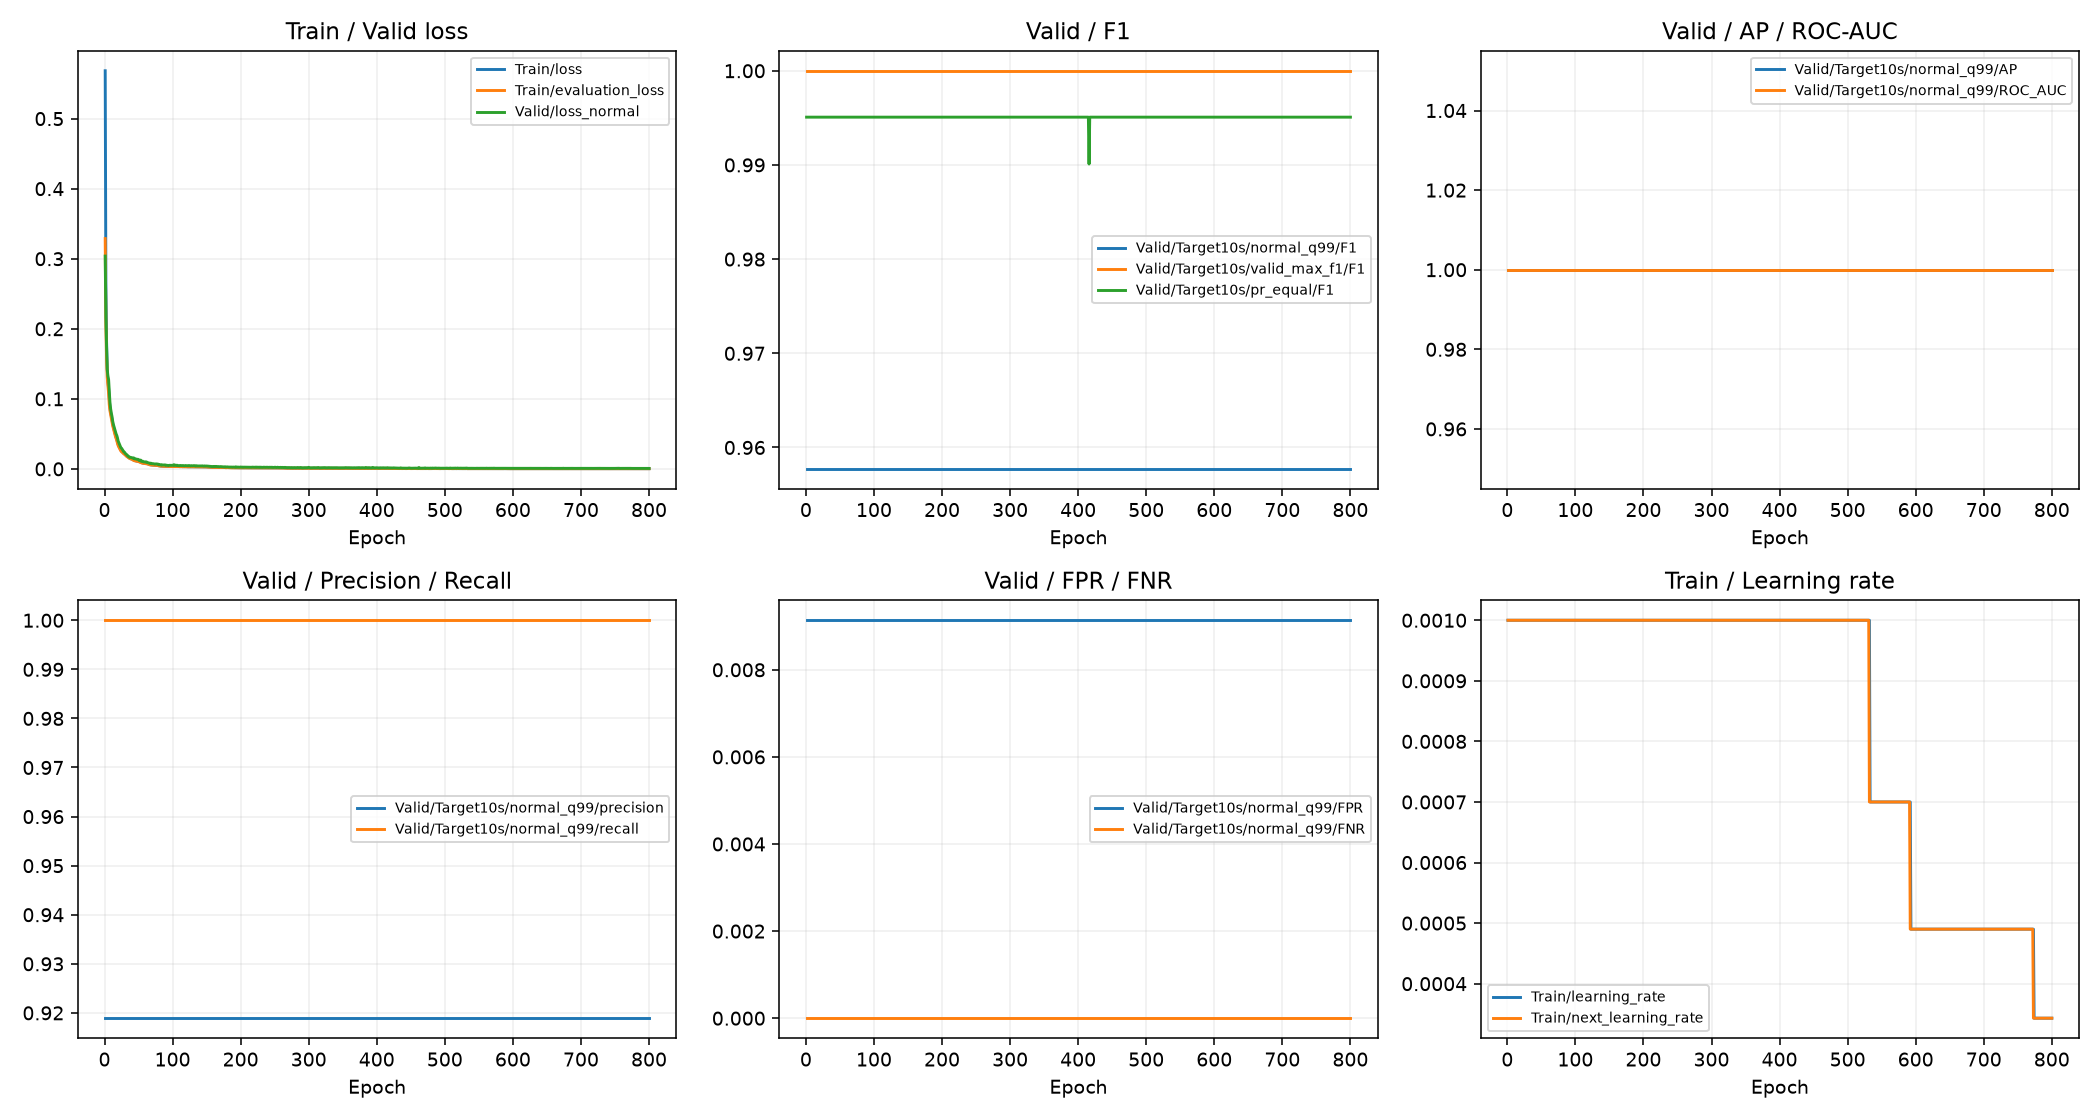

epoch 1: loss=0.568321, valid_normal=0.303741, AP=1.0000
epoch 2: loss=0.266042, valid_normal=0.215996, AP=1.0000
epoch 3: loss=0.181574, valid_normal=0.174188, AP=1.0000
epoch 4: loss=0.142093, valid_normal=0.142178, AP=1.0000
epoch 5: loss=0.125305, valid_normal=0.132165, AP=1.0000
epoch 6: loss=0.114787, valid_normal=0.127412, AP=1.0000
epoch 7: loss=0.0997271, valid_normal=0.110016, AP=1.0000
epoch 8: loss=0.0870883, valid_normal=0.0941724, AP=1.0000
epoch 9: loss=0.0805941, valid_normal=0.0855808, AP=1.0000
epoch 10: loss=0.075755, valid_normal=0.0795318, AP=1.0000
epoch 11: loss=0.0707093, valid_normal=0.0747158, AP=1.0000
epoch 12: loss=0.0644908, valid_normal=0.0681004, AP=1.0000
epoch 13: loss=0.0602042, valid_normal=0.0634683, AP=1.0000
epoch 14: loss=0.0559932, valid_normal=0.0600702, AP=1.0000
epoch 15: loss=0.0523206, valid_normal=0.0561457, AP=1.0000
epoch 16: loss=0.0485139, valid_normal=0.0530111, AP=1.0000
epoch 17: loss=0.0450691, valid_normal=0.0498972, AP=1.0000
epo

wandb: ERROR The nbformat package was not found. It is required to save notebook history.


Selection/best_normal_loss/AP,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
Selection/best_normal_loss/epoch,▁▁▁▁▂▂▂▃▃▃▃▃▃▄▄▄▄▅▅▅▆▆▆▆▆▆▆▇▇▇▇▇▇▇▇▇████
Timing/extra_train_evaluation_seconds,▃▆▆▆▆▇▆▆▇▇▇█▃█▃▁▆▄▃▂▄▄▄▃▅▂▃▄▃▄▂▄▄▃▂▃▂▄▂▃
Timing/save_seconds_before_checkpoint,▆▇▇▇▅▇▆▆▇▆▅▇▇██▅▅▁▃▅▃▄▄▅▆▄▃▄▄▆▄▃▂▆▃▃▅▅▄▅
Timing/train_seconds,▅▅▇▇█▇▆▃▆▅▇▇▇▇▇▃▃▃▃▃▄▂▂▂▃▄▄▄▄▃▃▁▂▃▃▁▃▃▃▃
Timing/valid_seconds,▁▃▄▁▃▃▃▄▂▃▂▃▂▆▃▃▃▂▂▂▂▃▃▅▃▃▂▃█▃▃▁▁▄▂▂▃▂▁▁
Train/evaluation_loss,█▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
Train/learning_rate,████████████████████████▄▄▄▁▁▁▁▁▁▁▁▁▁▁▁▁
Train/loss,█▃▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
Train/next_learning_rate,██████████████████████████████▃▃▃▃▃▃▃▃▁▁
+107,...


wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.


실험: [H08 Trial 0001] MLP | Sensor Encoder | FFT+P2P+RMS | raw-none_features-standard | s42 | 20261005T154656829541Z_918984
작업 폴더: [LOCAL_PATH_REDACTED]
최종 저장 폴더: [LOCAL_PATH_REDACTED]
W&B: online | Drive 백업: False


wandb: WARNING [wandb.login()] Changing session credentials to explicit value for https://api.wandb.ai.
wandb: Appending key for api.wandb.ai to your netrc file: [LOCAL_PATH_REDACTED]


,epoch,Train/loss,Valid/loss_normal,Train/learning_rate,Train/next_learning_rate,Valid/Target10s/normal_q99/F1,Valid/Target10s/normal_q99/AP,Valid/Target10s/normal_q99/ROC_AUC
799,800,0.003165,0.00466,0.000056,0.000056,0.957746,1.0,1.0


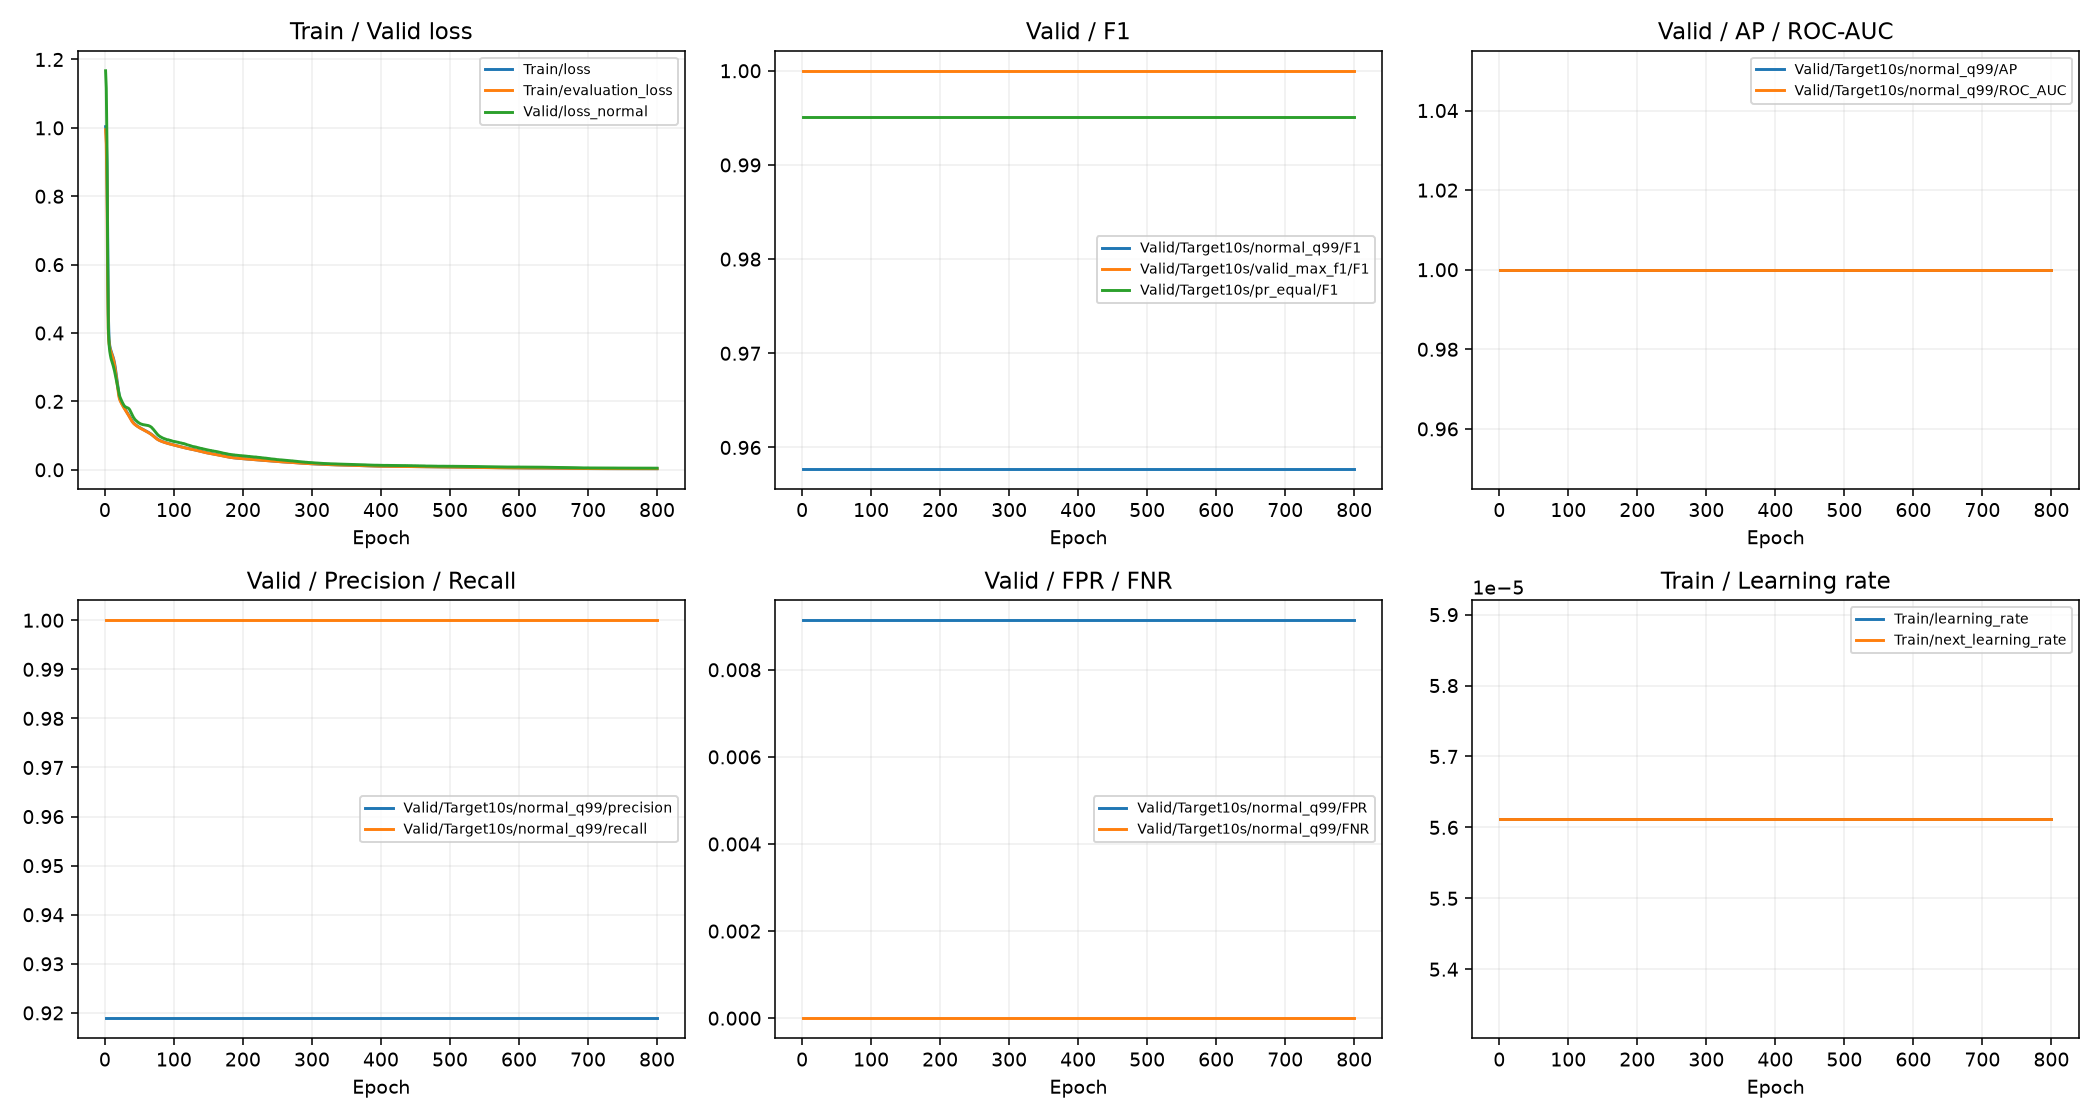

epoch 1: loss=1.00359, valid_normal=1.16705, AP=1.0000
epoch 2: loss=0.977864, valid_normal=1.11617, AP=1.0000
epoch 3: loss=0.898196, valid_normal=0.957559, AP=1.0000
epoch 4: loss=0.694078, valid_normal=0.626888, AP=1.0000
epoch 5: loss=0.455468, valid_normal=0.413874, AP=1.0000
epoch 6: loss=0.38136, valid_normal=0.367742, AP=1.0000
epoch 7: loss=0.3636, valid_normal=0.346928, AP=1.0000
epoch 8: loss=0.353822, valid_normal=0.334581, AP=1.0000
epoch 9: loss=0.346734, valid_normal=0.324504, AP=1.0000
epoch 10: loss=0.340771, valid_normal=0.317898, AP=1.0000
epoch 11: loss=0.335022, valid_normal=0.311147, AP=1.0000
epoch 12: loss=0.328742, valid_normal=0.304611, AP=1.0000
epoch 13: loss=0.321202, valid_normal=0.296441, AP=1.0000
epoch 14: loss=0.311778, valid_normal=0.288393, AP=1.0000
epoch 15: loss=0.299968, valid_normal=0.2782, AP=1.0000
epoch 16: loss=0.286148, valid_normal=0.268111, AP=1.0000
epoch 17: loss=0.271436, valid_normal=0.25731, AP=1.0000
epoch 18: loss=0.256513, valid_n

wandb: ERROR The nbformat package was not found. It is required to save notebook history.


Selection/best_normal_loss/AP,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
Selection/best_normal_loss/epoch,▁▁▁▂▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇▇███
Timing/extra_train_evaluation_seconds,▄▅▆▄█▅▆▇▆▆▅▇▂▆▄▇▂▂▁▁▂▄▆▆▃▅▆▄▇▅▆▆▆▇▆▅▃▅▇▄
Timing/save_seconds_before_checkpoint,▆▅▃▄▂▄▅▅▄▄█▅▄▄▅▄▂▅▂▂▅▅▂▄▁▃▅▅▄▃▂▂▄▅▅▄▄▅▂▅
Timing/train_seconds,█▅▇▇▆▃▆▂▇▇▅▇▂▄▄▄▆▆▅▇▆▄▇▆▁▂▆▆▇▆▆▇▆▅▅▃▇▆▇▇
Timing/valid_seconds,▅▃▄▃▄▆▂▄▂▅▅█▁▅▇▄▃▃▅▁▃▃▂▃▃▅▃▅▃▃▃▁▂▂▃▃▄▅▄▃
Train/evaluation_loss,█▆▅▅▄▃▃▃▃▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
Train/learning_rate,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
Train/loss,█▅▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
Train/next_learning_rate,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
+107,...


wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.


실험: [H08 Trial 0002] MLP | Sensor Encoder | FFT+P2P+RMS | raw-none_features-standard | s42 | 20261005T160759965929Z_36b596
작업 폴더: [LOCAL_PATH_REDACTED]
최종 저장 폴더: [LOCAL_PATH_REDACTED]
W&B: online | Drive 백업: False


wandb: WARNING [wandb.login()] Changing session credentials to explicit value for https://api.wandb.ai.
wandb: Appending key for api.wandb.ai to your netrc file: [LOCAL_PATH_REDACTED]


,epoch,Train/loss,Valid/loss_normal,Train/learning_rate,Train/next_learning_rate,Valid/Target10s/normal_q99/F1,Valid/Target10s/normal_q99/AP,Valid/Target10s/normal_q99/ROC_AUC
799,800,0.091509,0.079293,0.000021,0.000021,0.957746,1.0,1.0


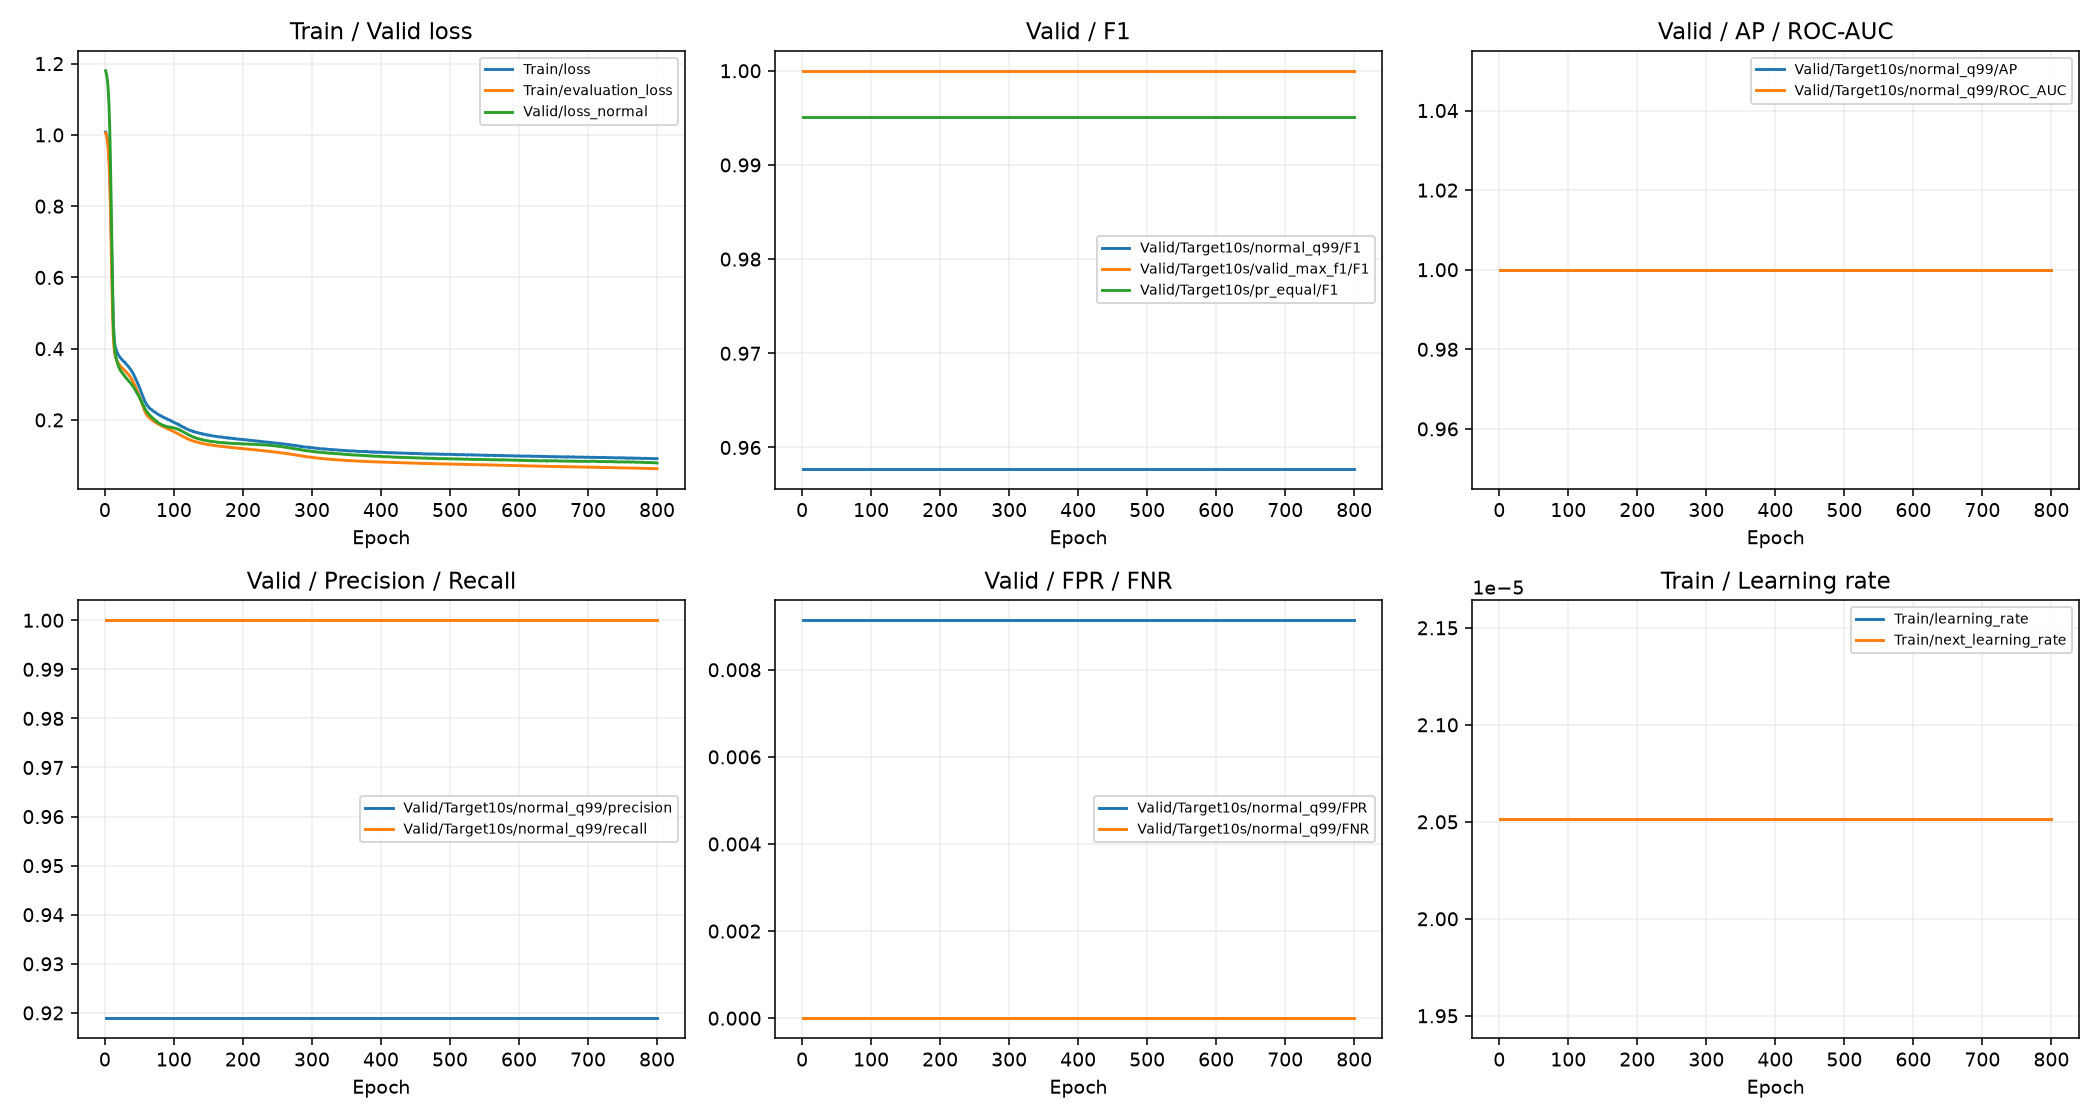

epoch 1: loss=1.00827, valid_normal=1.18004, AP=1.0000
epoch 2: loss=1.00312, valid_normal=1.17295, AP=1.0000
epoch 3: loss=0.996223, valid_normal=1.16283, AP=1.0000
epoch 4: loss=0.985485, valid_normal=1.1468, AP=1.0000
epoch 5: loss=0.968284, valid_normal=1.12145, AP=1.0000
epoch 6: loss=0.940917, valid_normal=1.0809, AP=1.0000
epoch 7: loss=0.898536, valid_normal=1.01887, AP=1.0000
epoch 8: loss=0.836485, valid_normal=0.92977, AP=1.0000
epoch 9: loss=0.752132, valid_normal=0.81415, AP=1.0000
epoch 10: loss=0.654562, valid_normal=0.686937, AP=1.0000
epoch 11: loss=0.558771, valid_normal=0.570028, AP=1.0000
epoch 12: loss=0.484337, valid_normal=0.484941, AP=1.0000
epoch 13: loss=0.440599, valid_normal=0.433209, AP=1.0000
epoch 14: loss=0.417737, valid_normal=0.404787, AP=1.0000
epoch 15: loss=0.40532, valid_normal=0.388159, AP=1.0000
epoch 16: loss=0.398967, valid_normal=0.37609, AP=1.0000
epoch 17: loss=0.393273, valid_normal=0.367364, AP=1.0000
epoch 18: loss=0.388471, valid_normal=

wandb: ERROR The nbformat package was not found. It is required to save notebook history.


Selection/best_normal_loss/AP,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
Selection/best_normal_loss/epoch,▁▁▁▁▁▂▂▂▃▃▃▃▄▄▄▄▄▄▄▄▅▅▅▅▅▆▆▆▆▆▆▆▇▇▇▇████
Timing/extra_train_evaluation_seconds,▅▅▇▃▅▆▇▄▆▄█▆▂▂▃▅▂▆▄▄▆▂█▄▃▆▅▂▆▄▄█▂▃▇▆▅▁▆▃
Timing/save_seconds_before_checkpoint,▆▅▅▃▆▅▂▄▆▄▅▆██▆▅▃▁▇▂▅▃▃▃▂▂▃▆▄▄▅▅▆▇▅▃▆▄▄▅
Timing/train_seconds,▆▇▆▄▆▆▇▅▇▅▅▇▂▇▁▂▃▆▃▆▆▄█▆▃▅▅▇▄▄▅▇▇▆▇▅▁▆▄▅
Timing/valid_seconds,▃▄▄▅▅▃▃▄▅▄▆▄▂▇▄▂▇▄▃▄▂▂▂▂▄▃▃▃▂▃▂▁▇▅▂▅█▄▅▂
Train/evaluation_loss,█▇▇▆▆▄▄▄▄▃▃▃▂▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
Train/learning_rate,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
Train/loss,█▇▆▃▃▃▃▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
Train/next_learning_rate,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
+107,...


wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.


실험: [H08 Trial 0003] MLP | Sensor Encoder | FFT+P2P+RMS | raw-none_features-standard | s42 | 20261005T163005311934Z_4d3b66
작업 폴더: [LOCAL_PATH_REDACTED]
최종 저장 폴더: [LOCAL_PATH_REDACTED]
W&B: online | Drive 백업: False


wandb: WARNING [wandb.login()] Changing session credentials to explicit value for https://api.wandb.ai.
wandb: Appending key for api.wandb.ai to your netrc file: [LOCAL_PATH_REDACTED]


,epoch,Train/loss,Valid/loss_normal,Train/learning_rate,Train/next_learning_rate,Valid/Target10s/normal_q99/F1,Valid/Target10s/normal_q99/AP,Valid/Target10s/normal_q99/ROC_AUC
799,800,0.053618,0.032786,0.000159,0.000159,0.957746,1.0,1.0


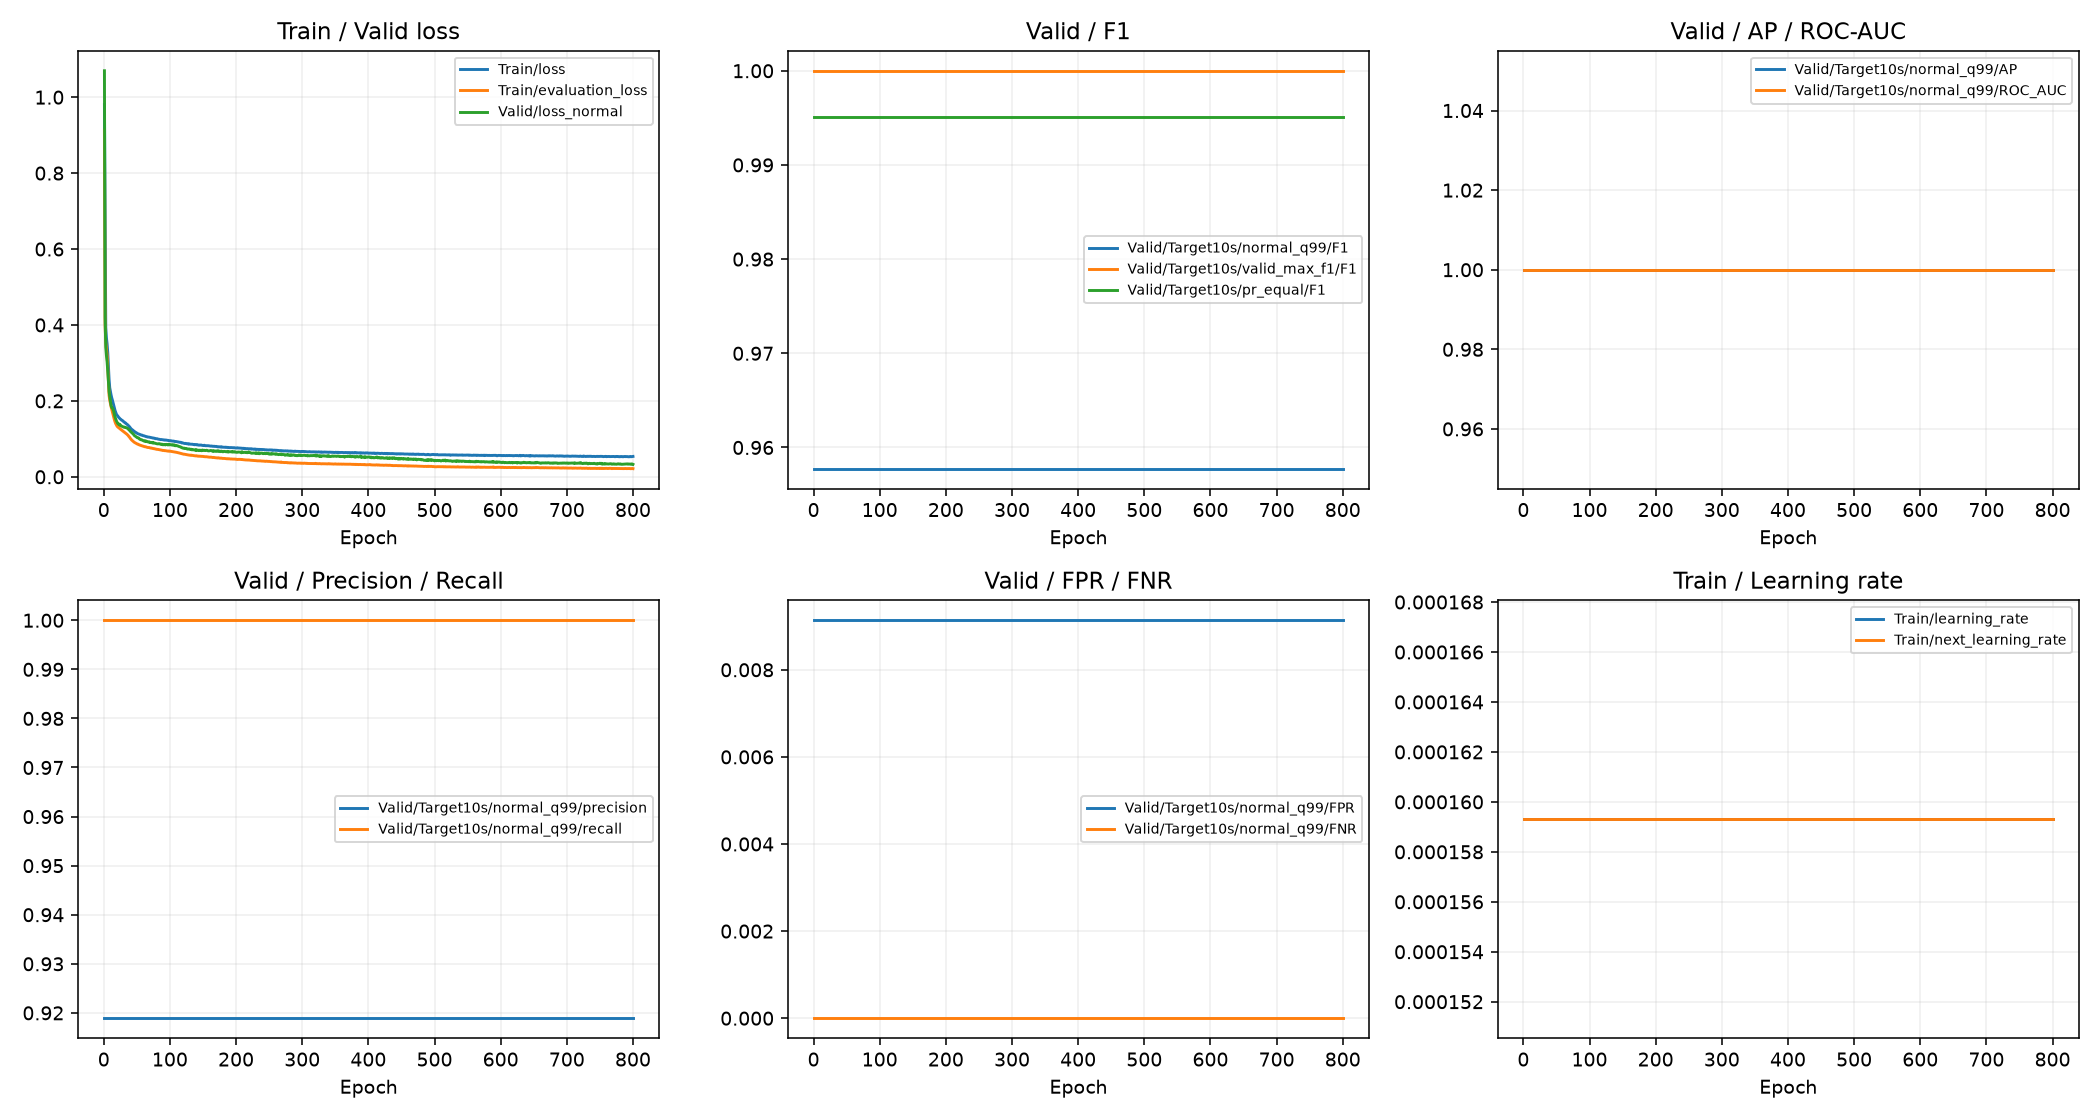

epoch 1: loss=0.980575, valid_normal=1.0696, AP=1.0000
epoch 2: loss=0.670353, valid_normal=0.420824, AP=1.0000
epoch 3: loss=0.393487, valid_normal=0.341141, AP=1.0000
epoch 4: loss=0.366285, valid_normal=0.319415, AP=1.0000
epoch 5: loss=0.350321, valid_normal=0.303477, AP=1.0000
epoch 6: loss=0.327304, valid_normal=0.279398, AP=1.0000
epoch 7: loss=0.293068, valid_normal=0.252462, AP=1.0000
epoch 8: loss=0.256767, valid_normal=0.22468, AP=1.0000
epoch 9: loss=0.234717, valid_normal=0.210852, AP=1.0000
epoch 10: loss=0.224598, valid_normal=0.199103, AP=1.0000
epoch 11: loss=0.215918, valid_normal=0.188031, AP=1.0000
epoch 12: loss=0.208173, valid_normal=0.182252, AP=1.0000
epoch 13: loss=0.202161, valid_normal=0.18142, AP=1.0000
epoch 14: loss=0.194996, valid_normal=0.177039, AP=1.0000
epoch 15: loss=0.18879, valid_normal=0.172861, AP=1.0000
epoch 16: loss=0.181882, valid_normal=0.164453, AP=1.0000
epoch 17: loss=0.174881, valid_normal=0.157576, AP=1.0000
epoch 18: loss=0.170169, val

wandb: ERROR The nbformat package was not found. It is required to save notebook history.


Selection/best_normal_loss/AP,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
Selection/best_normal_loss/epoch,▁▁▁▁▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▄▄▄▅▅▅▅▆▆▆▆▇▇▇▇▇▇▇██
Timing/extra_train_evaluation_seconds,▅▂▄▃▅▄▄▅▆▆▅▅▅▄▅▅▂▆▃▂▃▁▇▆▅▆▇█▆▅▇▃▃▅▇▅▅▅▁▃
Timing/save_seconds_before_checkpoint,▅▄▂▄▂▃▂▄▁▂▄▂▃▂▄▂▃▃▃▂▃▂▃▁▂▃▄▅▆▃▄▅▁▄▃█▃▃▁▃
Timing/train_seconds,▁▂▁▃█▃▅▄▅▄▄▆▃▅▂▇▅▅▅▃▇▆▅▆█▇▆▅▄▄▅▆▅▅▄▆▆▇▇▇
Timing/valid_seconds,▁▅▄▅█▂▃▂▃▃▃▆▂▂▃▃▃▃▂▄▃▃▄▃▃▃▇▄▂▂▃▄▄▃▃▂▃▄▄▃
Train/evaluation_loss,██▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
Train/learning_rate,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
Train/loss,█▆▅▅▃▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
Train/next_learning_rate,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
+107,...


wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.


실험: [H08 Trial 0004] MLP | Sensor Encoder | FFT+P2P+RMS | raw-none_features-standard | s42 | 20261005T165117963258Z_91fd6b
작업 폴더: [LOCAL_PATH_REDACTED]
최종 저장 폴더: [LOCAL_PATH_REDACTED]
W&B: online | Drive 백업: False


wandb: WARNING [wandb.login()] Changing session credentials to explicit value for https://api.wandb.ai.
wandb: Appending key for api.wandb.ai to your netrc file: [LOCAL_PATH_REDACTED]


,epoch,Train/loss,Valid/loss_normal,Train/learning_rate,Train/next_learning_rate,Valid/Target10s/normal_q99/F1,Valid/Target10s/normal_q99/AP,Valid/Target10s/normal_q99/ROC_AUC
799,800,0.000246,0.000559,0.000446,0.000446,0.957746,1.0,1.0


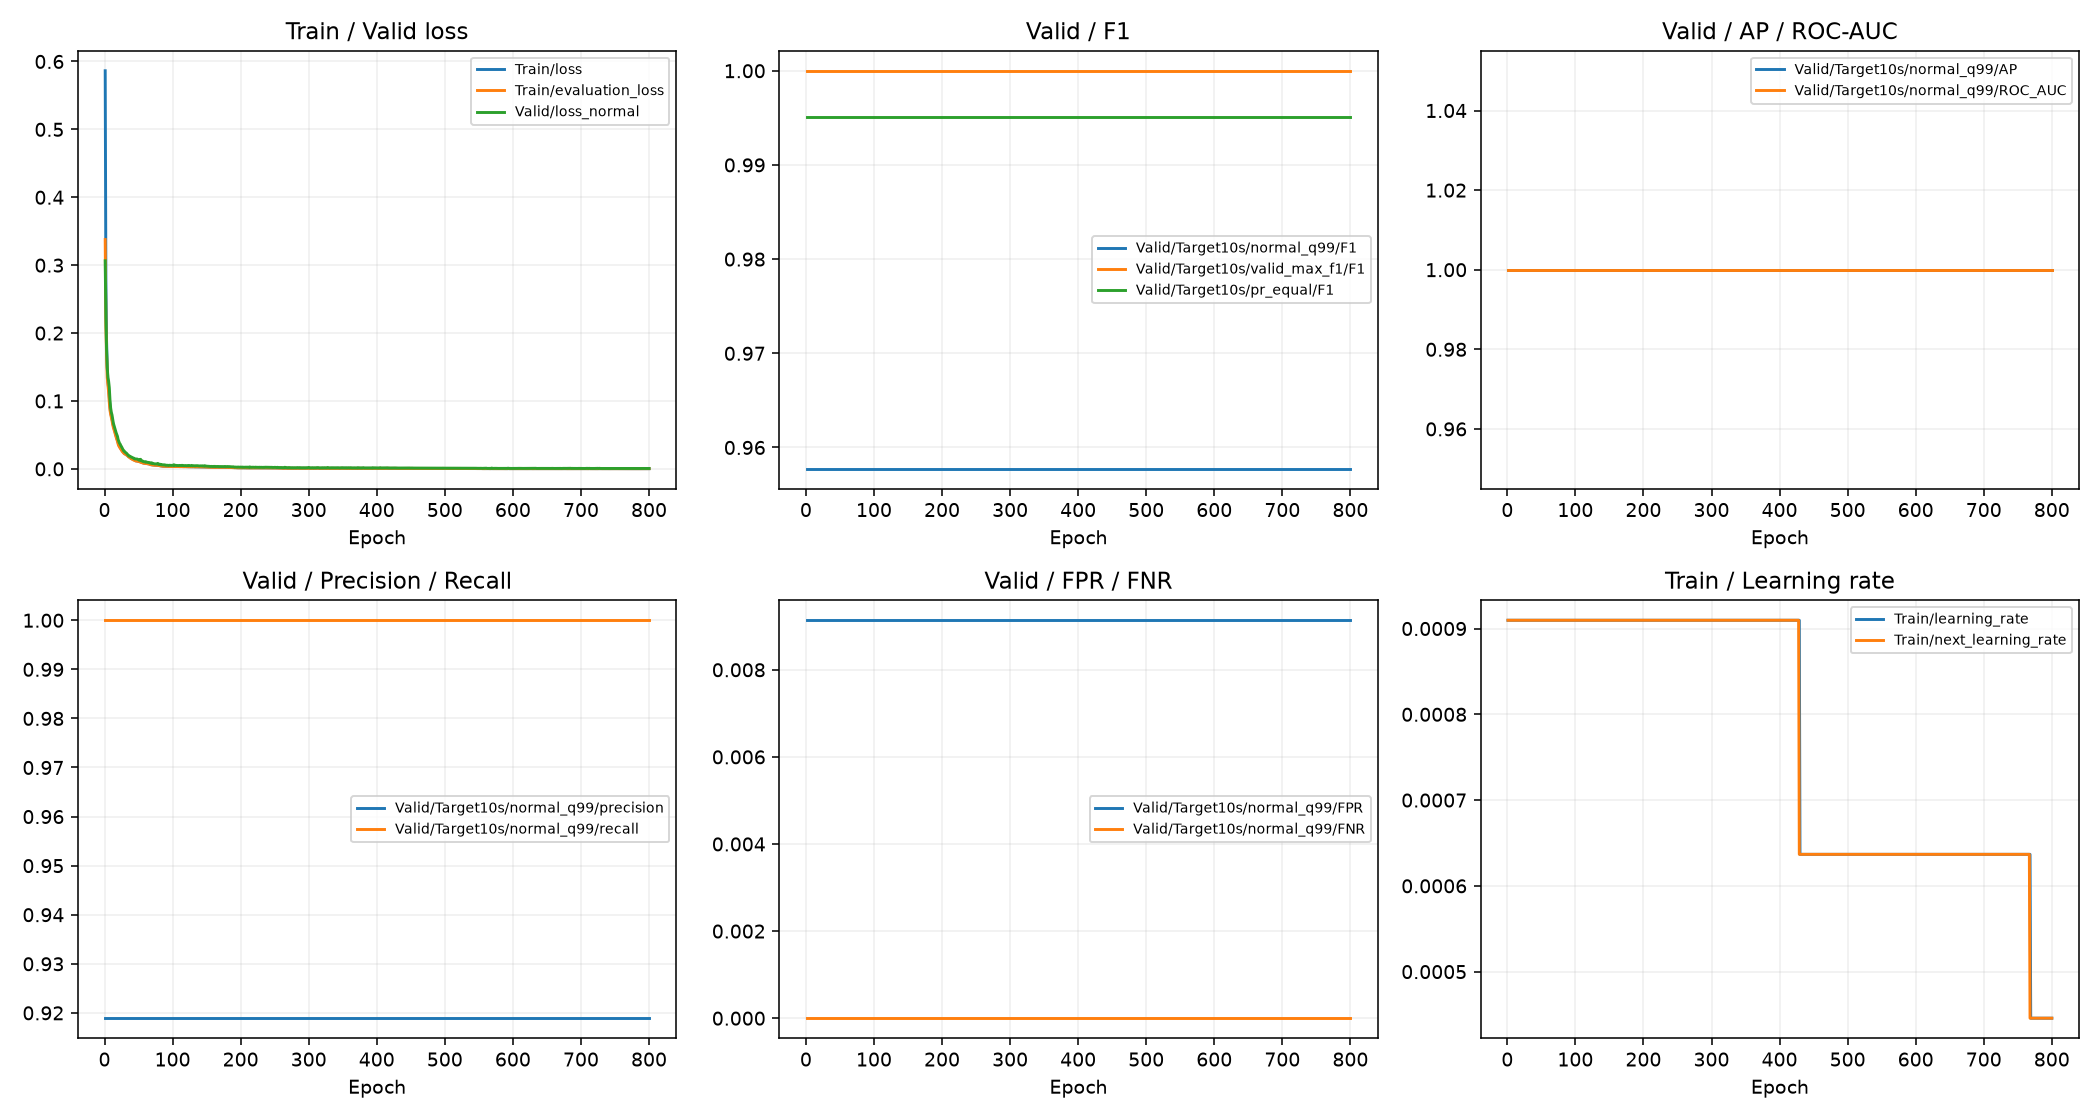

epoch 1: loss=0.586314, valid_normal=0.306452, AP=1.0000
epoch 2: loss=0.279797, valid_normal=0.222012, AP=1.0000
epoch 3: loss=0.188671, valid_normal=0.1758, AP=1.0000
epoch 4: loss=0.149397, valid_normal=0.149906, AP=1.0000
epoch 5: loss=0.128641, valid_normal=0.134248, AP=1.0000
epoch 6: loss=0.118656, valid_normal=0.129211, AP=1.0000
epoch 7: loss=0.106688, valid_normal=0.119878, AP=1.0000
epoch 8: loss=0.0918646, valid_normal=0.101672, AP=1.0000
epoch 9: loss=0.0834451, valid_normal=0.0897162, AP=1.0000
epoch 10: loss=0.078499, valid_normal=0.0831292, AP=1.0000
epoch 11: loss=0.0739827, valid_normal=0.0793873, AP=1.0000
epoch 12: loss=0.0685586, valid_normal=0.0735756, AP=1.0000
epoch 13: loss=0.0634528, valid_normal=0.067156, AP=1.0000
epoch 14: loss=0.0597743, valid_normal=0.0635854, AP=1.0000
epoch 15: loss=0.0561527, valid_normal=0.0599409, AP=1.0000
epoch 16: loss=0.0525508, valid_normal=0.0570194, AP=1.0000
epoch 17: loss=0.0488119, valid_normal=0.0532788, AP=1.0000
epoch 18

wandb: ERROR The nbformat package was not found. It is required to save notebook history.


Selection/best_normal_loss/AP,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
Selection/best_normal_loss/epoch,▁▁▁▁▁▁▁▂▂▂▂▂▂▂▃▃▃▃▃▃▄▄▄▄▄▅▅▅▅▆▆▆▆▆▆▇▇▇▇█
Timing/extra_train_evaluation_seconds,▄▅▅▅▅▆▅▂▄▃▆▄▃▄▃▃▅▅▅█▅▂▁▃▄▃▄▅▂▆▄▅▂▆▅▇▃▄▇▇
Timing/save_seconds_before_checkpoint,▂▅▃▅▁▄▄▅▆▅▅▆▅▃█▄▃▂▅▃▁▄▄▂▂▂▅▅▄▇▅▃▁▂▂▂▂▃▄▄
Timing/train_seconds,▇▆▇▆█▆▄▁▅▅▆▇█▆▄▇▆▇▄▆▇█▂▂▄▅▆█▃▇▆▆▄▅█▆▅▆▆▅
Timing/valid_seconds,▃▃█▃▄▃▃▃▄▁▃▃▃▄▄▃▃▂▂▃▃▁▂▃▄▂▃▃▁▄▃▄▃▂▃▃▂▅▂▂
Train/evaluation_loss,█▄▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
Train/learning_rate,███████████████████████▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▁▁
Train/loss,█▃▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
Train/next_learning_rate,███████████████████▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▁
+107,...


wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.


실험: [H08 Trial 0005] MLP | Sensor Encoder | FFT+P2P+RMS | raw-none_features-standard | s42 | 20261005T171232107520Z_0948f6
작업 폴더: [LOCAL_PATH_REDACTED]
최종 저장 폴더: [LOCAL_PATH_REDACTED]
W&B: online | Drive 백업: False


wandb: WARNING [wandb.login()] Changing session credentials to explicit value for https://api.wandb.ai.
wandb: Appending key for api.wandb.ai to your netrc file: [LOCAL_PATH_REDACTED]


,epoch,Train/loss,Valid/loss_normal,Train/learning_rate,Train/next_learning_rate,Valid/Target10s/normal_q99/F1,Valid/Target10s/normal_q99/AP,Valid/Target10s/normal_q99/ROC_AUC
799,800,0.022653,0.013869,0.000102,0.000102,0.957746,1.0,1.0


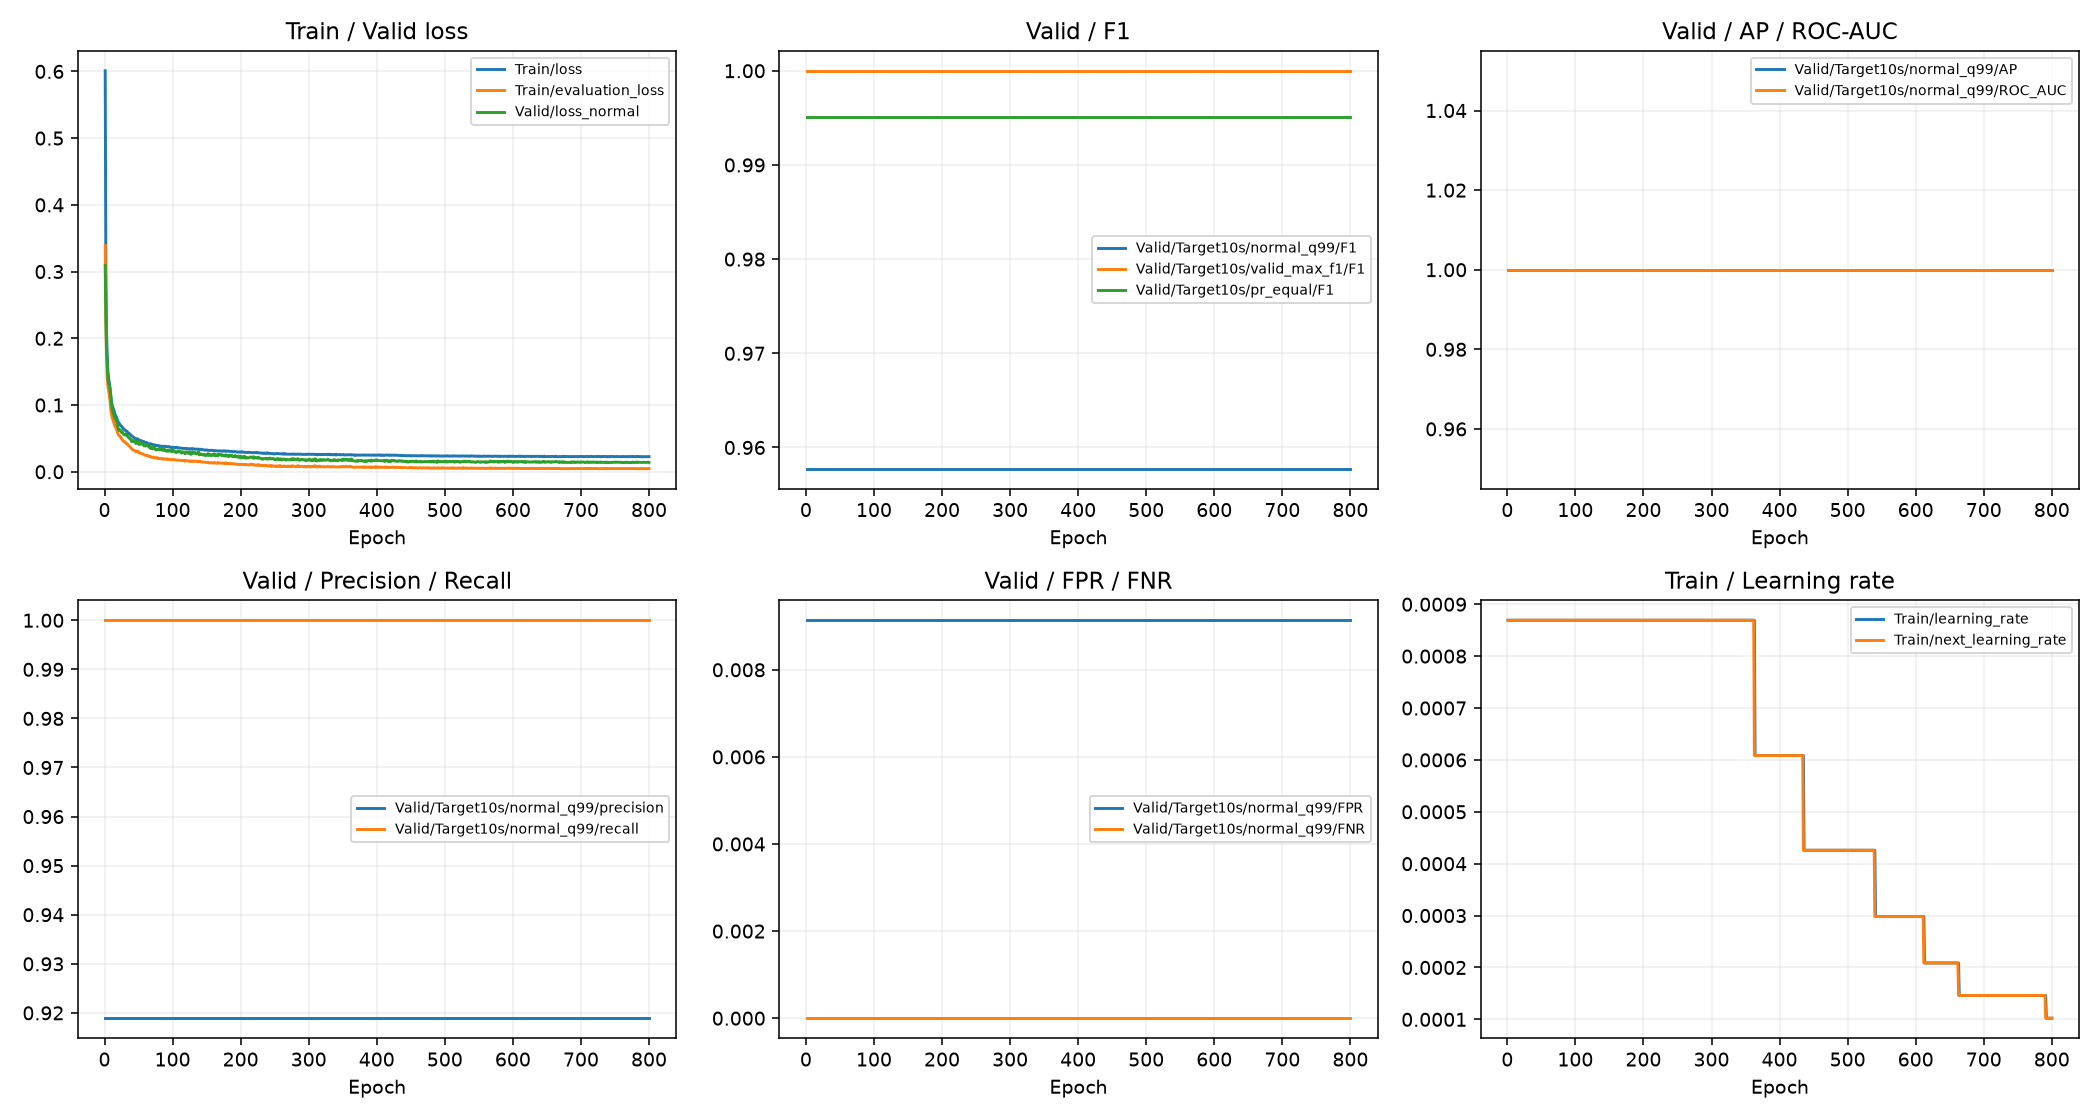

epoch 1: loss=0.600937, valid_normal=0.308939, AP=1.0000
epoch 2: loss=0.299982, valid_normal=0.231217, AP=1.0000
epoch 3: loss=0.208734, valid_normal=0.180775, AP=1.0000
epoch 4: loss=0.173965, valid_normal=0.159062, AP=1.0000
epoch 5: loss=0.149599, valid_normal=0.139282, AP=1.0000
epoch 6: loss=0.140498, valid_normal=0.132237, AP=1.0000
epoch 7: loss=0.133491, valid_normal=0.129315, AP=1.0000
epoch 8: loss=0.126109, valid_normal=0.12497, AP=1.0000
epoch 9: loss=0.116894, valid_normal=0.113789, AP=1.0000
epoch 10: loss=0.107299, valid_normal=0.102603, AP=1.0000
epoch 11: loss=0.101058, valid_normal=0.0957007, AP=1.0000
epoch 12: loss=0.0971117, valid_normal=0.0908582, AP=1.0000
epoch 13: loss=0.0943292, valid_normal=0.0877461, AP=1.0000
epoch 14: loss=0.0913622, valid_normal=0.0836985, AP=1.0000
epoch 15: loss=0.0875878, valid_normal=0.0802928, AP=1.0000
epoch 16: loss=0.0846753, valid_normal=0.0787067, AP=1.0000
epoch 17: loss=0.0833119, valid_normal=0.0769035, AP=1.0000
epoch 18: l

wandb: ERROR The nbformat package was not found. It is required to save notebook history.


Selection/best_normal_loss/AP,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
Selection/best_normal_loss/epoch,▁▁▁▁▁▁▂▂▃▃▃▄▄▄▄▄▅▅▅▅▅▆▆▆▆▆▆▆▆▆▆▆▆▆██████
Timing/extra_train_evaluation_seconds,▆▆▅▄▇▄▃▅▄▄█▅▁▃▂▂▅▆▇▃▃▇▃▂▄▂▇█▇▆▆▄▆▅▅▂▆▇▅▃
Timing/save_seconds_before_checkpoint,▃▅▄▄▅▅█▄▄▆▃▃▅▃▇▆▅▃▃▂▄▃▁▂▄▅▂▁▄▄▄▂▄▅▅▄▃▅▂▅
Timing/train_seconds,▆▅▆▆▇▃▆█▇▆▅▆▆▅▆█▃▂▁▇▇▄▂▂▃▄▆▇▅▇▇▆▇▆▇▇▆▇▅▅
Timing/valid_seconds,▂▄▂▃▁▂▃▂▂▂▁▄▃▃▅▂▃▂▂▃█▁▃▁▂▃▂▂▂▁▄▂▂▂▂▃▁▂▂▃
Train/evaluation_loss,█▇▄▃▃▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
Train/learning_rate,███████████████████▆▄▄▄▄▄▃▂▂▂▁▁▁▁▁▁▁▁▁▁▁
Train/loss,█▆▆▄▄▂▂▂▂▂▂▁▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
Train/next_learning_rate,█████████████████▆▆▆▄▄▄▄▃▃▂▂▂▂▁▁▁▁▁▁▁▁▁▁
+107,...


wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.


실험: [H08 Trial 0006] MLP | Sensor Encoder | FFT+P2P+RMS | raw-none_features-standard | s42 | 20261005T173344793241Z_c69059
작업 폴더: [LOCAL_PATH_REDACTED]
최종 저장 폴더: [LOCAL_PATH_REDACTED]
W&B: online | Drive 백업: False


wandb: WARNING [wandb.login()] Changing session credentials to explicit value for https://api.wandb.ai.
wandb: Appending key for api.wandb.ai to your netrc file: [LOCAL_PATH_REDACTED]


,epoch,Train/loss,Valid/loss_normal,Train/learning_rate,Train/next_learning_rate,Valid/Target10s/normal_q99/F1,Valid/Target10s/normal_q99/AP,Valid/Target10s/normal_q99/ROC_AUC
799,800,0.000616,0.001214,0.000224,0.000224,0.957746,1.0,1.0


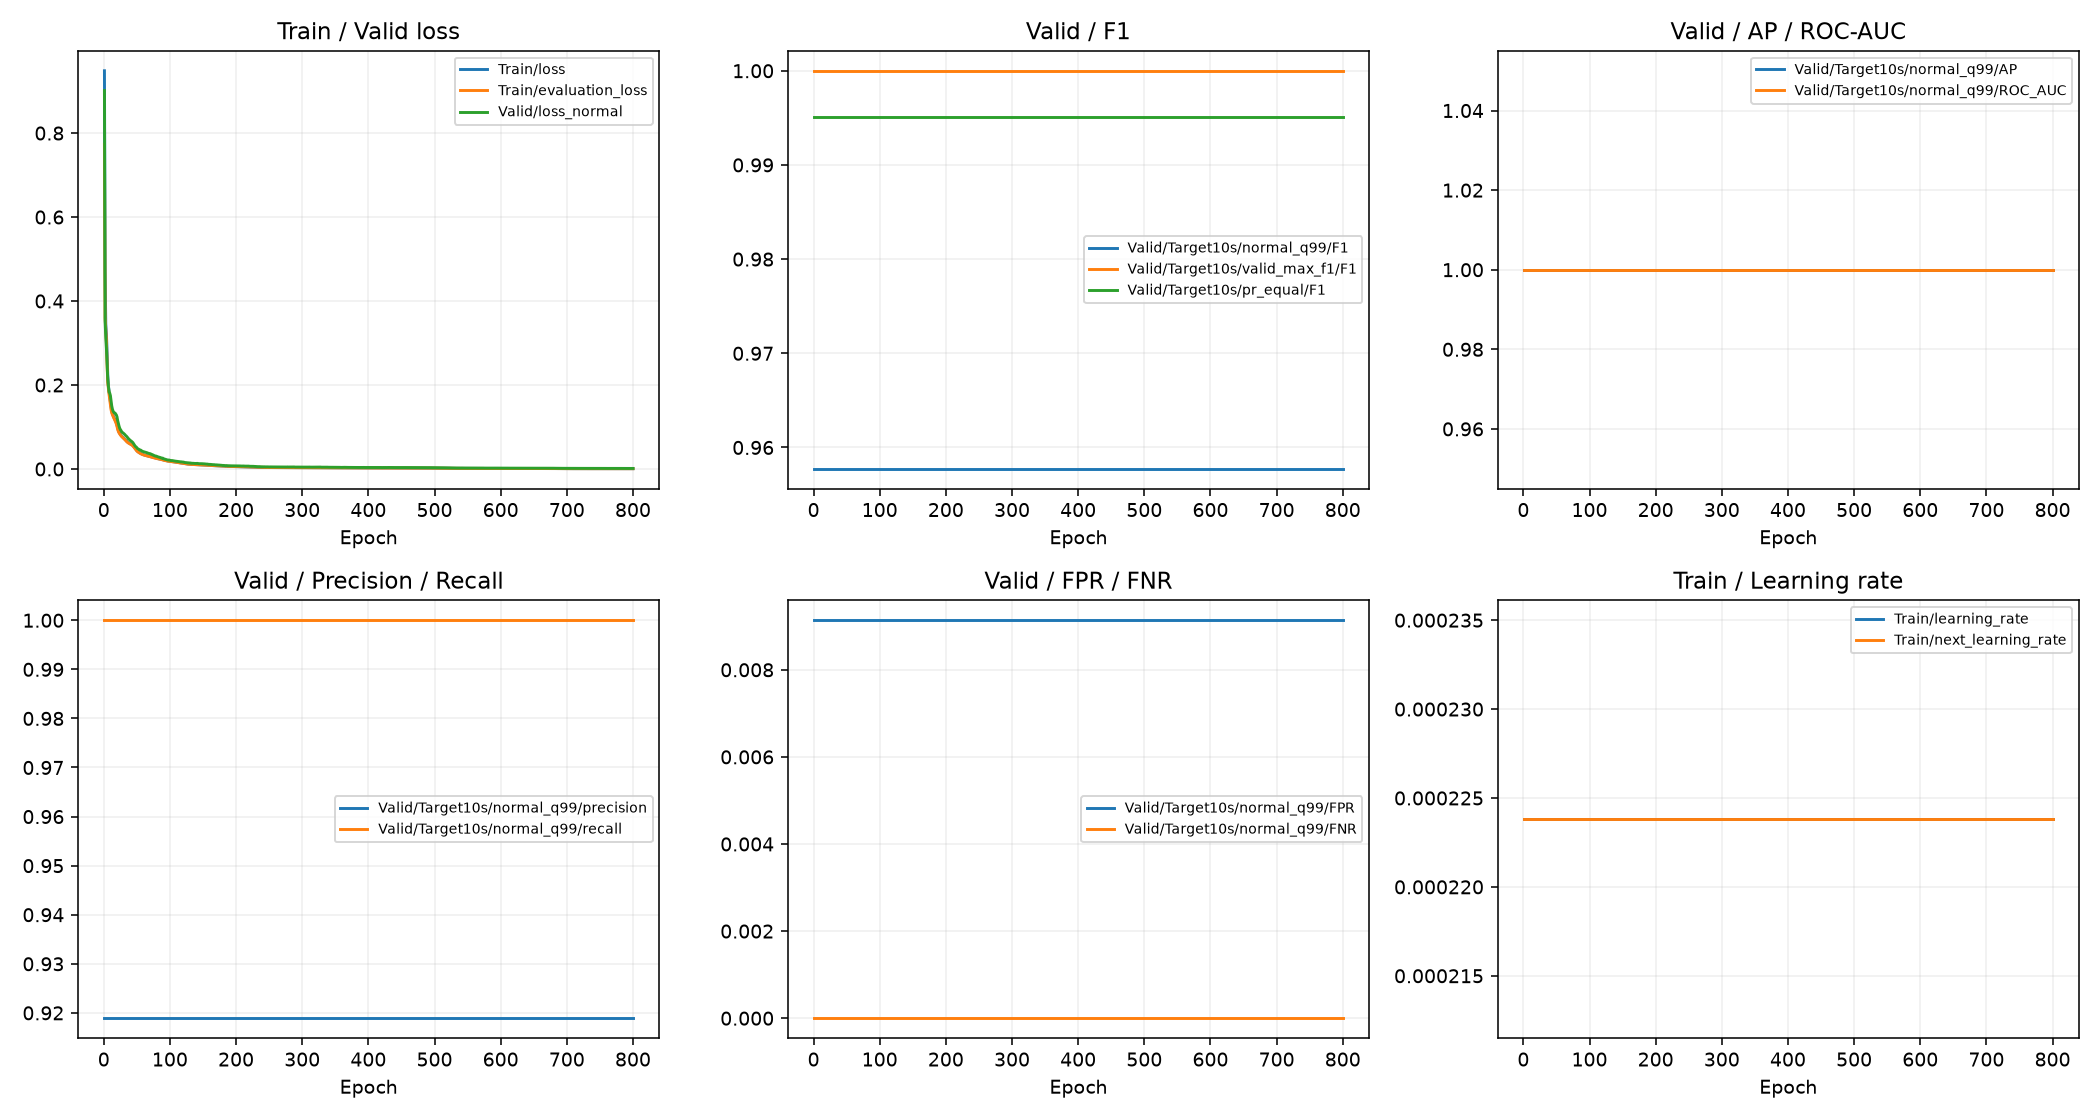

epoch 1: loss=0.948379, valid_normal=0.90119, AP=1.0000
epoch 2: loss=0.474337, valid_normal=0.352849, AP=1.0000
epoch 3: loss=0.345816, valid_normal=0.313243, AP=1.0000
epoch 4: loss=0.320696, valid_normal=0.286858, AP=1.0000
epoch 5: loss=0.277674, valid_normal=0.250844, AP=1.0000
epoch 6: loss=0.223853, valid_normal=0.21404, AP=1.0000
epoch 7: loss=0.19805, valid_normal=0.196705, AP=1.0000
epoch 8: loss=0.184181, valid_normal=0.183326, AP=1.0000
epoch 9: loss=0.171949, valid_normal=0.180602, AP=1.0000
epoch 10: loss=0.159956, valid_normal=0.174832, AP=1.0000
epoch 11: loss=0.147136, valid_normal=0.162236, AP=1.0000
epoch 12: loss=0.137558, valid_normal=0.150442, AP=1.0000
epoch 13: loss=0.131671, valid_normal=0.142953, AP=1.0000
epoch 14: loss=0.127421, valid_normal=0.137861, AP=1.0000
epoch 15: loss=0.123843, valid_normal=0.135208, AP=1.0000
epoch 16: loss=0.120463, valid_normal=0.133532, AP=1.0000
epoch 17: loss=0.117073, valid_normal=0.133175, AP=1.0000
epoch 18: loss=0.113577, v

wandb: ERROR The nbformat package was not found. It is required to save notebook history.


Selection/best_normal_loss/AP,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
Selection/best_normal_loss/epoch,▁▁▁▁▂▂▂▂▂▂▂▂▂▂▂▃▃▃▃▃▄▄▅▅▅▅▆▆▆▆▇▇▇▇▇▇████
Timing/extra_train_evaluation_seconds,▇▇▇▅▅▅▄▃▂▄▆▅▃▇▃▅▇▇▅▆▆█▆▆█▆▄▆▁█▆▇▄▂▆▆▆▆▇▂
Timing/save_seconds_before_checkpoint,▅▇▂▆▆▄█▄▅▇▃█▆█▇▃▅▄▅▆▇▅▆▃▆▃▁▇▂▄▄▃▅▆▅▆▆▅▆▄
Timing/train_seconds,▅▃▃▃▁▇▄▇█▇▆▄▇▇▇▇▇▆█▆▇▆▇▇█▇▇▇▆▆▇▇▇▆▇▆▇█▆▆
Timing/valid_seconds,▃▁▃▃▁▂▂▃▂▂▃▂▂▂▃▂▃▃▂▂▂▃▃▂▂▂▃▃▄▂▃▆█▃▂▃▂▁▂▁
Train/evaluation_loss,█▃▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
Train/learning_rate,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
Train/loss,█▄▄▃▃▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
Train/next_learning_rate,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
+107,...


wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.


실험: [H08 Trial 0007] MLP | Sensor Encoder | FFT+P2P+RMS | raw-none_features-standard | s42 | 20261005T175511459495Z_3b8aae
작업 폴더: [LOCAL_PATH_REDACTED]
최종 저장 폴더: [LOCAL_PATH_REDACTED]
W&B: online | Drive 백업: False


wandb: WARNING [wandb.login()] Changing session credentials to explicit value for https://api.wandb.ai.
wandb: Appending key for api.wandb.ai to your netrc file: [LOCAL_PATH_REDACTED]


,epoch,Train/loss,Valid/loss_normal,Train/learning_rate,Train/next_learning_rate,Valid/Target10s/normal_q99/F1,Valid/Target10s/normal_q99/AP,Valid/Target10s/normal_q99/ROC_AUC
799,800,0.086036,0.081457,0.000011,0.000011,0.957746,1.0,1.0


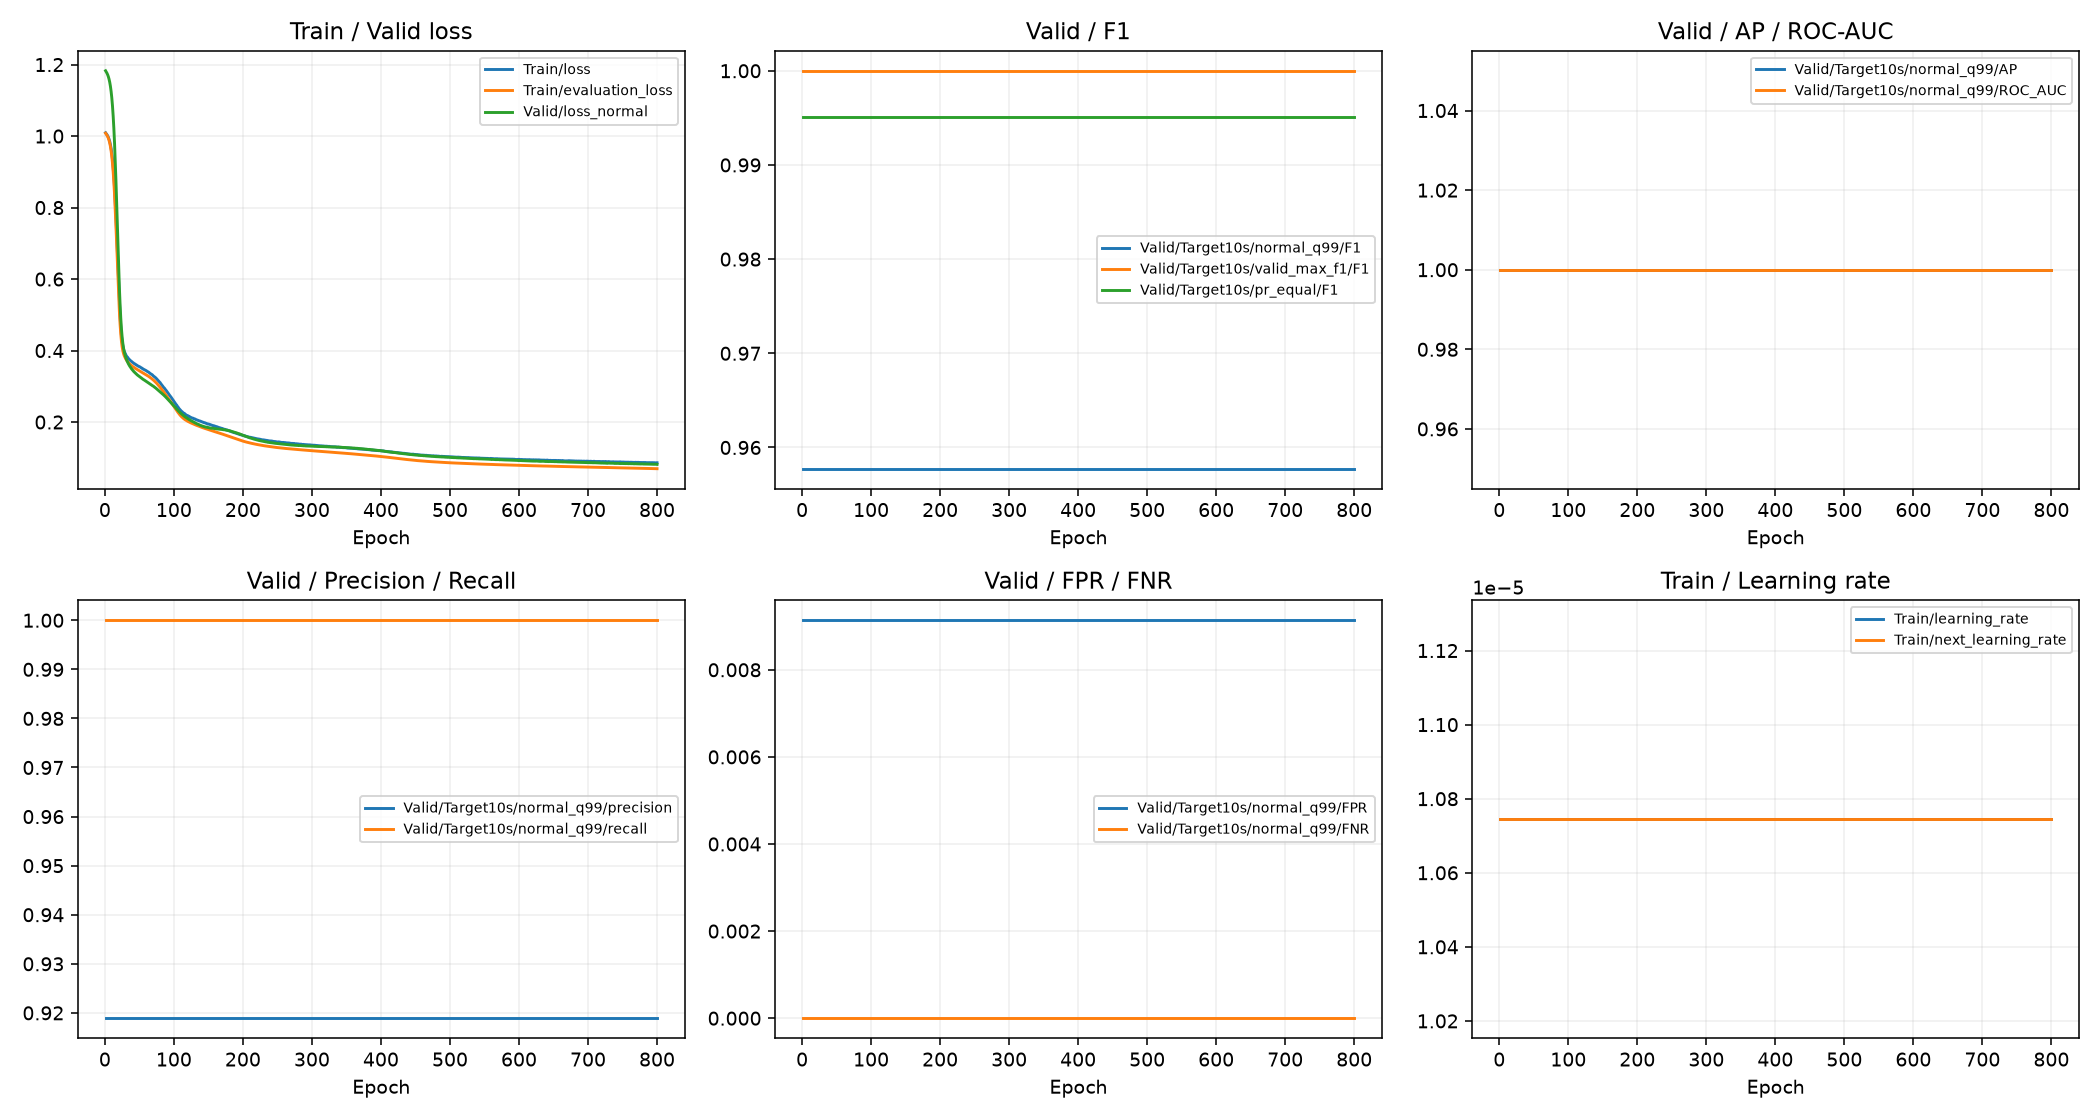

epoch 1: loss=1.00928, valid_normal=1.1827, AP=1.0000
epoch 2: loss=1.00676, valid_normal=1.17951, AP=1.0000
epoch 3: loss=1.00388, valid_normal=1.17596, AP=1.0000
epoch 4: loss=1.00079, valid_normal=1.17162, AP=1.0000
epoch 5: loss=0.9965, valid_normal=1.16625, AP=1.0000
epoch 6: loss=0.991416, valid_normal=1.15938, AP=1.0000
epoch 7: loss=0.9848, valid_normal=1.15067, AP=1.0000
epoch 8: loss=0.97623, valid_normal=1.13949, AP=1.0000
epoch 9: loss=0.965546, valid_normal=1.12514, AP=1.0000
epoch 10: loss=0.951917, valid_normal=1.10718, AP=1.0000
epoch 11: loss=0.934839, valid_normal=1.08425, AP=1.0000
epoch 12: loss=0.912908, valid_normal=1.05582, AP=1.0000
epoch 13: loss=0.886869, valid_normal=1.02107, AP=1.0000
epoch 14: loss=0.855148, valid_normal=0.979479, AP=1.0000
epoch 15: loss=0.817308, valid_normal=0.930781, AP=1.0000
epoch 16: loss=0.775102, valid_normal=0.875675, AP=1.0000
epoch 17: loss=0.727739, valid_normal=0.815445, AP=1.0000
epoch 18: loss=0.67678, valid_normal=0.752674,

wandb: ERROR The nbformat package was not found. It is required to save notebook history.


Selection/best_normal_loss/AP,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
Selection/best_normal_loss/epoch,▁▁▁▁▁▂▂▂▂▂▃▃▃▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇▇███
Timing/extra_train_evaluation_seconds,▇▅▆▅▆█▃▄▆▅▄▄▃▃▄▅▄▆▅▅▃▆▅▆▁▄▅▃▆▅▅▇▄▇▆▄▇▅▆▅
Timing/save_seconds_before_checkpoint,█▅█▆▃▅▅▅▄▅▃▆▅▇▄▄▂▄▄▂▄▅▅▅▃▂▄▁▆▅▅▅▅▂▇▅▃▃▄▃
Timing/train_seconds,▇▆▇▆▇▇▇▆█▇█▅▇▇█▄▅▁▇▅▅▆▅▇▅▆▅▇▇█▇▇▇▇▇▆▆▅▇▅
Timing/valid_seconds,█▂▂▂▄▃▂▃▂▂▂▂▂▃▃▁▃▂▁▁▂▂▃▂▂▂▂▂▂▂▃▃▃▂▂▂▂▂▂▁
Train/evaluation_loss,█▆▃▃▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
Train/learning_rate,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
Train/loss,█▄▄▄▃▂▂▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
Train/next_learning_rate,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
+107,...


wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.


실험: [H08 Trial 0008] MLP | Sensor Encoder | FFT+P2P+RMS | raw-none_features-standard | s42 | 20261005T181703907661Z_0fd20b
작업 폴더: [LOCAL_PATH_REDACTED]
최종 저장 폴더: [LOCAL_PATH_REDACTED]
W&B: online | Drive 백업: False


wandb: WARNING [wandb.login()] Changing session credentials to explicit value for https://api.wandb.ai.
wandb: Appending key for api.wandb.ai to your netrc file: [LOCAL_PATH_REDACTED]


,epoch,Train/loss,Valid/loss_normal,Train/learning_rate,Train/next_learning_rate,Valid/Target10s/normal_q99/F1,Valid/Target10s/normal_q99/AP,Valid/Target10s/normal_q99/ROC_AUC
799,800,0.000549,0.000973,0.000369,0.000369,0.957746,1.0,1.0


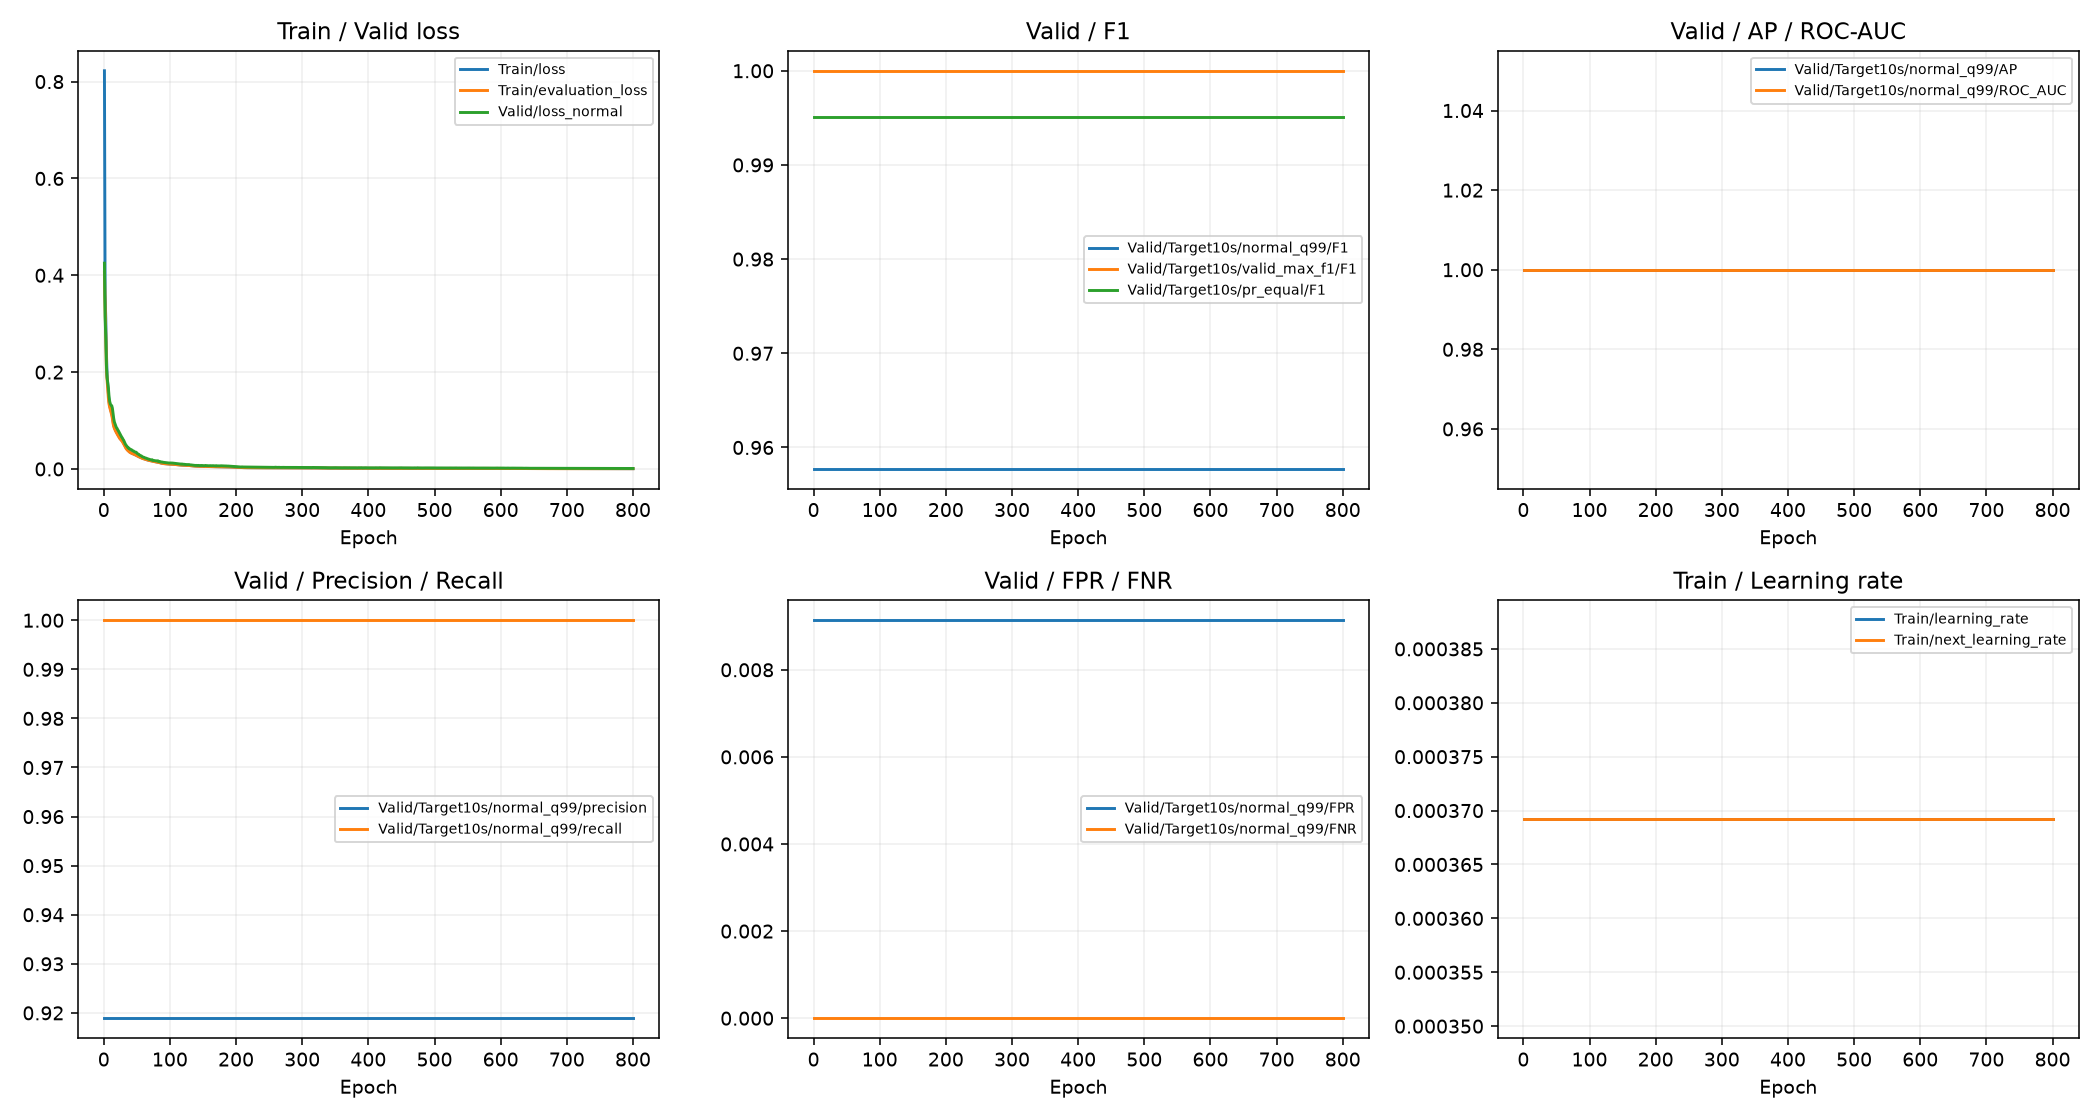

epoch 1: loss=0.822378, valid_normal=0.424972, AP=1.0000
epoch 2: loss=0.361512, valid_normal=0.314817, AP=1.0000
epoch 3: loss=0.311112, valid_normal=0.271329, AP=1.0000
epoch 4: loss=0.239207, valid_normal=0.213801, AP=1.0000
epoch 5: loss=0.194969, valid_normal=0.188498, AP=1.0000
epoch 6: loss=0.174871, valid_normal=0.177688, AP=1.0000
epoch 7: loss=0.155875, valid_normal=0.16658, AP=1.0000
epoch 8: loss=0.139042, valid_normal=0.148698, AP=1.0000
epoch 9: loss=0.130371, valid_normal=0.139169, AP=1.0000
epoch 10: loss=0.124761, valid_normal=0.133952, AP=1.0000
epoch 11: loss=0.11982, valid_normal=0.131644, AP=1.0000
epoch 12: loss=0.114673, valid_normal=0.130757, AP=1.0000
epoch 13: loss=0.108328, valid_normal=0.125604, AP=1.0000
epoch 14: loss=0.0993753, valid_normal=0.114942, AP=1.0000
epoch 15: loss=0.0910472, valid_normal=0.104315, AP=1.0000
epoch 16: loss=0.085986, valid_normal=0.0970673, AP=1.0000
epoch 17: loss=0.0824048, valid_normal=0.0931033, AP=1.0000
epoch 18: loss=0.079

wandb: ERROR The nbformat package was not found. It is required to save notebook history.


Selection/best_normal_loss/AP,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
Selection/best_normal_loss/epoch,▁▁▁▂▂▂▂▂▃▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▆▆▆▆▆▆▆▆▆▆▇▇████
Timing/extra_train_evaluation_seconds,▄▄▃▅▂▇▅▆▅▁▅▇█▃▂▂▄▄▅▂▄▅▃▃▅▂▂▄▄▅▅▃▃▅▄▄▅▅▅▄
Timing/save_seconds_before_checkpoint,▆▄▅▄▃▄▅█▂▇▇▃▃▄▄▂▅▃▆▄▃▄▃▂▄▃▁▃▄▃▁▂▂▃▄▃▄▂▂▃
Timing/train_seconds,▆▆▆▇▅▆▇▃█▃▄▇▇▃▆▆▇▇█▃▅█▃▄▁▁▂▆▅▆▇▇▄▇▃▆█▇▄▂
Timing/valid_seconds,▂▂▂▁█▂▃▃▂▄▂▁▂▁▂▁▂▃▃▁▂▃▁▂▃▆▃▁▃▂▃▃▁▂▂▃▅▂▂▃
Train/evaluation_loss,█▅▃▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
Train/learning_rate,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
Train/loss,█▆▃▃▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
Train/next_learning_rate,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
+107,...


wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.


실험: [H08 Trial 0009] MLP | Sensor Encoder | FFT+P2P+RMS | raw-none_features-standard | s42 | 20261005T183829754785Z_d97eca
작업 폴더: [LOCAL_PATH_REDACTED]
최종 저장 폴더: [LOCAL_PATH_REDACTED]
W&B: online | Drive 백업: False


wandb: WARNING [wandb.login()] Changing session credentials to explicit value for https://api.wandb.ai.
wandb: Appending key for api.wandb.ai to your netrc file: [LOCAL_PATH_REDACTED]


,epoch,Train/loss,Valid/loss_normal,Train/learning_rate,Train/next_learning_rate,Valid/Target10s/normal_q99/F1,Valid/Target10s/normal_q99/AP,Valid/Target10s/normal_q99/ROC_AUC
799,800,0.004635,0.006537,0.000049,0.000049,0.957746,1.0,1.0


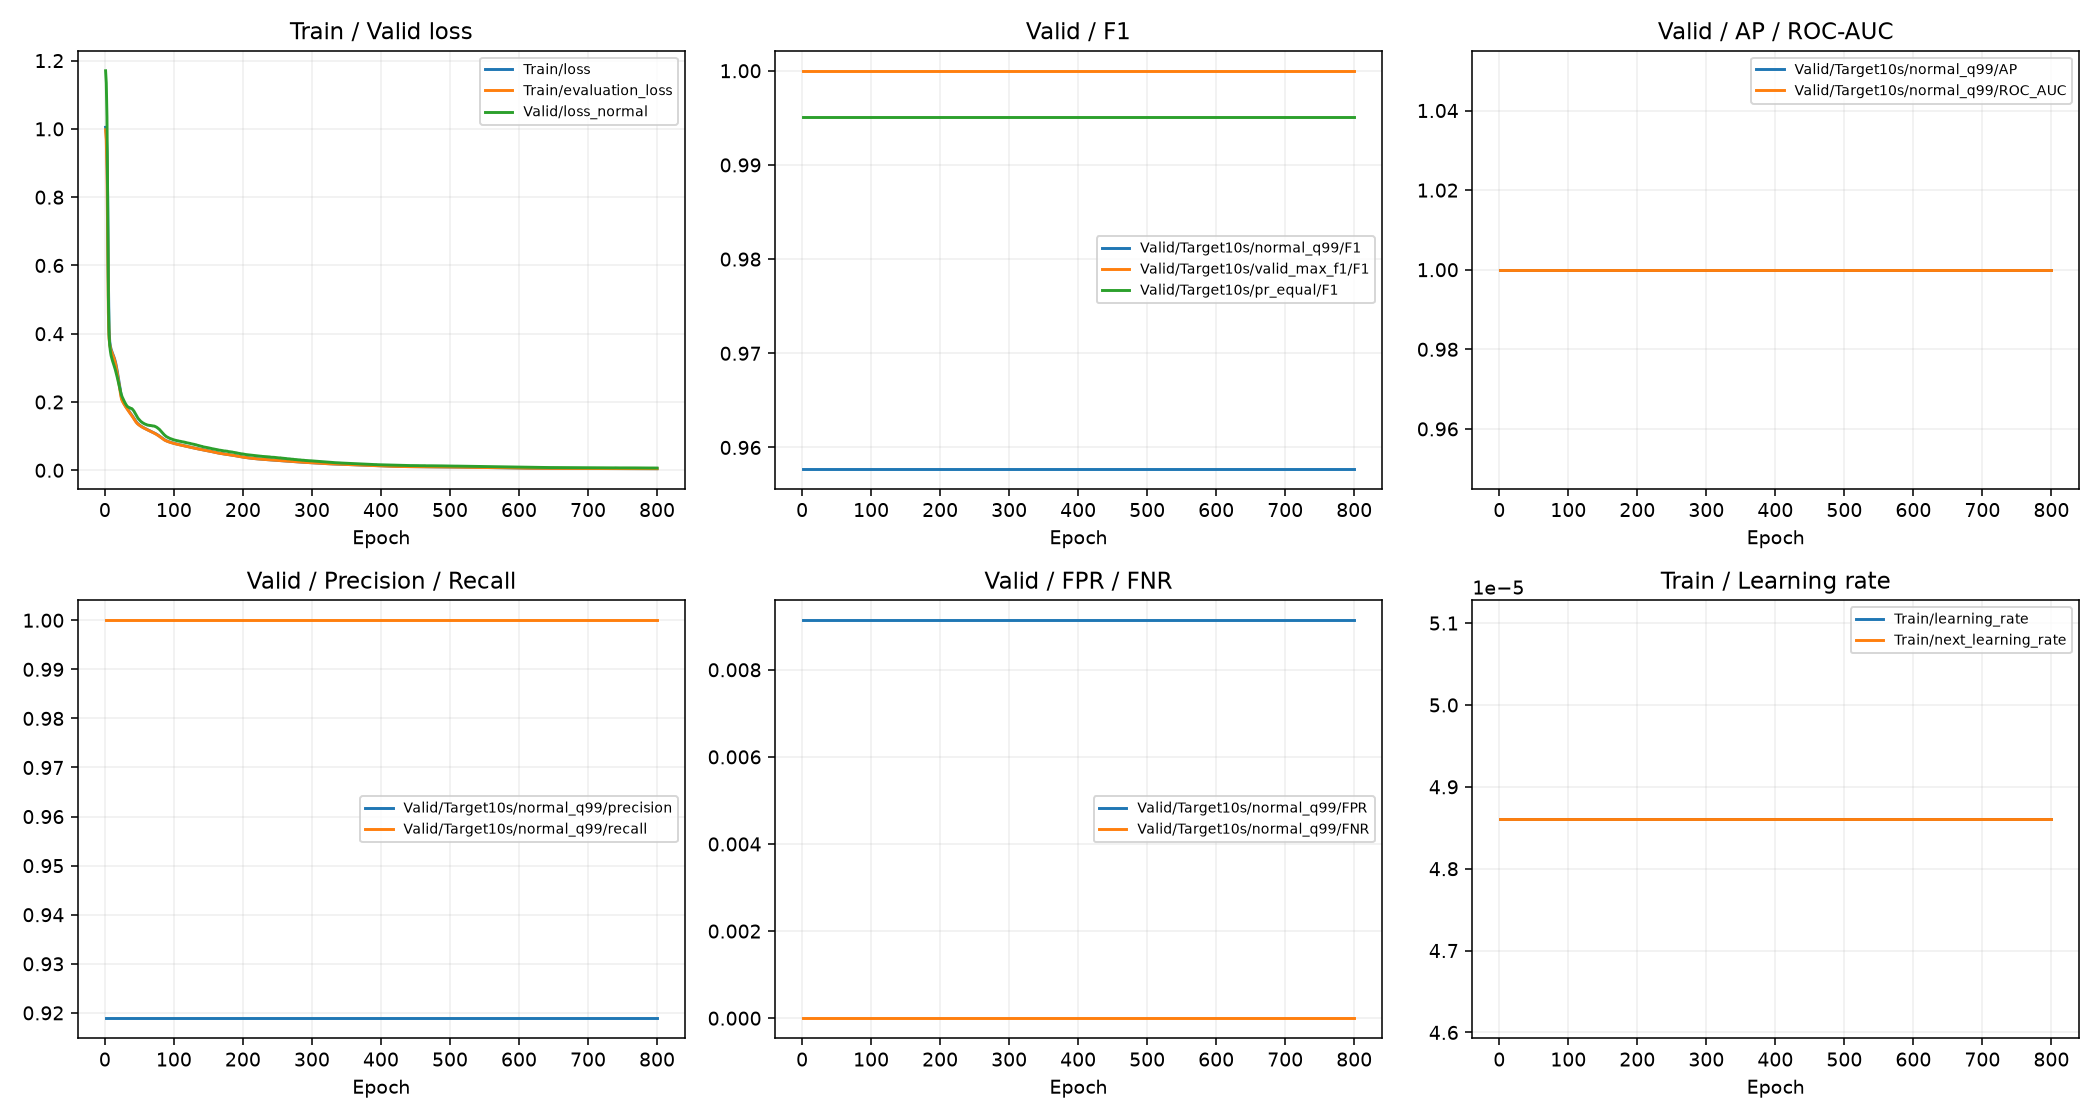

epoch 1: loss=1.00463, valid_normal=1.17025, AP=1.0000
epoch 2: loss=0.98518, valid_normal=1.1344, AP=1.0000
epoch 3: loss=0.932855, valid_normal=1.03444, AP=1.0000
epoch 4: loss=0.798267, valid_normal=0.79933, AP=1.0000
epoch 5: loss=0.569918, valid_normal=0.511838, AP=1.0000
epoch 6: loss=0.414627, valid_normal=0.396972, AP=1.0000
epoch 7: loss=0.37677, valid_normal=0.365226, AP=1.0000
epoch 8: loss=0.363163, valid_normal=0.348143, AP=1.0000
epoch 9: loss=0.354591, valid_normal=0.335847, AP=1.0000
epoch 10: loss=0.348181, valid_normal=0.327997, AP=1.0000
epoch 11: loss=0.342742, valid_normal=0.320873, AP=1.0000
epoch 12: loss=0.337561, valid_normal=0.315066, AP=1.0000
epoch 13: loss=0.332181, valid_normal=0.308448, AP=1.0000
epoch 14: loss=0.326197, valid_normal=0.30245, AP=1.0000
epoch 15: loss=0.319136, valid_normal=0.295439, AP=1.0000
epoch 16: loss=0.310674, valid_normal=0.287893, AP=1.0000
epoch 17: loss=0.300702, valid_normal=0.279771, AP=1.0000
epoch 18: loss=0.289388, valid_n

wandb: ERROR The nbformat package was not found. It is required to save notebook history.


Selection/best_normal_loss/AP,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
Selection/best_normal_loss/epoch,▁▁▁▁▁▁▂▂▂▂▂▂▂▃▃▃▄▄▄▄▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇████
Timing/extra_train_evaluation_seconds,▁▃▅▅▅▃▄▄▂▄▃▅▃▃▃▅▄▄▅▄▃▃▅▃▅▅▆▄█▅▃▅▅▆▅█▃▆▄▄
Timing/save_seconds_before_checkpoint,▅▃▅▁▄▄▄▆▆▆▄▅▄▆▃▄▄▂▅▃▃▃▅▃▃▃▂▄▄▃▃▅▃▃▁▃▃▅█▃
Timing/train_seconds,▃▅▁▂▃▅█▇▂▄▄▇▇▅▇▇▆▅▅▇▄▄▄▅▆▃█▇▆▆▆▇▃▃▆▃█▆▆▃
Timing/valid_seconds,▄▃▃▃▂▂▅▇█▅▆▆▄▅▃▄▅▄▆▃▄▆▆▅▅▄▇▆▁▃▂█▅▆▅▅▄▄▆▅
Train/evaluation_loss,█▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
Train/learning_rate,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
Train/loss,█▇▆▅▅▄▄▄▃▃▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
Train/next_learning_rate,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
+107,...


,number,value,datetime_start,datetime_complete,duration,params_dropout,params_lr,user_attrs_F1,user_attrs_run_relative,user_attrs_selected_epoch,system_attrs_completed_rung_0,system_attrs_completed_rung_1,system_attrs_fixed_params,state
0,0,1.0,2026-10-06 00:23:19.177262,2026-10-06 00:46:56.710872,0 days 00:23:37.533610,0.0,0.001000,0.957746,tuning/08_sensor_encoder_mlp_fft_p2p_rms/raw-n...,794,NaN,NaN,"{'lr': 0.001, 'dropout': 0.0}",COMPLETE
1,1,1.0,2026-10-06 00:46:56.771325,2026-10-06 01:07:59.805264,0 days 00:21:03.033939,0.0,0.000056,0.957746,tuning/08_sensor_encoder_mlp_fft_p2p_rms/raw-n...,793,1.0,1.0,NaN,COMPLETE
2,2,1.0,2026-10-06 01:07:59.901297,2026-10-06 01:30:05.170056,0 days 00:22:05.268759,0.2,0.000021,0.957746,tuning/08_sensor_encoder_mlp_fft_p2p_rms/raw-n...,800,1.0,1.0,NaN,COMPLETE
3,3,1.0,2026-10-06 01:30:05.242483,2026-10-06 01:51:17.844289,0 days 00:21:12.601806,0.2,0.000159,0.957746,tuning/08_sensor_encoder_mlp_fft_p2p_rms/raw-n...,800,1.0,1.0,NaN,COMPLETE
4,4,1.0,2026-10-06 01:51:17.901408,2026-10-06 02:12:31.952243,0 days 00:21:14.050835,0.0,0.000910,0.957746,tuning/08_sensor_encoder_mlp_fft_p2p_rms/raw-n...,794,1.0,1.0,NaN,COMPLETE
5,5,1.0,2026-10-06 02:12:32.035039,2026-10-06 02:33:44.623657,0 days 00:21:12.588618,0.1,0.000869,0.957746,tuning/08_sensor_encoder_mlp_fft_p2p_rms/raw-n...,740,1.0,1.0,NaN,COMPLETE
6,6,1.0,2026-10-06 02:33:44.717586,2026-10-06 02:55:11.310168,0 days 00:21:26.592582,0.0,0.000224,0.957746,tuning/08_sensor_encoder_mlp_fft_p2p_rms/raw-n...,797,1.0,1.0,NaN,COMPLETE
7,7,1.0,2026-10-06 02:55:11.384429,2026-10-06 03:17:03.748383,0 days 00:21:52.363954,0.1,0.000011,0.957746,tuning/08_sensor_encoder_mlp_fft_p2p_rms/raw-n...,800,1.0,1.0,NaN,COMPLETE
8,8,1.0,2026-10-06 03:17:03.819993,2026-10-06 03:38:29.601726,0 days 00:21:25.781733,0.0,0.000369,0.957746,tuning/08_sensor_encoder_mlp_fft_p2p_rms/raw-n...,788,1.0,1.0,NaN,COMPLETE
9,9,1.0,2026-10-06 03:38:29.683575,2026-10-06 04:00:45.072575,0 days 00:22:15.389000,0.0,0.000049,0.957746,tuning/08_sensor_encoder_mlp_fft_p2p_rms/raw-n...,795,1.0,1.0,NaN,COMPLETE


wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: WARNING [wandb.login()] Changing session credentials to explicit value for https://api.wandb.ai.
wandb: Appending key for api.wandb.ai to your netrc file: [LOCAL_PATH_REDACTED]


wandb: WARNING Artifact "run-a2b4dc145c74d712cd2608f4-TablesDatalabel_timing-QvF9Eg" already exists with the same content. No new version will be created.
wandb: ERROR The nbformat package was not found. It is required to save notebook history.


Execution/last_operation_status,completed
Execution/test_evaluated,False
Execution/training_status,max_epochs
Reporting/kind,hpo_candidate
Reporting/version,readable_storage_v2
Selection/best_ap/epoch,1
Selection/best_ap/filename,best_ap_epoch_0001.p...
Selection/best_f1_normal_q99/F1,0.95775
Selection/best_f1_normal_q99/epoch,1
Selection/best_f1_normal_q99/filename,best_f1_normal_q99_e...
+240,...


HPO 보관 정리 완료: 최종 후보 0 의 가중치와 전체 epoch Valid 점수를 유지했습니다.


In [19]:
# 선택 HPO: 기본 후보 포함 총 10후보, Test 미사용.
import optuna, sqlite3
RUN_HPO = True       # 기본: 이 HPO 노트북 실행 시 탐색 수행
STUDY_NAME=SPEC['id']+'_seed42'
BASELINE_RUN=None
HPO_BUDGET=10

def run_hpo(data):
    work=hpo_study_path(Path.cwd()/'experiment_work' if DATA_MODE=='drive' else OUTPUT_ROOT,SPEC,STUDY_NAME)
    work.mkdir(parents=True,exist_ok=True)
    signature=digest({'spec':SPEC,'train':TRAIN_CONFIG,'seed':SEED,'code':CODE_HASH,'data':data['source_hashes'],'split':data['split_hash'],'environment':ENVIRONMENT})
    cfg=work/'study_config.json'
    if cfg.exists() and json.loads(cfg.read_text())['signature'] not in {digest({'spec':SPEC,'train':TRAIN_CONFIG,'seed':SEED,'code':h,'data':data['source_hashes'],'split':data['split_hash'],'environment':ENVIRONMENT}) for h in [CODE_HASH]+STORAGE_COMPATIBLE_CODE_HASHES}: raise ValueError('study 설정/환경 변경: 새 study 이름을 사용하세요.')
    save_json(cfg,{'signature':signature,'budget':HPO_BUDGET,'environment':ENVIRONMENT})
    lock=work/'.writer.lock';fd=os.open(str(lock),os.O_CREAT|os.O_EXCL|os.O_WRONLY);os.close(fd)
    try:
        sampler=joblib.load(work/'sampler.joblib') if (work/'sampler.joblib').exists() else optuna.samplers.TPESampler(seed=42,n_startup_trials=4)
        pruner=optuna.pruners.SuccessiveHalvingPruner(min_resource=200,reduction_factor=2,min_early_stopping_rate=0,bootstrap_count=0)
        study=optuna.create_study(study_name=STUDY_NAME,storage='sqlite:///'+str(work/'study.sqlite'),
            sampler=sampler,pruner=pruner,direction='maximize',load_if_exists=True)
        distributions={'lr':optuna.distributions.FloatDistribution(1e-5,1e-3,log=True),
                       'dropout':optuna.distributions.CategoricalDistribution([0.,.1,.2])}
        def snapshot(run=None,epoch=None):
            if run is not None:
                # 중단/가지치기 후보도 저장 이력을 찾아 분석할 수 있게 경로를 기록합니다.
                active.set_user_attr('run_relative',Path(run).relative_to(work.parent.parent.parent).as_posix())
                save_json(work/'active.json',{'trial_number':active.number,
                    'run_relative':str(Path(run).relative_to(work.parent.parent.parent)).replace('\\','/'),'epoch':epoch})
            study.trials_dataframe().to_csv(work/'trials.csv',index=False)
            joblib.dump(study.sampler,work/'sampler.joblib')
            with sqlite3.connect(str(work/'study.sqlite')) as src,sqlite3.connect(str(work/'study_snapshot.sqlite')) as dst: src.backup(dst)
            if DATA_MODE=='drive':
                dest=OUTPUT_ROOT/work.relative_to(Path.cwd()/'experiment_work');dest.mkdir(parents=True,exist_ok=True)
                for p in work.iterdir():
                    if p.is_file() and p.name not in ('study.sqlite','.writer.lock'): shutil.copy2(p,dest/p.name)
        if not study.trials:
            if BASELINE_RUN:
                base=Path(BASELINE_RUN);cfg0=json.loads((result_path(base,'config.json')).read_text(encoding='utf-8'))
                selected=json.loads((result_path(base,'selection.json')).read_text(encoding='utf-8'))
                checks={'campaign':CAMP,'spec':SPEC,'train':TRAIN_CONFIG,'seed':SEED,'code_hash':CODE_HASH,
                        'source_hashes':data['source_hashes'],'split_hash':data['split_hash'],'environment':ENVIRONMENT}
                # HPO는 Optuna만 추가로 필요하므로 기본 후보의 비 Optuna 환경을 비교합니다.
                oldenv=cfg0.get('environment',{});newenv=dict(ENVIRONMENT)
                newenv['packages']={k:v for k,v in newenv['packages'].items() if k!='optuna'}
                checks['environment']=newenv
                if any(cfg0.get(k)!=v for k,v in checks.items() if k!='code_hash') or cfg0.get('code_hash') not in [CODE_HASH]+STORAGE_COMPATIBLE_CODE_HASHES: raise ValueError('기본 실행 등록 조건이 다릅니다.')
                hist=pd.read_csv(result_path(base,'history.csv'))
                if not all((result_path(base,'valid_scores')/f'epoch_{e:04d}.npz').exists() for e in hist.epoch): raise ValueError('기본 실행 점수 누락')
                shutil.copytree(base,work/'baseline',dirs_exist_ok=False)
                study.add_trial(optuna.trial.create_trial(state=optuna.trial.TrialState.COMPLETE,
                    value=selected['AP'],params={k:TRAIN_CONFIG[k] for k in distributions},distributions=distributions,
                    intermediate_values={int(r.epoch):float(r.selected_AP) for r in hist.itertuples()},
                    user_attrs={'run_in_study':'baseline','F1':selected['F1'],'origin':'campaign_baseline'}))
            else: study.enqueue_trial({k:TRAIN_CONFIG[k] for k in distributions})
        snapshot()
        while True:
            running=[t for t in study.trials if t.state==optuna.trial.TrialState.RUNNING]
            if len(running)>1: raise RuntimeError('동시에 여러 RUNNING 후보가 있습니다.')
            if running:
                active=optuna.trial.Trial(study,running[0]._trial_id)
                saved=json.loads((work/'active.json').read_text()) if (work/'active.json').exists() else None
                if saved and saved['trial_number']!=active.number: raise ValueError('trial/backup 상태 불일치')
                resume=(work.parent.parent.parent/saved['run_relative']) if saved and saved['run_relative'] else None
            else:
                pending=any(t.state==optuna.trial.TrialState.WAITING for t in study.trials)
                if len(study.trials)>=HPO_BUDGET and not pending: break
                active=study.ask();resume=None
                save_json(work/'active.json',{'trial_number':active.number,'run_relative':None,'epoch':0})
            params={**TRAIN_CONFIG,'lr':active.suggest_float('lr',1e-5,1e-3,log=True),
                    'dropout':active.suggest_categorical('dropout',[0.,.1,.2])}
            snapshot()
            if resume and (result_path(resume,'selection.json')).exists():
                selected=json.loads((result_path(resume,'selection.json')).read_text(encoding='utf-8'))
                if selected['stop_reason']=='pruned': study.tell(active,state=optuna.trial.TrialState.PRUNED)
                else:
                    active.set_user_attr('F1',selected['F1'])
                    active.set_user_attr('run_relative',str(resume.relative_to(work.parent.parent.parent)).replace('\\','/'))
                    study.tell(active,selected['AP'])
            else:
                try:
                    run,selected=run_training(data,SPEC,params,resume=resume,trial=active,run_kind='hpo_trials',on_epoch=snapshot)
                    active.set_user_attr('F1',selected['F1'])
                    active.set_user_attr('run_relative',str(run.relative_to(work.parent.parent.parent)).replace('\\','/'))
                    study.tell(active,selected['AP'])
                except optuna.TrialPruned: study.tell(active,state=optuna.trial.TrialState.PRUNED)
                except (FloatingPointError,MemoryError):
                    study.tell(active,state=optuna.trial.TrialState.FAIL);snapshot();raise
            snapshot()
        completed=[t for t in study.trials if t.state==optuna.trial.TrialState.COMPLETE]
        if not completed: raise RuntimeError('정상 완료 후보가 없습니다.')
        chosen=sorted(completed,key=lambda t:(-t.value,-t.user_attrs.get('F1',0),t.number))[0]
        save_json(work/'hpo_selection.json',{'trial':chosen.number,'AP':chosen.value,'params':chosen.params,
            'study':STUDY_NAME,'experiment_id':SPEC['id'],'config_origin':'hpo','user_attrs':chosen.user_attrs})
        study.trials_dataframe().to_csv(work/'trials.csv',index=False);snapshot()
        display(study.trials_dataframe())
        finalize_hpo_retention(work,study,chosen)
        return work
    finally: lock.unlink(missing_ok=True)

if RUN_HPO: HPO_DIR=run_hpo(DATA)
else: print('선택 HPO 미실행. 기본 8종 완료 후 RUN_HPO=True로 실행하세요.')


## 실행 — HPO에서 선정된 모델의 Test

`HPO_DIR`의 선정 기록으로 후보 실행과 학습 설정을 찾습니다. `FREEZE_SELECTION`으로 선정 결과를 기록하고 `RUN_TEST=True`일 때 해당 가중치를 Test에 적용합니다.

후보를 다시 학습하거나 Test 성능으로 후보를 바꾸지 않습니다. 후보별 비교는 Valid 자료를 사용하고 최종 Test는 선택 후의 평가로 해석합니다.


In [20]:
# 선택한 HPO checkpoint의 Test 평가. 재학습하지 않습니다.
FREEZE_SELECTION = True  # Valid 선택 결과를 기록한 뒤 Test 평가
if RUN_TEST or (FREEZE_SELECTION and RUN_HPO):
    if 'HPO_DIR' not in globals(): raise ValueError('이번 캠페인의 HPO_DIR을 지정하세요.')
    selected_hpo=json.loads((Path(HPO_DIR)/'hpo_selection.json').read_text(encoding='utf-8'))
    attrs=selected_hpo['user_attrs']
    if 'run_in_study' in attrs: RUN_DIR=Path(HPO_DIR)/attrs['run_in_study']
    else: RUN_DIR=Path(HPO_DIR).parent.parent.parent/attrs['run_relative']
    frozen=json.loads((result_path(RUN_DIR,'config.json')).read_text(encoding='utf-8'))['train']
    selected=json.loads((result_path(RUN_DIR,'selection.json')).read_text(encoding='utf-8'))
    if FREEZE_SELECTION:
        save_json(result_path(RUN_DIR,'test_release.json'),{'selection_hash':digest(selected),'hpo_selection_hash':digest(selected_hpo),
            'frozen_utc':datetime.now(timezone.utc).isoformat()})
    if RUN_TEST: display(pd.DataFrame(evaluate_test(DATA,RUN_DIR,SPEC,frozen)).T)


wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: WARNING [wandb.login()] Changing session credentials to explicit value for https://api.wandb.ai.
wandb: Appending key for api.wandb.ai to your netrc file: [LOCAL_PATH_REDACTED]


wandb: WARNING Artifact "weights-08_sensor_encoder_mlp_fft_p2p_rms-a2b4dc145c74d712cd2608f4" already exists with the same content. No new version will be created.
wandb: WARNING Artifact "run-a2b4dc145c74d712cd2608f4-TablesValidcheckpoint_comparisonsbest_normal_lossnormal_q99_error_sensors-BquspA" already exists with the same content. No new version will be created.
wandb: ERROR The nbformat package was not found. It is required to save notebook history.


Execution/last_operation_status,test
Execution/test_evaluated,True
Execution/training_status,max_epochs
Reporting/kind,hpo_candidate
Reporting/version,readable_storage_v2
Selection/best_ap/epoch,1
Selection/best_ap/filename,best_ap_epoch_0001.p...
Selection/best_f1_normal_q99/F1,0.95775
Selection/best_f1_normal_q99/epoch,1
Selection/best_f1_normal_q99/filename,best_f1_normal_q99_e...
+308,...


,n,normal,anomaly,AP,ROC_AUC,TN,FP,FN,TP,accuracy,precision,recall,F1,FPR,FNR,balanced_accuracy,all_normal_accuracy,status
label_10s__normal_q99,2162,1988,174,1.0,1.0,1982,6,0,174,0.997225,0.966667,1.0,0.983051,0.003018,0.0,0.998491,0.919519,computed
label_10s__valid_max_f1,2162,1988,174,1.0,1.0,1988,0,18,156,0.991674,1.0,0.896552,0.945455,0.0,0.103448,0.948276,0.919519,computed
label_current__normal_q99,2162,1988,174,1.0,1.0,1982,6,0,174,0.997225,0.966667,1.0,0.983051,0.003018,0.0,0.998491,0.919519,computed
label_current__valid_max_f1,2162,1988,174,1.0,1.0,1988,0,18,156,0.991674,1.0,0.896552,0.945455,0.0,0.103448,0.948276,0.919519,computed


## 결과 표와 그래프
학습 곡선, 선택 결과, Train·Valid·Test 지표, 혼동행렬, 센서별 오차 및 복원 예시를 표시합니다. 전체 수치는 실행 폴더에 저장합니다. 이 셀은 재학습하지 않습니다.

### 코드 설명

`RESULT_RUN=None`이면 이번 커널의 `RUN_DIR`을 읽습니다. 다른 완료 결과를 보려면 `RESULT_RUN`에 해당 실행 폴더를 지정합니다. 필요한 라이브러리·함수 정의 셀을 먼저 실행하세요.

저장된 선택 결과, 이력, 분할별 지표, 오류 표와 그림을 표시하며 재학습하지 않습니다. 표시되지 않는 항목은 해당 파일의 저장 여부를 확인하세요. 실행 후 노트북을 저장해야 표·이미지 출력이 ipynb에도 남습니다.


,number,value,datetime_start,datetime_complete,duration,params_dropout,params_lr,user_attrs_F1,user_attrs_run_relative,user_attrs_selected_epoch,system_attrs_completed_rung_0,system_attrs_completed_rung_1,system_attrs_fixed_params,state
0,0,1.0,2026-10-06 00:23:19.177262,2026-10-06 00:46:56.710872,0 days 00:23:37.533610,0.0,0.001000,0.957746,tuning/08_sensor_encoder_mlp_fft_p2p_rms/raw-n...,794,NaN,NaN,"{'lr': 0.001, 'dropout': 0.0}",COMPLETE
1,1,1.0,2026-10-06 00:46:56.771325,2026-10-06 01:07:59.805264,0 days 00:21:03.033939,0.0,0.000056,0.957746,tuning/08_sensor_encoder_mlp_fft_p2p_rms/raw-n...,793,1.0,1.0,NaN,COMPLETE
2,2,1.0,2026-10-06 01:07:59.901297,2026-10-06 01:30:05.170056,0 days 00:22:05.268759,0.2,0.000021,0.957746,tuning/08_sensor_encoder_mlp_fft_p2p_rms/raw-n...,800,1.0,1.0,NaN,COMPLETE
3,3,1.0,2026-10-06 01:30:05.242483,2026-10-06 01:51:17.844289,0 days 00:21:12.601806,0.2,0.000159,0.957746,tuning/08_sensor_encoder_mlp_fft_p2p_rms/raw-n...,800,1.0,1.0,NaN,COMPLETE
4,4,1.0,2026-10-06 01:51:17.901408,2026-10-06 02:12:31.952243,0 days 00:21:14.050835,0.0,0.000910,0.957746,tuning/08_sensor_encoder_mlp_fft_p2p_rms/raw-n...,794,1.0,1.0,NaN,COMPLETE
5,5,1.0,2026-10-06 02:12:32.035039,2026-10-06 02:33:44.623657,0 days 00:21:12.588618,0.1,0.000869,0.957746,tuning/08_sensor_encoder_mlp_fft_p2p_rms/raw-n...,740,1.0,1.0,NaN,COMPLETE
6,6,1.0,2026-10-06 02:33:44.717586,2026-10-06 02:55:11.310168,0 days 00:21:26.592582,0.0,0.000224,0.957746,tuning/08_sensor_encoder_mlp_fft_p2p_rms/raw-n...,797,1.0,1.0,NaN,COMPLETE
7,7,1.0,2026-10-06 02:55:11.384429,2026-10-06 03:17:03.748383,0 days 00:21:52.363954,0.1,0.000011,0.957746,tuning/08_sensor_encoder_mlp_fft_p2p_rms/raw-n...,800,1.0,1.0,NaN,COMPLETE
8,8,1.0,2026-10-06 03:17:03.819993,2026-10-06 03:38:29.601726,0 days 00:21:25.781733,0.0,0.000369,0.957746,tuning/08_sensor_encoder_mlp_fft_p2p_rms/raw-n...,788,1.0,1.0,NaN,COMPLETE
9,9,1.0,2026-10-06 03:38:29.683575,2026-10-06 04:00:45.072575,0 days 00:22:15.389000,0.0,0.000049,0.957746,tuning/08_sensor_encoder_mlp_fft_p2p_rms/raw-n...,795,1.0,1.0,NaN,COMPLETE


실험: [H08 Trial 0000] MLP | Sensor Encoder | FFT+P2P+RMS | raw-none_features-standard | s42 | 20261005T152319224975Z_2d6d88
작업 폴더: [LOCAL_PATH_REDACTED]
최종 저장 폴더: [LOCAL_PATH_REDACTED]
W&B: online | Drive 백업: False


,filename,epoch,logical_name,primary,criterion,metric_value,checkpoint,metric,F1,policy,threshold,operator,coverage_start_epoch,scope,tie_rule,version
0,best_normal_loss_epoch_0794.pt,794,best_normal_loss.pt,True,normal_valid_loss_min,0.000598,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,best_ap_epoch_0001.pt,1,best_ap.pt,False,valid_AP_max,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,last_epoch_0800.pt,800,last.pt,False,resume_latest,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,best_f1_normal_q99_epoch_0001.pt,1,best_f1_normal_q99.pt,False,valid_F1_max,0.957746,best_f1_normal_q99.pt,label_10s__normal_q99__F1,0.957746,normal_q99,0.836709,>,1.0,best among epochs whose weights were available...,keep earliest saved epoch,valid_f1_checkpoints_v1
4,best_f1_valid_max_f1_epoch_0001.pt,1,best_f1_valid_max_f1.pt,False,valid_F1_max,1.000000,best_f1_valid_max_f1.pt,label_10s__valid_max_f1__F1,1.000000,valid_max_f1,74.745834,>=,1.0,best among epochs whose weights were available...,keep earliest saved epoch,valid_f1_checkpoints_v1


학습 상태: max_epochs | Test 평가: True


,checkpoint,epoch,stop_reason,AP,F1,parameter_count,test_allowed,policies.normal_q99.threshold,policies.normal_q99.operator,policies.valid_max_f1.threshold,policies.valid_max_f1.operator
0,best_normal_loss_epoch_0794.pt,794,max_epochs,1.0,0.957746,17348,False,0.003186,>,9.33507,>=


,checkpoint,epoch,split,policy,primary,weight_bytes,parameter_count,n,normal,anomaly,...,TP,accuracy,precision,recall,F1,FPR,FNR,balanced_accuracy,all_normal_accuracy,status
0,best_normal_loss_epoch_0794.pt,794,valid,normal_q99,True,77345,17348,1087,985,102,...,102,0.991720,0.918919,1.000000,0.957746,0.009137,0.000000,0.995431,0.906164,computed
1,best_normal_loss_epoch_0794.pt,794,valid,valid_max_f1,False,77345,17348,1087,985,102,...,102,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.906164,computed
2,best_normal_loss_epoch_0794.pt,794,valid,pr_equal,False,77345,17348,1087,985,102,...,101,0.999080,1.000000,0.990196,0.995074,0.000000,0.009804,0.995098,0.906164,computed
3,best_ap_epoch_0001.pt,1,valid,normal_q99,False,77345,17348,1087,985,102,...,102,0.991720,0.918919,1.000000,0.957746,0.009137,0.000000,0.995431,0.906164,computed
4,best_ap_epoch_0001.pt,1,valid,valid_max_f1,False,77345,17348,1087,985,102,...,102,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.906164,computed
5,best_ap_epoch_0001.pt,1,valid,pr_equal,False,77345,17348,1087,985,102,...,101,0.999080,1.000000,0.990196,0.995074,0.000000,0.009804,0.995098,0.906164,computed
6,last_epoch_0800.pt,800,valid,normal_q99,False,4536405,17348,1087,985,102,...,102,0.991720,0.918919,1.000000,0.957746,0.009137,0.000000,0.995431,0.906164,computed
7,last_epoch_0800.pt,800,valid,valid_max_f1,False,4536405,17348,1087,985,102,...,102,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.906164,computed
8,last_epoch_0800.pt,800,valid,pr_equal,False,4536405,17348,1087,985,102,...,101,0.999080,1.000000,0.990196,0.995074,0.000000,0.009804,0.995098,0.906164,computed
9,best_normal_loss_epoch_0794.pt,794,test,normal_q99,True,77345,17348,2162,1988,174,...,174,0.997225,0.966667,1.000000,0.983051,0.003018,0.000000,0.998491,0.919519,computed


,epoch,Train/loss,Valid/loss_normal,Train/learning_rate,Train/next_learning_rate,Timing/train_seconds,Timing/valid_seconds,Selection/best_normal_loss/epoch,Selection/best_normal_loss/AP,Valid/Target10s/normal_q99/n,...,Valid/CurrentLabel/pr_equal/FNR,Valid/CurrentLabel/pr_equal/balanced_accuracy,Valid/CurrentLabel/pr_equal/all_normal_accuracy,Valid/CurrentLabel/pr_equal/status,Valid/Threshold/normal_q99,Valid/Threshold/valid_max_f1,Valid/Threshold/pr_equal,Train/evaluation_loss,Timing/extra_train_evaluation_seconds,Timing/save_seconds_before_checkpoint
790,791,0.000233,0.000614,0.000343,0.000343,0.888198,0.049967,787,1.0,1087,...,0.009804,0.995098,0.906164,computed,0.003361,9.328766,9.328766,0.000237,0.229916,0.276567
791,792,0.000235,0.000647,0.000343,0.000343,0.742372,0.040147,787,1.0,1087,...,0.009804,0.995098,0.906164,computed,0.003704,9.340536,9.340536,0.000234,0.201771,0.251637
792,793,0.000234,0.000616,0.000343,0.000343,0.854534,0.039618,787,1.0,1087,...,0.009804,0.995098,0.906164,computed,0.003437,9.278587,9.278587,0.000228,0.180362,0.221809
793,794,0.000240,0.000598,0.000343,0.000343,0.796400,0.043266,794,1.0,1087,...,0.009804,0.995098,0.906164,computed,0.003186,9.335070,9.335070,0.000240,0.194619,0.286279
794,795,0.000250,0.000630,0.000343,0.000343,0.807709,0.051628,794,1.0,1087,...,0.009804,0.995098,0.906164,computed,0.003467,9.297031,9.297031,0.000245,0.217105,0.280006
795,796,0.000242,0.000656,0.000343,0.000343,0.796730,0.038478,794,1.0,1087,...,0.009804,0.995098,0.906164,computed,0.003685,9.412441,9.412441,0.000247,0.154242,0.202870
796,797,0.000242,0.000631,0.000343,0.000343,0.869848,0.054969,794,1.0,1087,...,0.009804,0.995098,0.906164,computed,0.003581,9.320512,9.320512,0.000233,0.195776,0.242527
797,798,0.000234,0.000625,0.000343,0.000343,0.774404,0.039740,794,1.0,1087,...,0.009804,0.995098,0.906164,computed,0.003486,9.305470,9.305470,0.000232,0.178564,0.220336
798,799,0.000235,0.000634,0.000343,0.000343,0.862686,0.041423,794,1.0,1087,...,0.009804,0.995098,0.906164,computed,0.003524,9.336046,9.336046,0.000238,0.198343,0.247869
799,800,0.000236,0.000605,0.000343,0.000343,0.833271,0.056869,794,1.0,1087,...,0.009804,0.995098,0.906164,computed,0.003399,9.281345,9.281345,0.000234,0.191546,0.240083


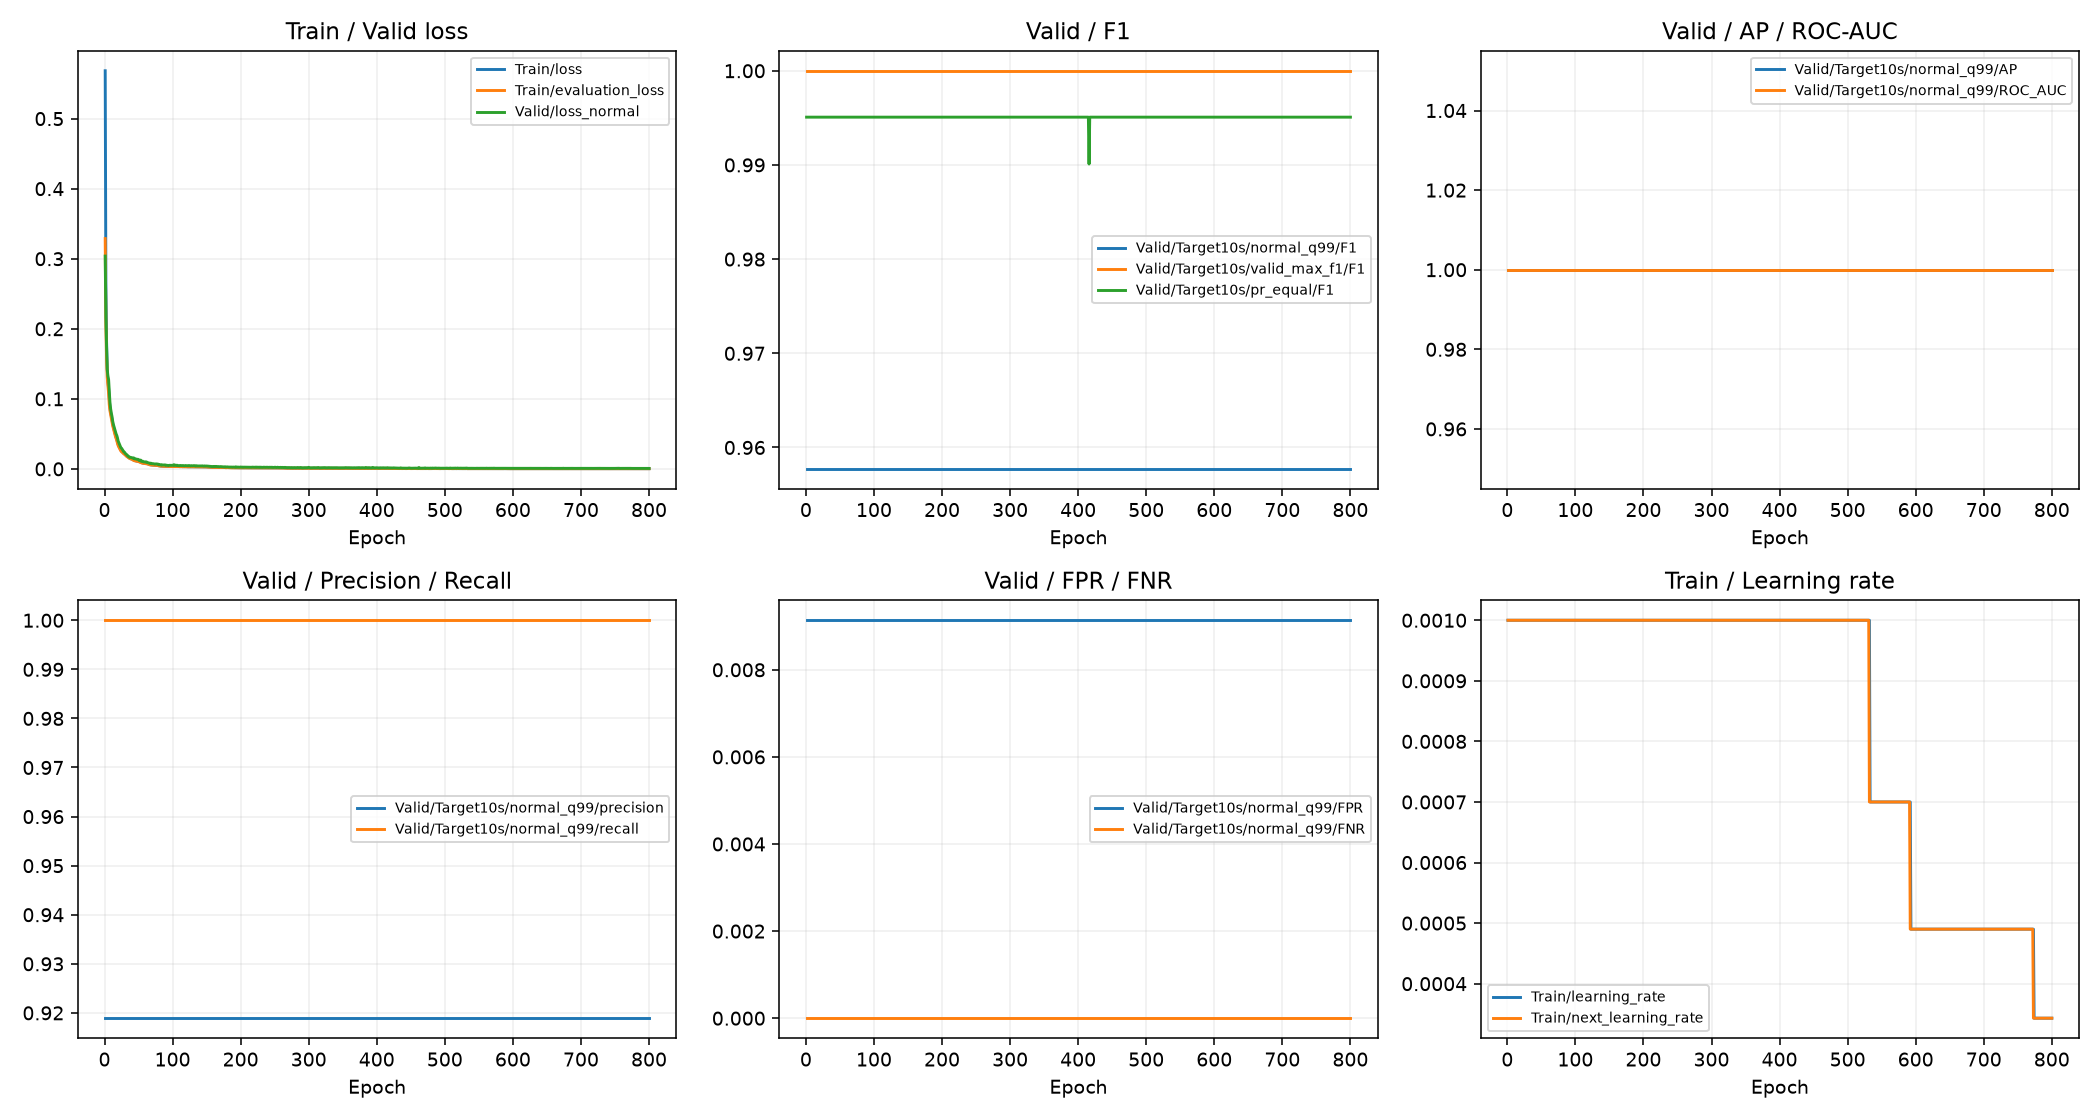

TRAIN


,n,normal,anomaly,AP,ROC_AUC,TN,FP,FN,TP,accuracy,precision,recall,F1,FPR,FNR,balanced_accuracy,all_normal_accuracy,status
label_10s__normal_q99,7005,7005,0,None,None,7003,2,0,0,0.999714,0.0,None,0.0,0.000286,None,None,1.0,computed
label_10s__valid_max_f1,7005,7005,0,None,None,7005,0,0,0,1.0,0.0,None,None,0.0,None,None,1.0,computed
label_current__normal_q99,7005,7005,0,None,None,7003,2,0,0,0.999714,0.0,None,0.0,0.000286,None,None,1.0,computed
label_current__valid_max_f1,7005,7005,0,None,None,7005,0,0,0,1.0,0.0,None,None,0.0,None,None,1.0,computed


,policy,label,segments,alarmed,alarm_fraction
0,normal_q99,0,316,1,0.003165
1,normal_q99,1,0,0,NaN
2,valid_max_f1,0,316,0,0.000000
3,valid_max_f1,1,0,0,NaN


,policy,grouping,group,n,normal,anomaly,AP,ROC_AUC,TN,FP,...,TP,accuracy,precision,recall,F1,FPR,FNR,balanced_accuracy,all_normal_accuracy,status
0,normal_q99,source+segment,"('normal', 1)",22,22,0,NaN,NaN,22,0,...,0,1.0,0.0,NaN,NaN,0.0,NaN,NaN,1.0,computed
1,normal_q99,source+segment,"('normal', 2)",18,18,0,NaN,NaN,18,0,...,0,1.0,0.0,NaN,NaN,0.0,NaN,NaN,1.0,computed
2,normal_q99,source+segment,"('normal', 3)",5,5,0,NaN,NaN,5,0,...,0,1.0,0.0,NaN,NaN,0.0,NaN,NaN,1.0,computed
3,normal_q99,source+segment,"('normal', 5)",31,31,0,NaN,NaN,31,0,...,0,1.0,0.0,NaN,NaN,0.0,NaN,NaN,1.0,computed
4,normal_q99,source+segment,"('normal', 6)",31,31,0,NaN,NaN,31,0,...,0,1.0,0.0,NaN,NaN,0.0,NaN,NaN,1.0,computed
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
633,valid_max_f1,source+segment,"('normal', 421)",4,4,0,NaN,NaN,4,0,...,0,1.0,0.0,NaN,NaN,0.0,NaN,NaN,1.0,computed
634,valid_max_f1,source+segment,"('normal', 423)",31,31,0,NaN,NaN,31,0,...,0,1.0,0.0,NaN,NaN,0.0,NaN,NaN,1.0,computed
635,valid_max_f1,operating_state,"('active',)",4738,4738,0,NaN,NaN,4738,0,...,0,1.0,0.0,NaN,NaN,0.0,NaN,NaN,1.0,computed
636,valid_max_f1,operating_state,"('low_load',)",2267,2267,0,NaN,NaN,2267,0,...,0,1.0,0.0,NaN,NaN,0.0,NaN,NaN,1.0,computed


,label,sensor,mean_score
0,0,current,0.000061
1,0,vibration,0.000419


FP/FN rows: 2 (showing first 20; full table saved)


,window_id,source,segment,split,input_start_row,input_end_row,input_start_time,input_end_time,target_time,label_time,...,error_vibration_freq_last,error_vibration_freq_full,error_vibration_p2p_last,error_vibration_p2p_full,error_vibration_rms_last,error_vibration_rms_full,normal_q99_prediction,normal_q99_error,error_type,largest_reconstruction_error_sensor
0,normal:104:3869:3888,normal,104,train,3869,3888,2022-07-12 00:13:00.289,2022-07-12 00:13:02.189,2022-07-12 00:13:12.189,2022-07-12 00:13:11.271,...,0.019532,0.019532,0.000085,0.000085,0.001454,0.001454,1,FP,FP,vibration
1,normal:104:3870:3889,normal,104,train,3870,3889,2022-07-12 00:13:00.389,2022-07-12 00:13:02.289,2022-07-12 00:13:12.289,2022-07-12 00:13:11.271,...,0.019473,0.019473,0.000145,0.000145,0.001148,0.001148,1,FP,FP,vibration


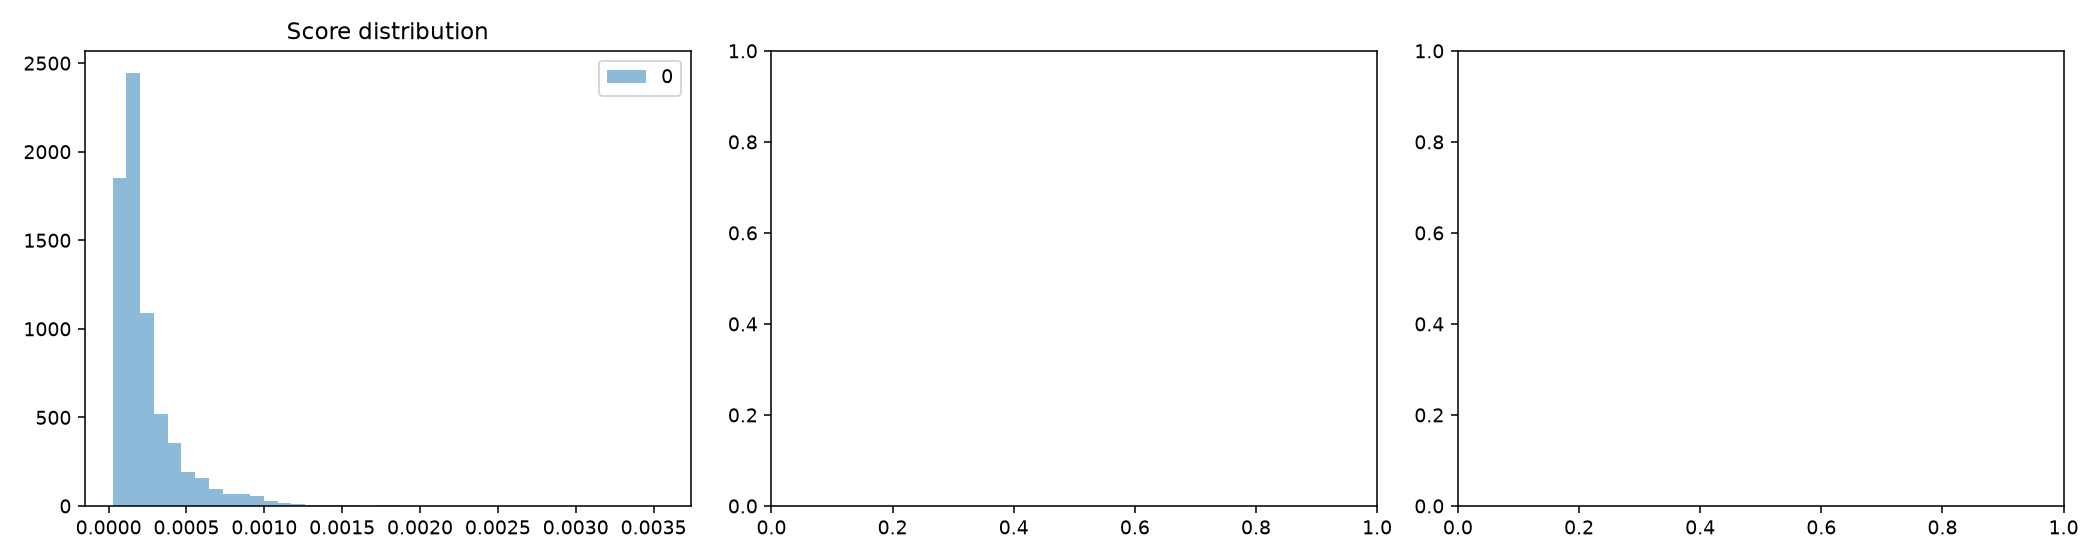

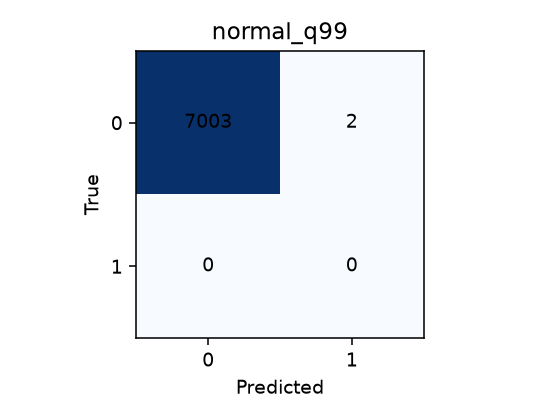

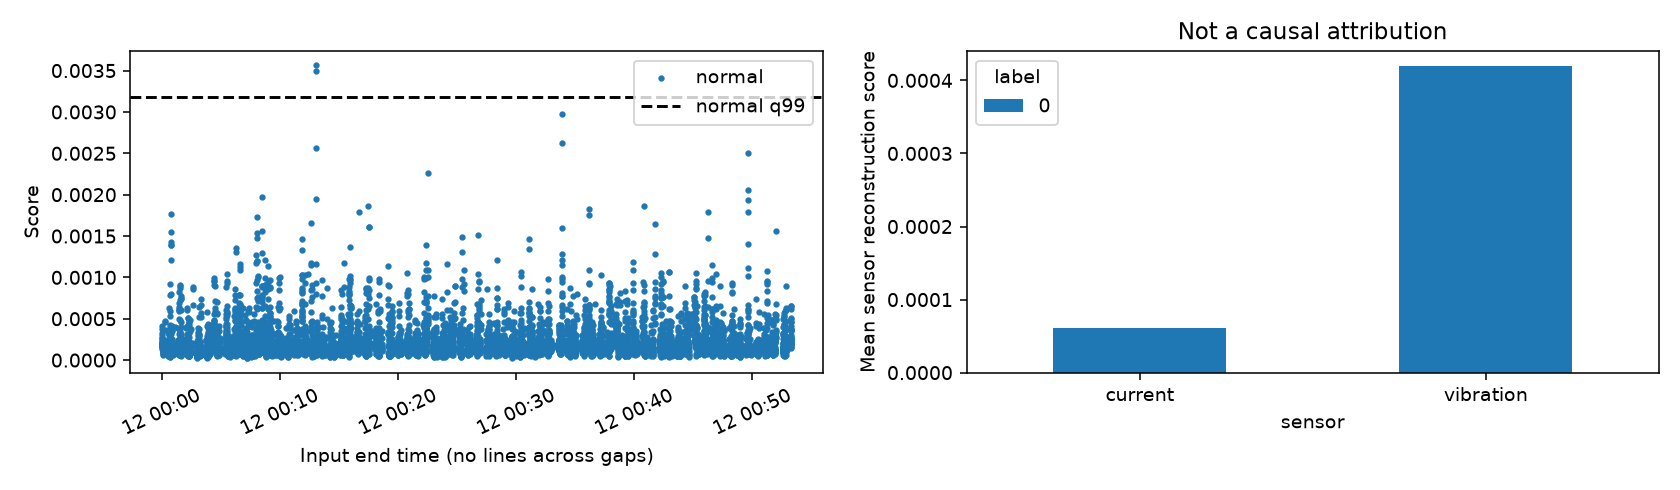

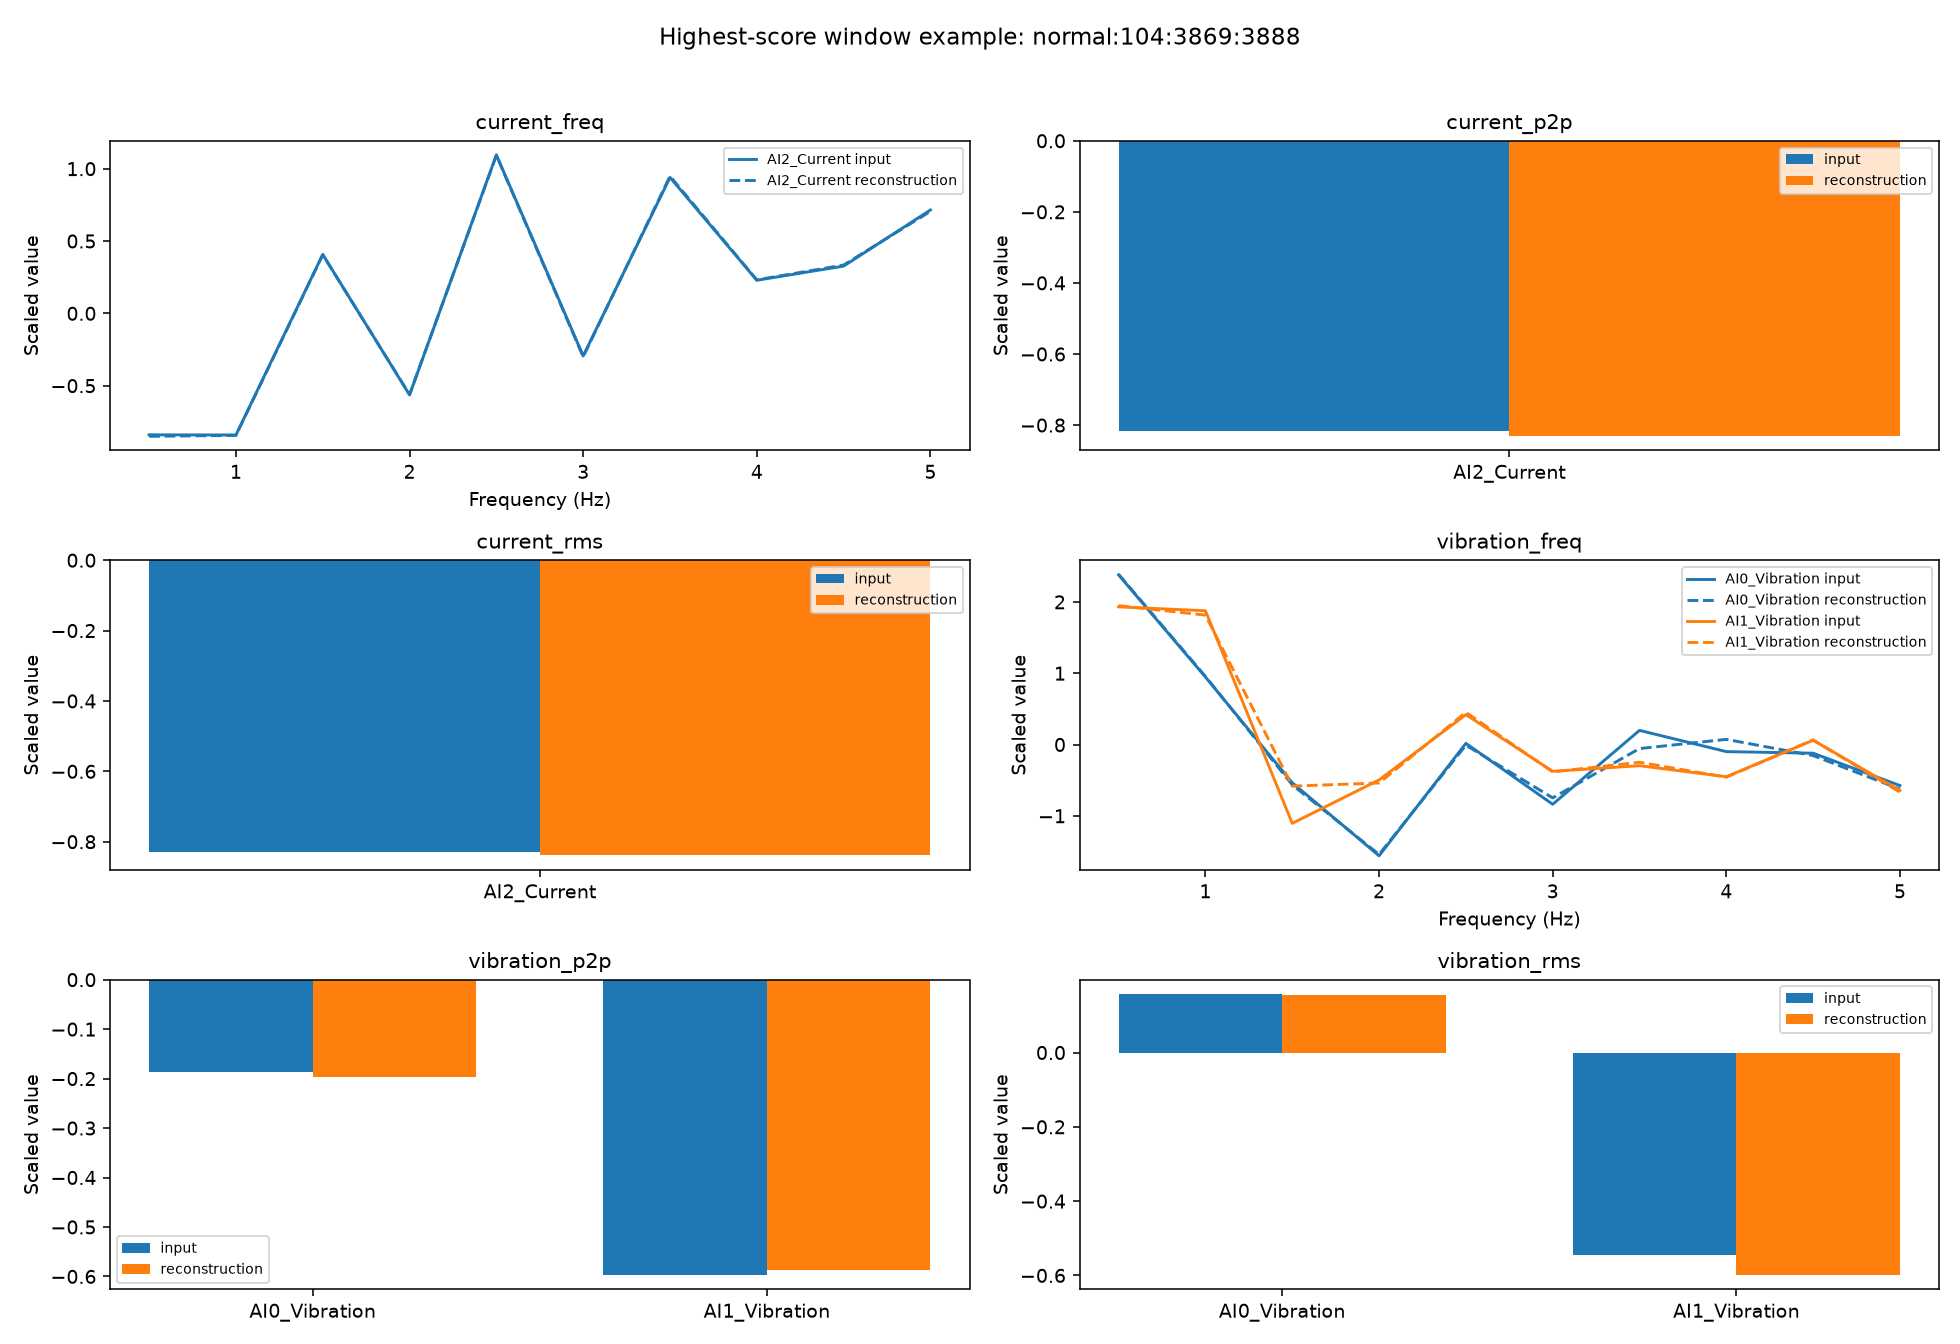

VALID


,n,normal,anomaly,AP,ROC_AUC,TN,FP,FN,TP,accuracy,precision,recall,F1,FPR,FNR,balanced_accuracy,all_normal_accuracy,status
label_10s__normal_q99,1087,985,102,1.0,1.0,976,9,0,102,0.99172,0.918919,1.0,0.957746,0.009137,0.0,0.995431,0.906164,computed
label_10s__valid_max_f1,1087,985,102,1.0,1.0,985,0,0,102,1.0,1.0,1.0,1.0,0.0,0.0,1.0,0.906164,computed
label_current__normal_q99,1087,985,102,1.0,1.0,976,9,0,102,0.99172,0.918919,1.0,0.957746,0.009137,0.0,0.995431,0.906164,computed
label_current__valid_max_f1,1087,985,102,1.0,1.0,985,0,0,102,1.0,1.0,1.0,1.0,0.0,0.0,1.0,0.906164,computed


,policy,label,segments,alarmed,alarm_fraction
0,normal_q99,0,46,3,0.065217
1,normal_q99,1,4,4,1.000000
2,valid_max_f1,0,46,0,0.000000
3,valid_max_f1,1,4,4,1.000000


,policy,grouping,group,n,normal,anomaly,AP,ROC_AUC,TN,FP,...,TP,accuracy,precision,recall,F1,FPR,FNR,balanced_accuracy,all_normal_accuracy,status
0,normal_q99,source+segment,"('normal', 424)",30,30,0,NaN,NaN,30,0,...,0,1.0,0.0,NaN,NaN,0.0,NaN,NaN,1.000000,computed
1,normal_q99,source+segment,"('normal', 425)",17,17,0,NaN,NaN,17,0,...,0,1.0,0.0,NaN,NaN,0.0,NaN,NaN,1.000000,computed
2,normal_q99,source+segment,"('normal', 426)",5,5,0,NaN,NaN,5,0,...,0,1.0,0.0,NaN,NaN,0.0,NaN,NaN,1.000000,computed
3,normal_q99,source+segment,"('normal', 428)",31,31,0,NaN,NaN,31,0,...,0,1.0,0.0,NaN,NaN,0.0,NaN,NaN,1.000000,computed
4,normal_q99,source+segment,"('normal', 429)",31,31,0,NaN,NaN,31,0,...,0,1.0,0.0,NaN,NaN,0.0,NaN,NaN,1.000000,computed
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
101,valid_max_f1,source+segment,"('anomaly', 4)",12,0,12,NaN,NaN,0,0,...,12,1.0,1.0,1.0,1.0,NaN,0.0,NaN,0.000000,computed
102,valid_max_f1,source+segment,"('anomaly', 7)",31,0,31,NaN,NaN,0,0,...,31,1.0,1.0,1.0,1.0,NaN,0.0,NaN,0.000000,computed
103,valid_max_f1,operating_state,"('active',)",604,525,79,1.0,1.0,525,0,...,79,1.0,1.0,1.0,1.0,0.0,0.0,1.0,0.869205,computed
104,valid_max_f1,operating_state,"('low_load',)",483,460,23,1.0,1.0,460,0,...,23,1.0,1.0,1.0,1.0,0.0,0.0,1.0,0.952381,computed


,label,sensor,mean_score
0,0,current,0.000483
1,0,vibration,0.000714
2,1,current,210.672897
3,1,vibration,43.637032


FP/FN rows: 9 (showing first 20; full table saved)


,window_id,source,segment,split,input_start_row,input_end_row,input_start_time,input_end_time,target_time,label_time,...,error_vibration_freq_last,error_vibration_freq_full,error_vibration_p2p_last,error_vibration_p2p_full,error_vibration_rms_last,error_vibration_rms_full,normal_q99_prediction,normal_q99_error,error_type,largest_reconstruction_error_sensor
0,normal:473:15636:15655,normal,473,valid,15636,15655,2022-07-12 00:59:54.592,2022-07-12 00:59:56.492,2022-07-12 01:00:06.492,2022-07-12 01:00:05.560,...,0.006891,0.006891,0.001360,0.001360,0.000416,0.000416,1,FP,FP,current
1,normal:473:15644:15663,normal,473,valid,15644,15663,2022-07-12 00:59:55.392,2022-07-12 00:59:57.292,2022-07-12 01:00:07.292,2022-07-12 01:00:05.560,...,0.011829,0.011829,0.000508,0.000508,0.001320,0.001320,1,FP,FP,vibration
2,normal:473:15645:15664,normal,473,valid,15645,15664,2022-07-12 00:59:55.492,2022-07-12 00:59:57.392,2022-07-12 01:00:07.392,2022-07-12 01:00:05.560,...,0.015616,0.015616,0.000372,0.000372,0.001748,0.001748,1,FP,FP,vibration
3,normal:473:15646:15665,normal,473,valid,15646,15665,2022-07-12 00:59:55.592,2022-07-12 00:59:57.492,2022-07-12 01:00:07.492,2022-07-12 01:00:05.560,...,0.016201,0.016201,0.000456,0.000456,0.001419,0.001419,1,FP,FP,vibration
4,normal:473:15647:15666,normal,473,valid,15647,15666,2022-07-12 00:59:55.692,2022-07-12 00:59:57.592,2022-07-12 01:00:07.592,2022-07-12 01:00:05.560,...,0.016310,0.016310,0.000639,0.000639,0.001224,0.001224,1,FP,FP,vibration
5,normal:473:15648:15667,normal,473,valid,15648,15667,2022-07-12 00:59:55.792,2022-07-12 00:59:57.692,2022-07-12 01:00:07.692,2022-07-12 01:00:05.560,...,0.012423,0.012423,0.002384,0.002384,0.000765,0.000765,1,FP,FP,vibration
6,normal:474:15695:15714,normal,474,valid,15695,15714,2022-07-12 01:00:02.160,2022-07-12 01:00:04.060,2022-07-12 01:00:14.060,2022-07-12 01:00:12.165,...,0.007485,0.007485,0.000196,0.000196,0.000854,0.000854,1,FP,FP,current
7,normal:474:15696:15715,normal,474,valid,15696,15715,2022-07-12 01:00:02.260,2022-07-12 01:00:04.160,2022-07-12 01:00:14.160,2022-07-12 01:00:12.165,...,0.008612,0.008612,0.000194,0.000194,0.001090,0.001090,1,FP,FP,current
8,normal:475:15742:15761,normal,475,valid,15742,15761,2022-07-12 01:00:09.565,2022-07-12 01:00:11.465,2022-07-12 01:00:21.465,2022-07-12 01:00:18.992,...,0.008210,0.008210,0.000056,0.000056,0.000619,0.000619,1,FP,FP,current


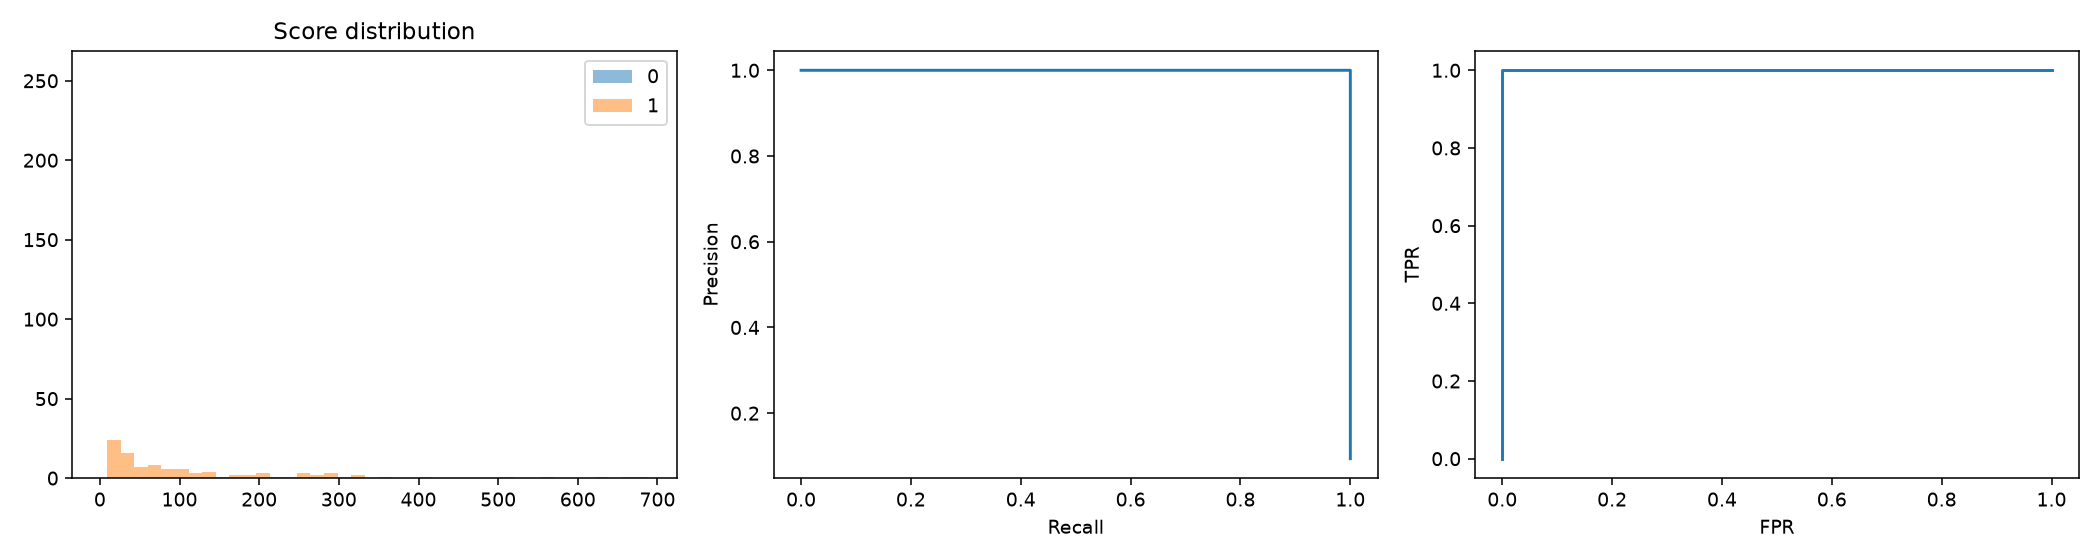

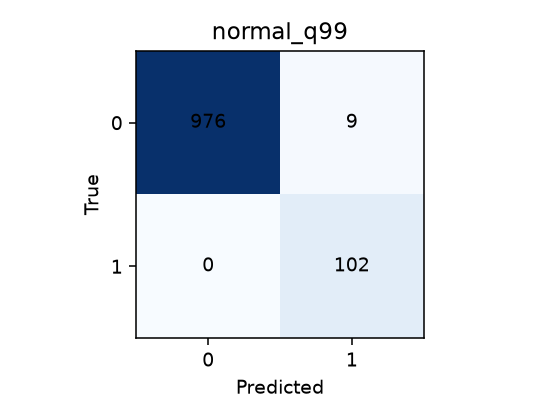

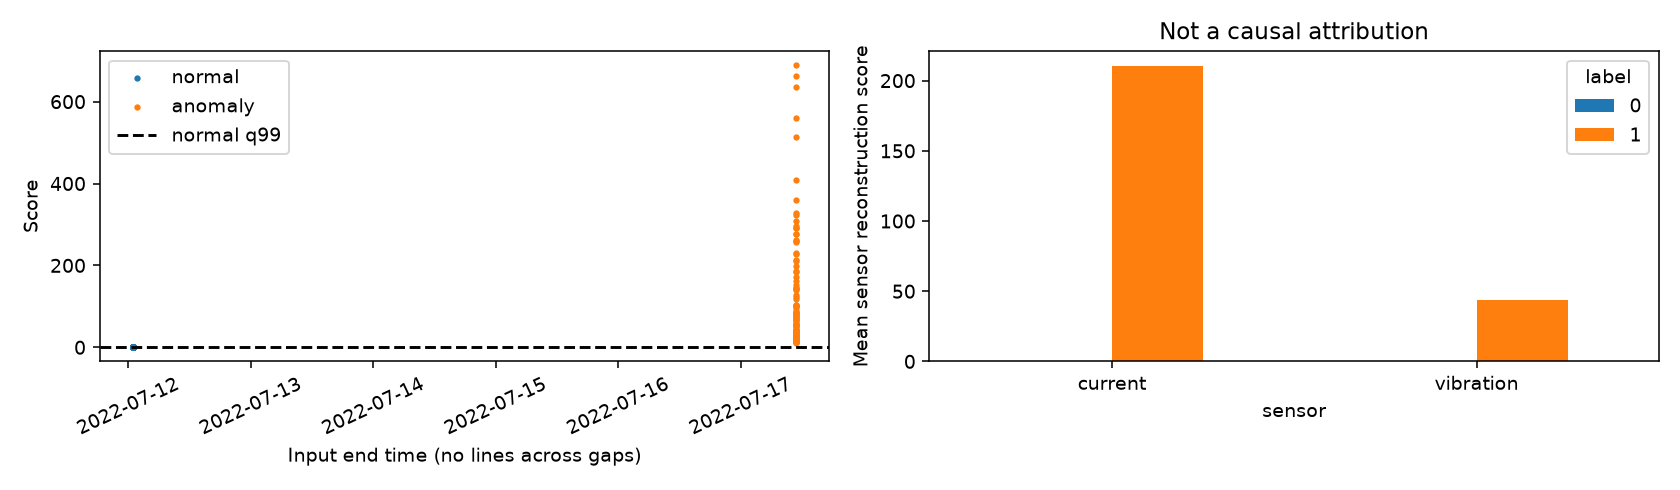

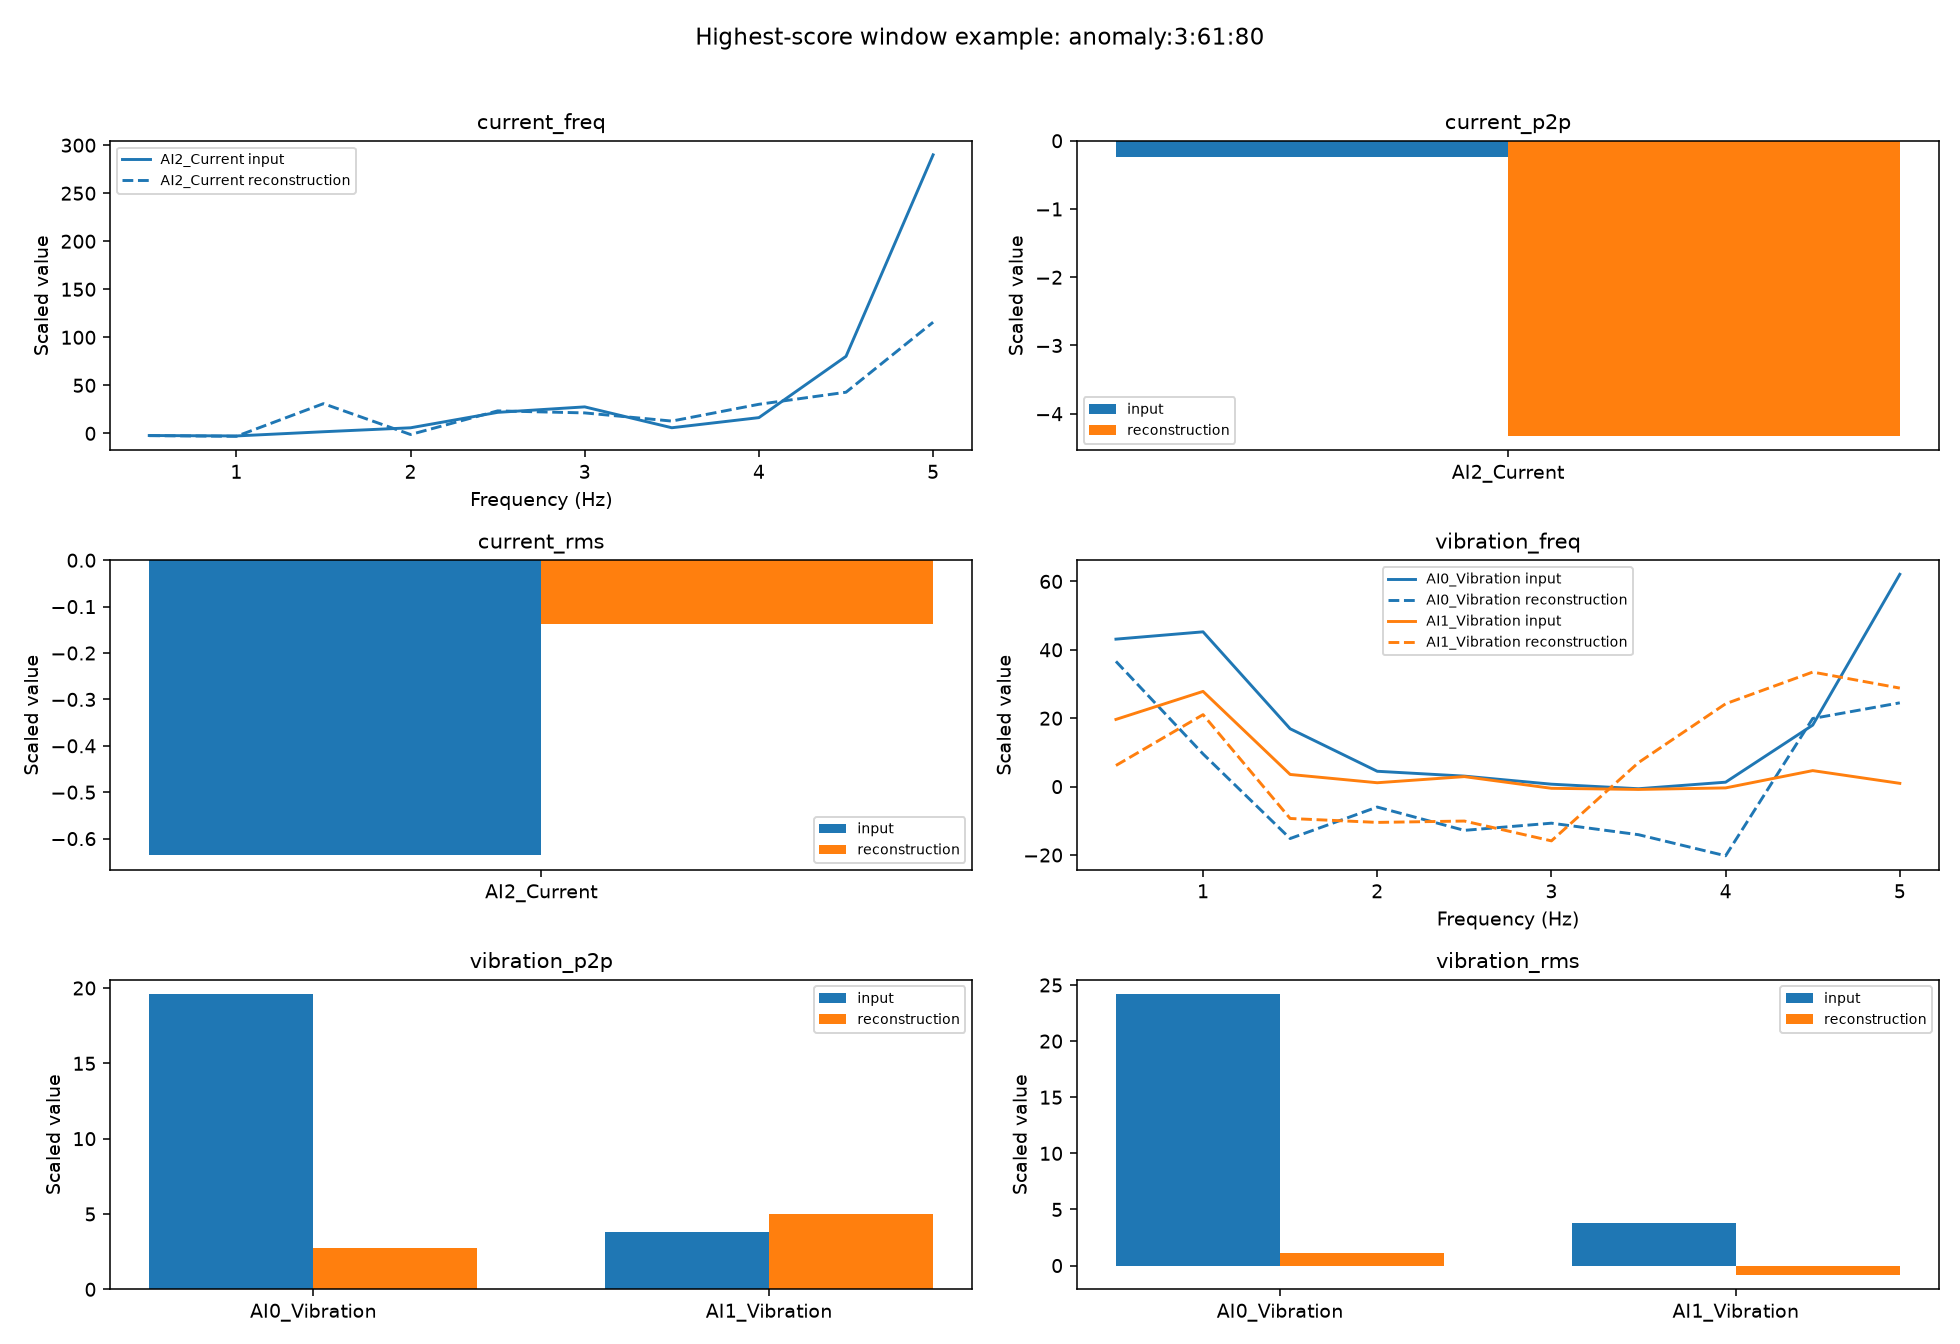

TEST


,n,normal,anomaly,AP,ROC_AUC,TN,FP,FN,TP,accuracy,precision,recall,F1,FPR,FNR,balanced_accuracy,all_normal_accuracy,status
label_10s__normal_q99,2162,1988,174,1.0,1.0,1982,6,0,174,0.997225,0.966667,1.0,0.983051,0.003018,0.0,0.998491,0.919519,computed
label_10s__valid_max_f1,2162,1988,174,1.0,1.0,1988,0,18,156,0.991674,1.0,0.896552,0.945455,0.0,0.103448,0.948276,0.919519,computed
label_current__normal_q99,2162,1988,174,1.0,1.0,1982,6,0,174,0.997225,0.966667,1.0,0.983051,0.003018,0.0,0.998491,0.919519,computed
label_current__valid_max_f1,2162,1988,174,1.0,1.0,1988,0,18,156,0.991674,1.0,0.896552,0.945455,0.0,0.103448,0.948276,0.919519,computed


,policy,label,segments,alarmed,alarm_fraction
0,normal_q99,0,90,5,0.055556
1,normal_q99,1,9,9,1.000000
2,valid_max_f1,0,90,0,0.000000
3,valid_max_f1,1,9,9,1.000000


,policy,grouping,group,n,normal,anomaly,AP,ROC_AUC,TN,FP,...,TP,accuracy,precision,recall,F1,FPR,FNR,balanced_accuracy,all_normal_accuracy,status
0,normal_q99,source+segment,"('normal', 482)",22,22,0,NaN,NaN,22,0,...,0,1.000000,0.0,NaN,NaN,0.000000,NaN,NaN,1.000000,computed
1,normal_q99,source+segment,"('normal', 483)",31,31,0,NaN,NaN,30,1,...,0,0.967742,0.0,NaN,0.000000,0.032258,NaN,NaN,1.000000,computed
2,normal_q99,source+segment,"('normal', 484)",25,25,0,NaN,NaN,25,0,...,0,1.000000,0.0,NaN,NaN,0.000000,NaN,NaN,1.000000,computed
3,normal_q99,source+segment,"('normal', 485)",25,25,0,NaN,NaN,25,0,...,0,1.000000,0.0,NaN,NaN,0.000000,NaN,NaN,1.000000,computed
4,normal_q99,source+segment,"('normal', 486)",25,25,0,NaN,NaN,25,0,...,0,1.000000,0.0,NaN,NaN,0.000000,NaN,NaN,1.000000,computed
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
199,valid_max_f1,source+segment,"('anomaly', 18)",17,0,17,NaN,NaN,0,0,...,14,0.823529,1.0,0.823529,0.903226,NaN,0.176471,NaN,0.000000,computed
200,valid_max_f1,source+segment,"('anomaly', 19)",5,0,5,NaN,NaN,0,0,...,5,1.000000,1.0,1.000000,1.000000,NaN,0.000000,NaN,0.000000,computed
201,valid_max_f1,operating_state,"('low_load',)",1659,1573,86,1.0,1.0,1573,0,...,71,0.990958,1.0,0.825581,0.904459,0.000000,0.174419,0.912791,0.948162,computed
202,valid_max_f1,operating_state,"('active',)",503,415,88,1.0,1.0,415,0,...,85,0.994036,1.0,0.965909,0.982659,0.000000,0.034091,0.982955,0.825050,computed


,label,sensor,mean_score
0,0,current,0.001279
1,0,vibration,0.000861
2,1,current,162.887314
3,1,vibration,26.027336


FP/FN rows: 6 (showing first 20; full table saved)


,window_id,source,segment,split,input_start_row,input_end_row,input_start_time,input_end_time,target_time,label_time,...,error_vibration_freq_last,error_vibration_freq_full,error_vibration_p2p_last,error_vibration_p2p_full,error_vibration_rms_last,error_vibration_rms_full,normal_q99_prediction,normal_q99_error,error_type,largest_reconstruction_error_sensor
0,normal:483:16058:16077,normal,483,test,16058,16077,2022-07-12 01:01:13.818,2022-07-12 01:01:15.718,2022-07-12 01:01:25.718,2022-07-12 01:01:24.596,...,0.003773,0.003773,0.000417,0.000417,0.000032,0.000032,1,FP,FP,current
1,normal:511:17020:17039,normal,511,test,17020,17039,2022-07-12 01:05:04.844,2022-07-12 01:05:06.744,2022-07-12 01:05:16.744,2022-07-12 01:05:16.440,...,0.012268,0.012268,0.000234,0.000234,0.000939,0.000939,1,FP,FP,vibration
2,normal:512:17071:17090,normal,512,test,17071,17090,2022-07-12 01:05:12.840,2022-07-12 01:05:14.740,2022-07-12 01:05:24.740,2022-07-12 01:05:23.320,...,0.008153,0.008153,0.000862,0.000862,0.000342,0.000342,1,FP,FP,current
3,normal:537:17903:17922,normal,537,test,17903,17922,2022-07-12 01:08:35.504,2022-07-12 01:08:37.404,2022-07-12 01:08:47.404,2022-07-12 01:08:46.501,...,0.012152,0.012152,0.000529,0.000529,0.001219,0.001219,1,FP,FP,vibration
4,normal:570:18984:19003,normal,570,test,18984,19003,2022-07-12 01:12:43.712,2022-07-12 01:12:45.612,2022-07-12 01:12:55.612,2022-07-12 01:12:55.568,...,0.016206,0.016206,0.000150,0.000150,0.002204,0.002204,1,FP,FP,vibration
5,normal:570:18985:19004,normal,570,test,18985,19004,2022-07-12 01:12:43.812,2022-07-12 01:12:45.712,2022-07-12 01:12:55.712,2022-07-12 01:12:55.568,...,0.014825,0.014825,0.000261,0.000261,0.002898,0.002898,1,FP,FP,vibration


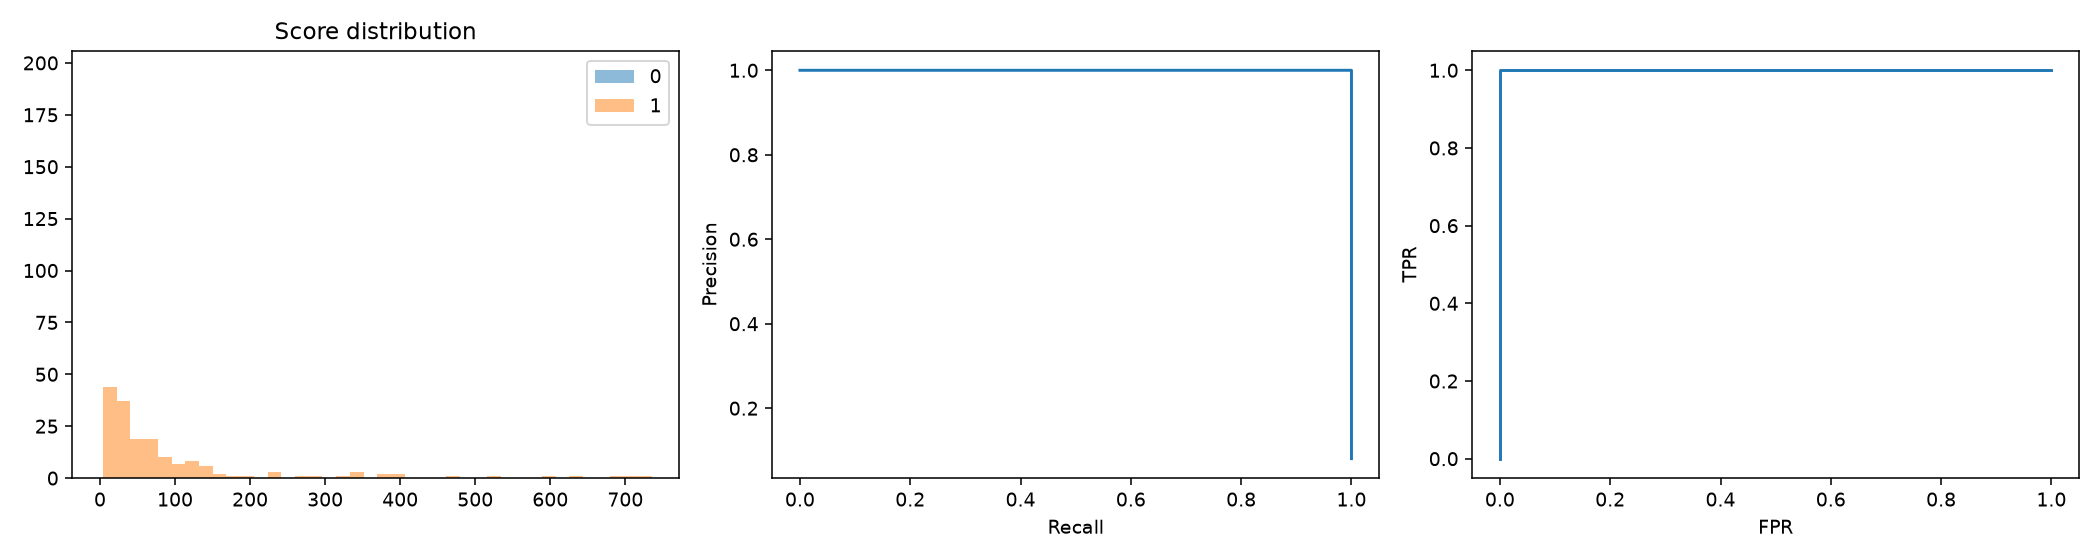

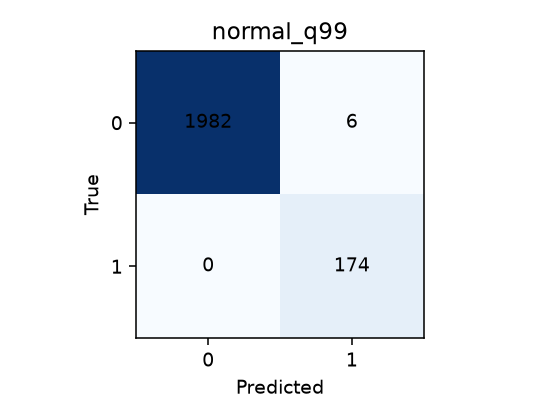

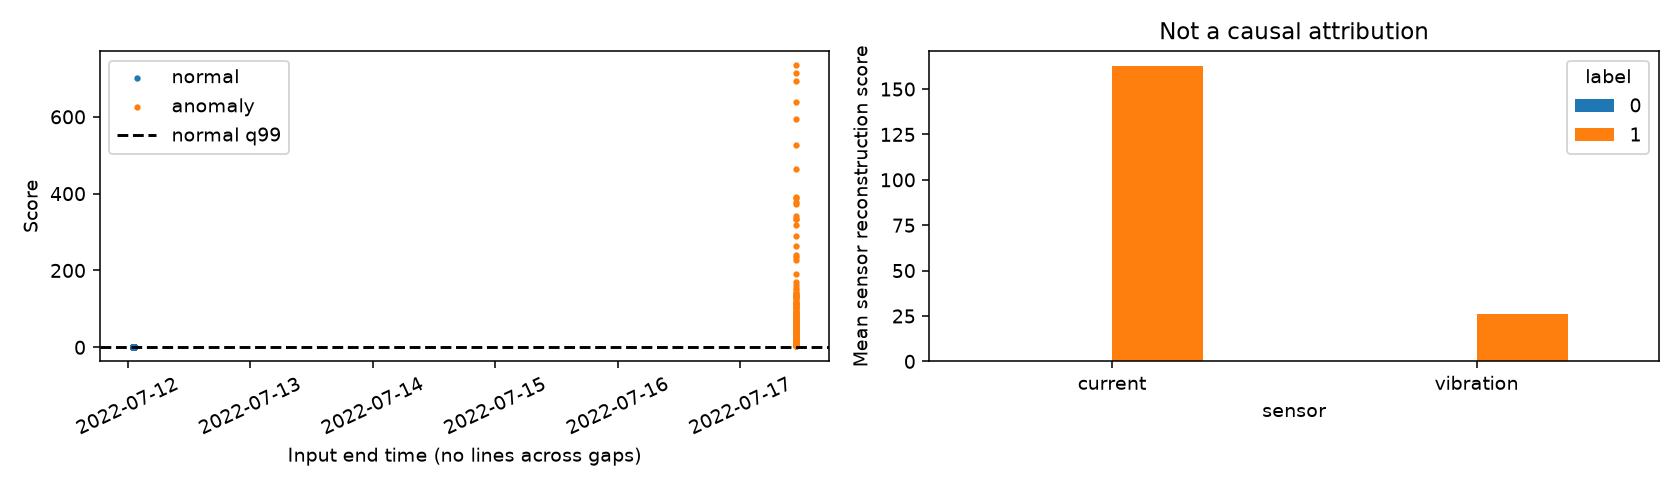

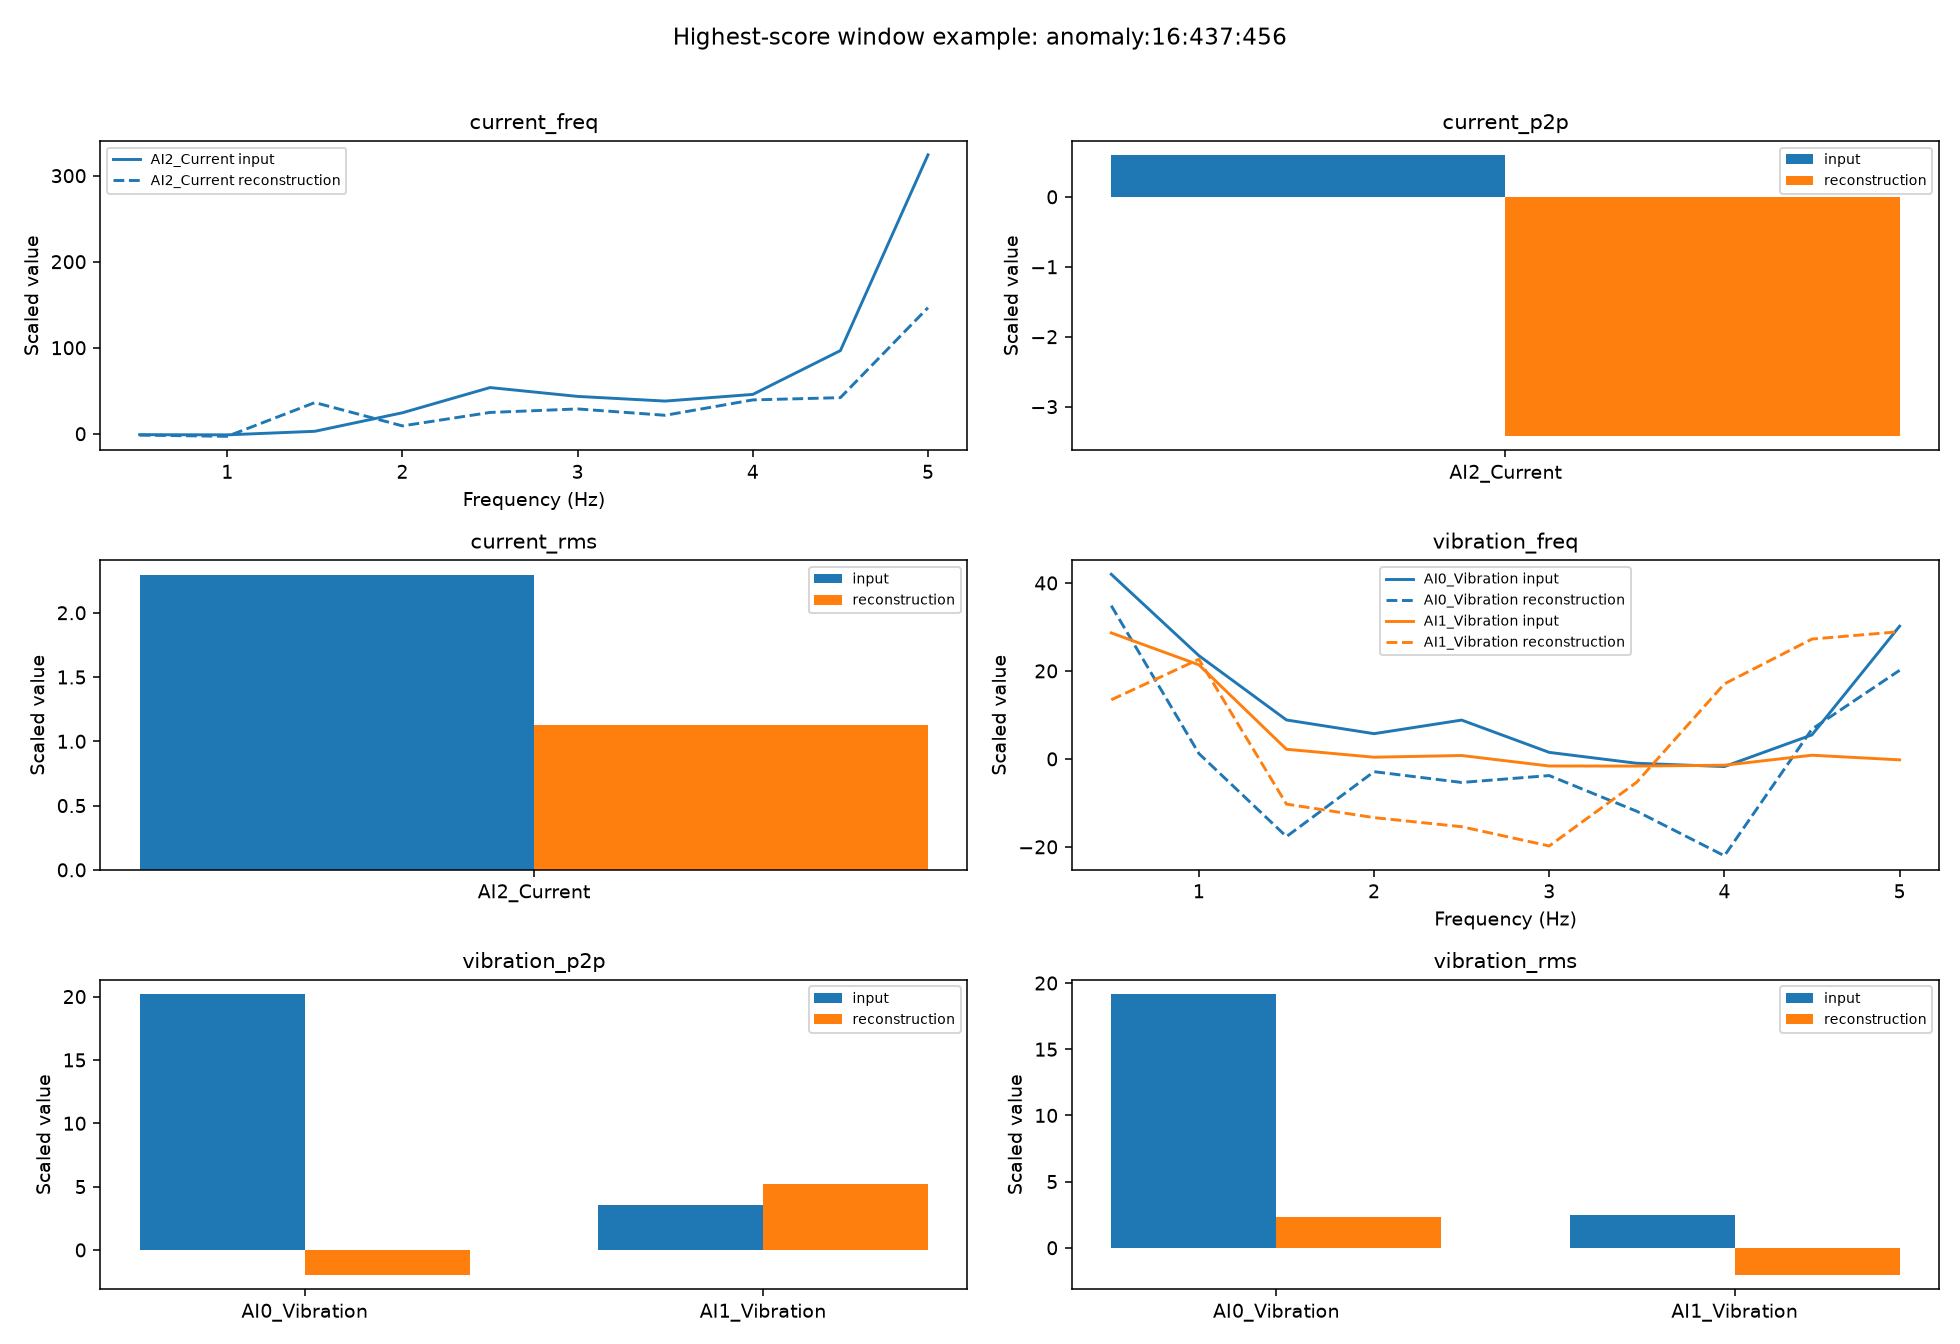

In [21]:
# 완료된 결과만 열 때 아래에 실행 폴더를 지정합니다. None이면 이번 RUN_DIR을 사용합니다.
# 개인 경로를 입력했다면 공유 전에 지우세요. 이 값은 실험 metadata에 저장하지 않습니다.
RESULT_RUN = None
if RESULT_RUN is not None:
    RUN_DIR=Path(RESULT_RUN)
if 'HPO_DIR' in globals():
    display(pd.read_csv(Path(HPO_DIR)/'trials.csv'))
if 'RUN_DIR' in globals():
    show_saved_results(RUN_DIR)
else:
    print('완료된 실행의 RUN_DIR을 지정하면 저장 결과를 볼 수 있습니다.')


## 실행 — 후보별 학습 곡선 비교

저장된 `trials.csv`와 각 후보의 `history.csv`를 읽어 정상 Valid loss와 Valid AP 곡선을 비교합니다. COMPLETE·PRUNED 등 후보 상태를 함께 표시하며 학습·후보 선택은 수행하지 않습니다.

그림은 `hpo_curves.png`, 읽기 가능 여부는 `hpo_curve_coverage.csv`로 저장합니다. 과거 후보의 실행 경로나 이력이 없으면 임의로 대체하지 않고 누락 사유를 표시합니다.


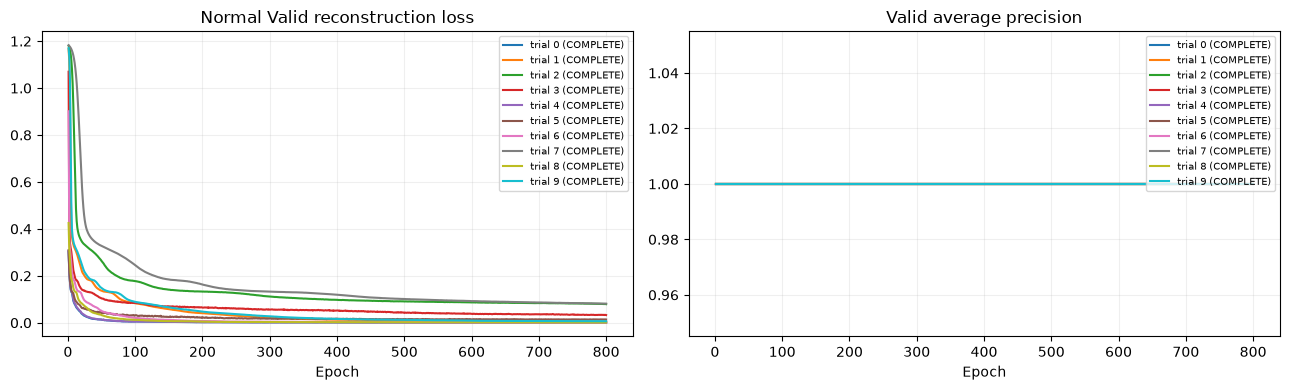

,trial,status,metrics
0,0,displayed,"val_normal_loss,label_10s__normal_q99__AP"
1,1,displayed,"val_normal_loss,label_10s__normal_q99__AP"
2,2,displayed,"val_normal_loss,label_10s__normal_q99__AP"
3,3,displayed,"val_normal_loss,label_10s__normal_q99__AP"
4,4,displayed,"val_normal_loss,label_10s__normal_q99__AP"
5,5,displayed,"val_normal_loss,label_10s__normal_q99__AP"
6,6,displayed,"val_normal_loss,label_10s__normal_q99__AP"
7,7,displayed,"val_normal_loss,label_10s__normal_q99__AP"
8,8,displayed,"val_normal_loss,label_10s__normal_q99__AP"
9,9,displayed,"val_normal_loss,label_10s__normal_q99__AP"


In [22]:
# 저장된 후보별 history만 읽습니다. 학습·후보 선택·임계값은 변경하지 않습니다.
def show_hpo_history(study_dir):
    study_dir=Path(study_dir)
    table=pd.read_csv(study_dir/'trials.csv')
    fig,axes=plt.subplots(1,2,figsize=(13,4))
    coverage=[];drawn=0
    for row in table.to_dict('records'):
        relative=row.get('user_attrs_run_relative')
        inside=row.get('user_attrs_run_in_study')
        if isinstance(inside,str) and inside:
            folder=study_dir/inside
        elif isinstance(relative,str) and relative:
            folder=study_dir.parent.parent.parent/relative
        else:
            coverage.append({'trial':row['number'],'status':'missing_run_reference'});continue
        path=folder/'history.csv'
        if not path.is_file():
            coverage.append({'trial':row['number'],'status':'missing_history'});continue
        history=pd.read_csv(path)
        label='trial '+str(row['number'])+' ('+str(row['state'])+')'
        plotted=[]
        for ax,key in zip(axes,('val_normal_loss',TARGET_COLUMN+'__normal_q99__AP')):
            if key in history and 'epoch' in history:
                ax.plot(history.epoch,history[key],label=label,marker='.' if len(history)==1 else None)
                plotted.append(key)
        coverage.append({'trial':row['number'],'status':'displayed' if plotted else 'missing_metric','metrics':','.join(plotted)})
        drawn+=bool(plotted)
    for ax,title in zip(axes,('Normal Valid reconstruction loss','Valid average precision')):
        ax.set(title=title,xlabel='Epoch');ax.grid(alpha=.2)
        if ax.lines:ax.legend(fontsize=7)
    fig.tight_layout();fig.savefig(study_dir/'hpo_curves.png',dpi=140)
    pd.DataFrame(coverage).to_csv(study_dir/'hpo_curve_coverage.csv',index=False)
    if drawn:
        if SHOW_INLINE_RESULTS:display(fig)
    else:print('표시할 후보 이력이 없습니다. hpo_curve_coverage.csv를 확인하세요.')
    plt.close(fig)
    display(pd.DataFrame(coverage))
    if DATA_MODE=='drive':
        dest=OUTPUT_ROOT/study_dir.relative_to(Path.cwd()/'experiment_work')
        dest.mkdir(parents=True,exist_ok=True)
        for name in ('hpo_curves.png','hpo_curve_coverage.csv'):shutil.copy2(study_dir/name,dest/name)

if 'HPO_DIR' in globals():show_hpo_history(HPO_DIR)
else:print('완료된 HPO_DIR을 지정하면 후보별 학습 곡선을 볼 수 있습니다.')


## 실행 — HPO 전체 비교 자료를 W&B에 기록

후보별 run과 별도로 `hpo-study` run에 전체 후보 표·후보별 곡선·선정 결과를 올립니다. 학습을 다시 시작하지 않습니다. 탐색 DB snapshot·sampler·상태는 `hpo-state` artifact로 보관합니다. 선택한 후보의 Test 결과는 해당 후보의 run에 기록됩니다.

`PUBLISH_HPO_SUMMARY=True`가 기본입니다. W&B 비활성화 상태에서는 로컬 보고서만 만듭니다. 업로드 실패 시 설정을 확인한 뒤 이 셀만 다시 실행할 수 있습니다. 보고서 폴더는 study 아래에 있어 HPO ZIP에도 포함됩니다.


In [23]:
PUBLISH_HPO_SUMMARY = True
if PUBLISH_HPO_SUMMARY and 'HPO_DIR' in globals():
    HPO_REPORT_DIR=publish_hpo_summary(HPO_DIR)
else:
    print('완료된 HPO_DIR이 없거나 전체 비교 업로드를 선택하지 않았습니다.')


wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: WARNING [wandb.login()] Changing session credentials to explicit value for https://api.wandb.ai.
wandb: Appending key for api.wandb.ai to your netrc file: [LOCAL_PATH_REDACTED]


wandb: ERROR The nbformat package was not found. It is required to save notebook history.


Execution/last_operation_status,completed
Execution/test_evaluated,False
Execution/training_status,not_run
HPO/selected_trial,0
HPO/selected_valid_AP,1.0
Reporting/kind,hpo_summary
Reporting/version,readable_storage_v2


## 선택 실행 — 저장 결과를 W&B에 다시 전송

학습을 마친 뒤 업로드만 다시 해야 할 때 `REPUBLISH_SAVED_RESULTS=True`로 설정합니다. 지정한 `RUN_DIR`의 저장 결과를 읽어 전송하며 모델을 다시 학습하지 않습니다.

W&B 연결·인증 설정을 먼저 확인하세요. Test 폴더가 있으면 Test 단계로, 없으면 학습 단계로 기록합니다. 로컬 파일이 없는 과거 결과를 복원하는 기능은 아닙니다.


In [24]:
REPUBLISH_SAVED_RESULTS=False
if REPUBLISH_SAVED_RESULTS:
    publish_saved_results(RUN_DIR,stage='test' if (result_path(Path(RUN_DIR),'test')).exists() else 'train')


## 선택 실행 — 탐색 DB와 후보 결과 전체 보관

`EXPORT_RESULTS=True`이면 study DB·후보 표와 해당 실험·seed의 후보 폴더를 함께 ZIP으로 묶습니다. HPO를 복원·분석할 때 필요한 탐색 자료와 후보별 학습 결과를 함께 보관하기 위한 셀입니다.

같은 실험·seed로 다른 study를 실행했다면 그 후보도 포함될 수 있어 ZIP이 커질 수 있습니다. 로컬에 ZIP을 생성하며 Colab에서는 다운로드도 요청합니다.

**저장 v2 안내:** 아래 코드의 논리 경로는 `result_path()`가 새 실행의 실제 폴더로 연결합니다. `run_info.json`과 실행 폴더 `README.md`에서 실험 이름·Train/Valid/Test 위치를 확인하세요. W&B 실행 이름은 Test 업로드 시에도 유지합니다.


In [25]:
# 탐색 결과 전체 보관: study DB/후보 표와 해당 실험·seed의 후보 실행들을 함께 묶습니다.
# 이 study의 후보만 묶습니다. 정리 완료 후에는 탈락 후보의 가중치·epoch Valid 점수가 제외됩니다.
EXPORT_RESULTS = False
if EXPORT_RESULTS:
    if 'HPO_DIR' not in globals(): raise ValueError('HPO_DIR을 먼저 지정하세요.')
    study_dir=Path(HPO_DIR)
    folders=hpo_export_folders(study_dir)
    archive=export_result_folders(folders,prefix='hpo_results')
